# Unofficial MusicXML Test Suite 
(based on Lilypond Test Suite)


In [1]:
from music21 import *
print(musicxml.lilypondTestSuite.__doc__)


The Lilypond MusicXML Test Suite comes from
https://github.com/cuthbertLab/musicxmlTestSuite
and is a fork of
http://lilypond.org/doc/v2.18/input/regression/musicxml/collated-files

The test suite is licensed under the MIT license
(https://opensource.org/license/mit/)
and copyrighted by the Lilypond project.



In [2]:
import os
import re
import pathlib

allF = musicxml.lilypondTestSuite.allFiles()
untested = [f.name for f in sorted(allF)]
scores = {}
musicxmlOut = {}

def s(i):
    if isinstance(i, int):
        longFp = allF[i]
    else:
        for longFp in allF:
            shortFp = longFp.name 
            if i in shortFp:
                break
        else:
            raise FileNotFoundError("Cannot find: " + str(i))
    shortFp = longFp.name 
    if shortFp in untested:
        untested.remove(shortFp)
        
    sc = converter.parse(longFp, forceSource=True)    
    scores[i] = sc
    
    fp = pathlib.Path(sc.metadata.filePath).name
    print(fp + '\n')
    
    desc = sc.metadata.description
    desc = re.sub(r'\s+', ' ', desc)
    print(desc)
    
    fpOut = sc.write('musicxml')
    with open(fpOut, 'r') as musicxmlOutFile:
        allOut = musicxmlOutFile.read()
    
    musicxmlOut[i] = allOut
    return sc.show()

## 01 ... Pitches

01a-Pitches-Pitches.xml

All pitches from G to c'''' in ascending steps; First without accidentals, then with a sharp and then with a flat accidental, then with explicit natural accidentals. Double alterations and cautionary accidentals are tested at the end.


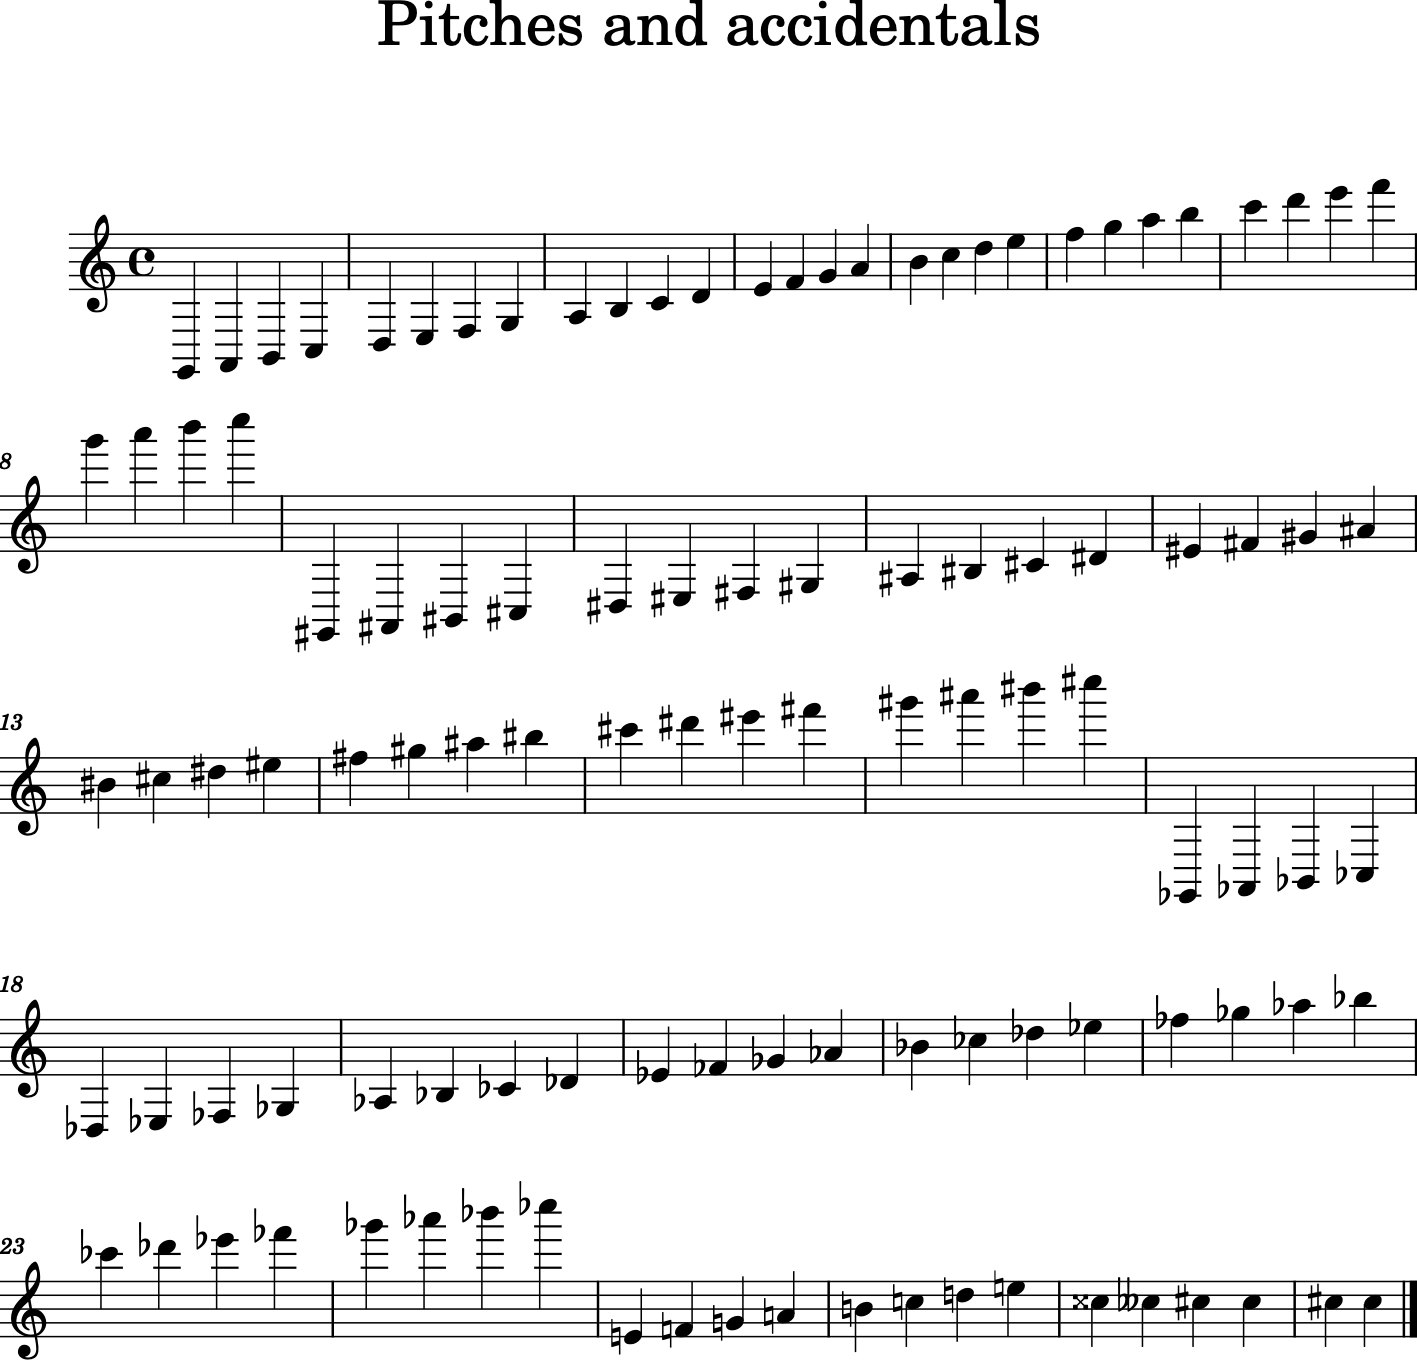

In [3]:
s('01a')

01b-Pitches-Intervals.xml

All pitch intervals in ascending jump size.


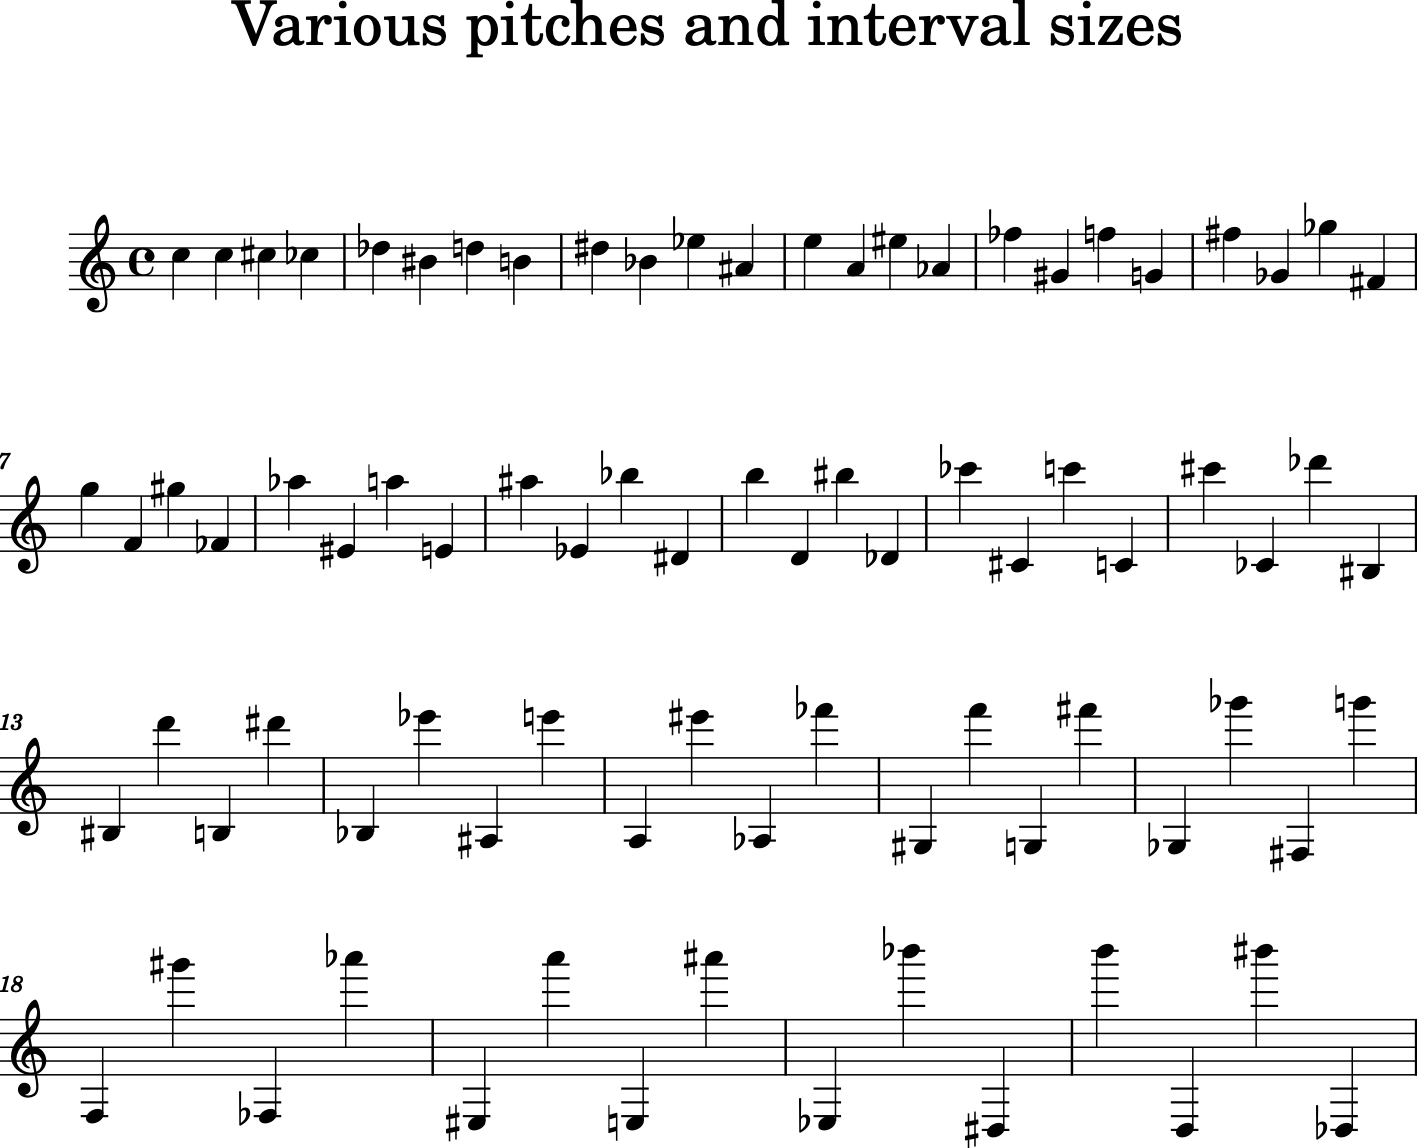

In [4]:
s('01b')

01c-Pitches-NoVoiceElement.xml

The <voice> element of notes is optional in MusicXML (although Dolet always writes it out). Here, there is one note with lyrics, but without a voice assigned. It should still be correctly converted.


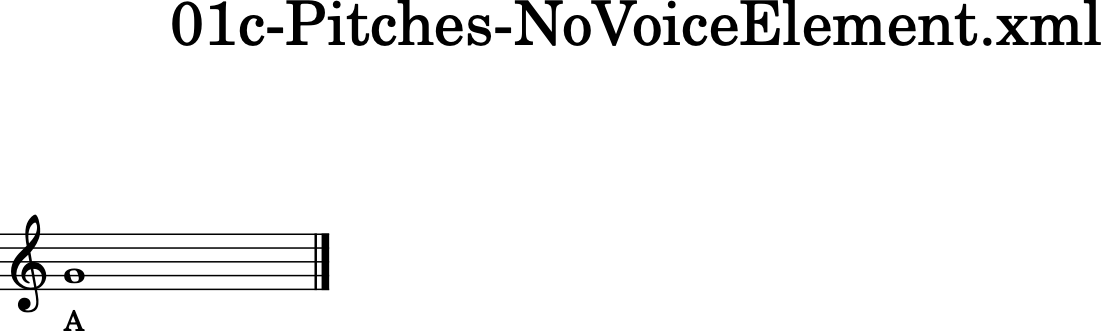

In [5]:
s('01c')

01d-Pitches-Microtones.xml

Some microtones: c flat-and-a-half, d half-flat, e half-sharp, f sharp-and-a half. Once in the lower and once in the upper region of the staff.


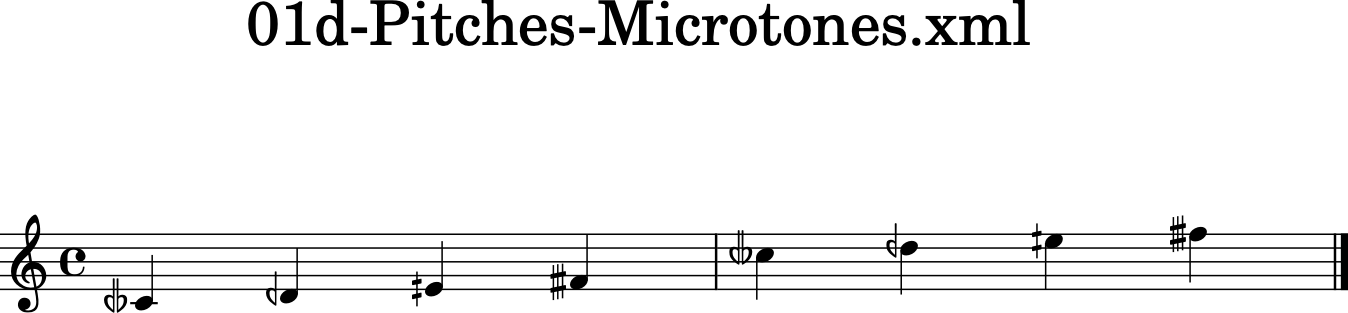

In [6]:
s('01d')

01e-Pitches-EditorialCautionaryAccidentals.xml

Accidentals can be cautionary or editorial. Each measure has a normal accidental, an editorial, a cautionary and an editorial and cautionary accidental. These do not need to be graphically distinguished in later XML Versions. 


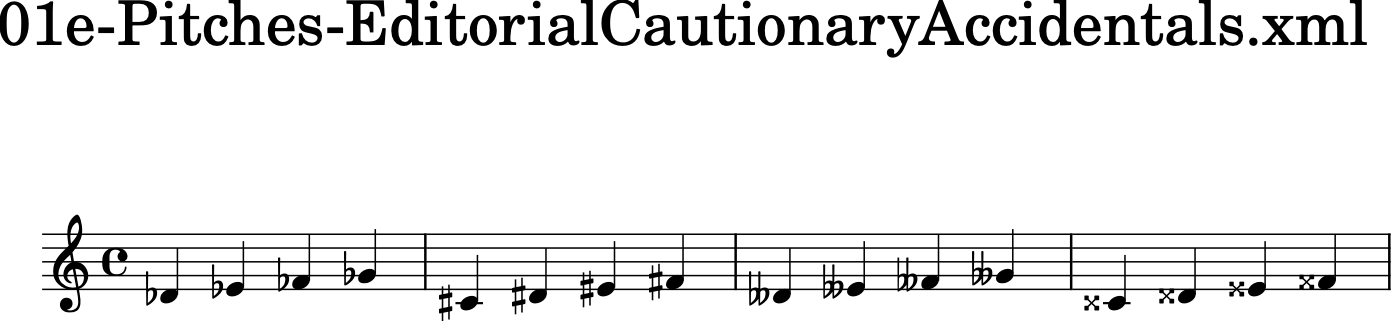

In [7]:
s('01e') # no visual distinctions are necessary

01ea-Pitches-Parenthesis-Changed-Accidentals.xml

 Accidentals have styling attributes. The first measure's accidentals should be normal, parenthesized, bracketed, and praenthesized-and-bracketed. Measure 2 has the sharp shifted to the right of the note, while Measure 3 has the sharp shifted above the note. Measure 4 should have a red accidental. Measure 5 and 6 should have a large accidental, created using the size and font-size attributes respectively. 


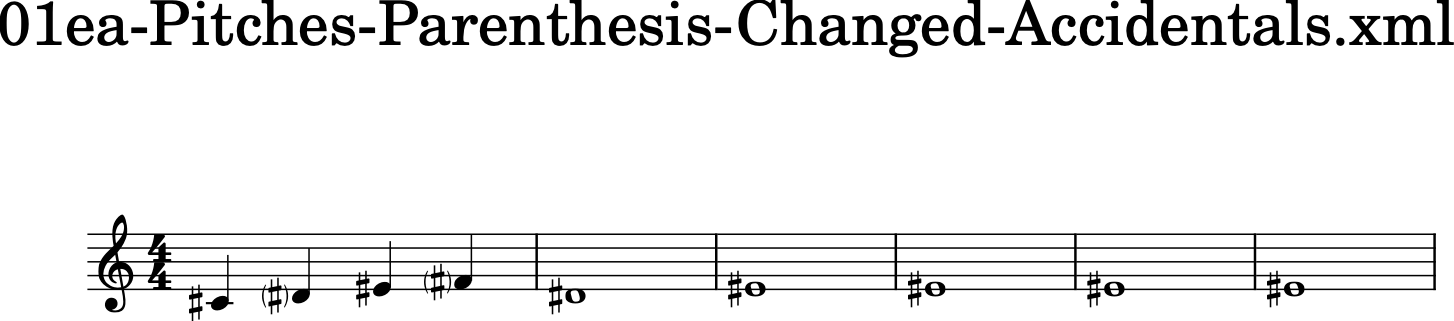

In [8]:
s('01ea') # only parentheses supported by m21 or MuseScore/Finale

01f-Pitches-EditorialMicrotoneAccidentals.xml

Microtone accidentals can be cautionary or editorial. Each measure has a normal accidental, an editorial, a cautionary and an editorial and cautionary accidental. No visual distinctions are necessary


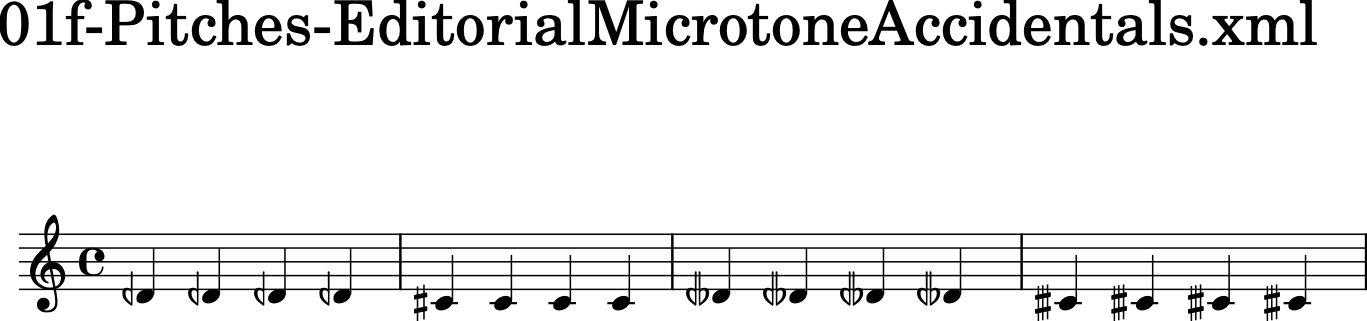

In [9]:
s('01f') # no visual distinctions are necessary

## 02 ... Rests

02a-Rests-Durations.xml

All different rest lengths: A two-bar multi-measure rest, a whole rest, a half, etc. until a 128th-rest; Then the same with dotted durations.


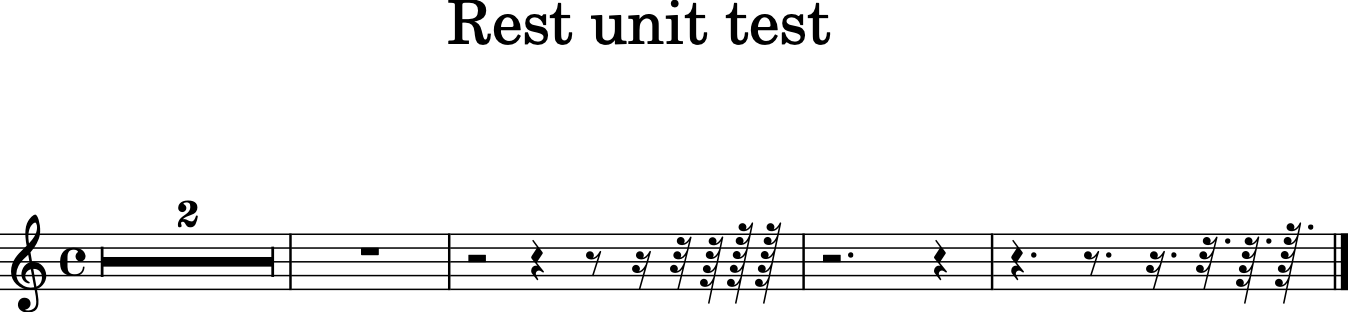

In [10]:
s('02a')

02b-Rests-PitchedRests.xml

Rests can have explicit pitches, where they are displayed. The first rest uses no explicit position and should use the default position, all others are explicitly positioned somewhere else.


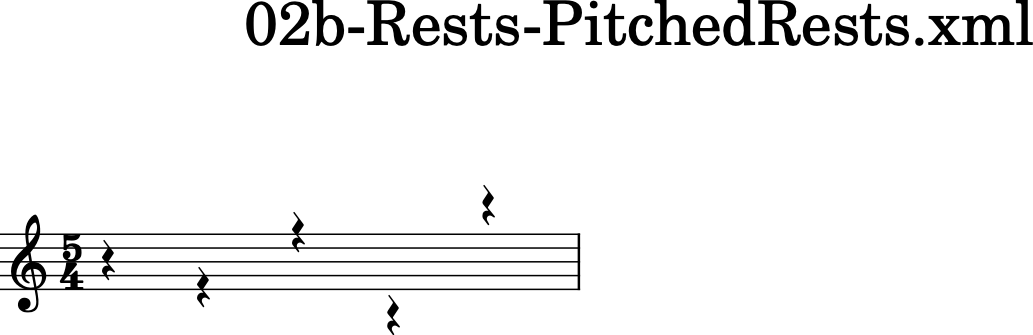

In [11]:
s('02b')

02c-Rests-MultiMeasureRests.xml

Four multi-measure rests: 3 measures, 15 measures, 1 measure, and 12 measures.


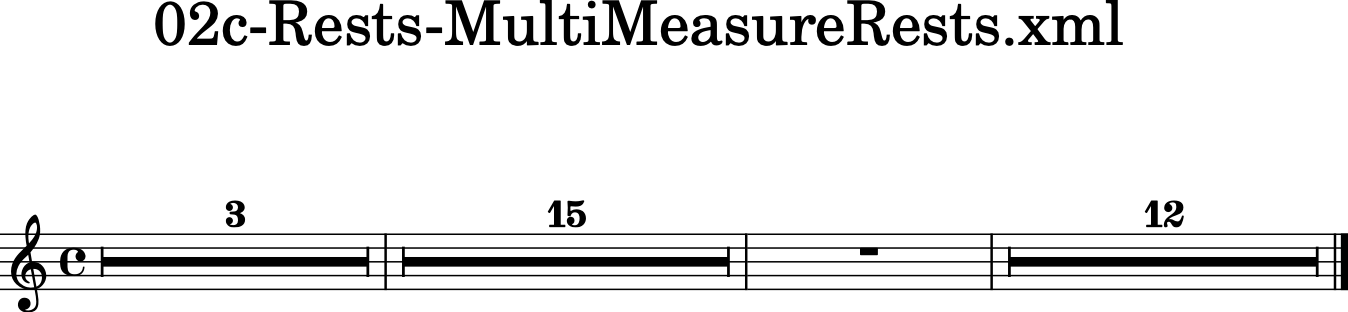

In [12]:
s('02c')

02d-Rests-Multimeasure-TimeSignatures.xml

Multi-Measure rests should always be converted into durations that are a multiple of the time signature.


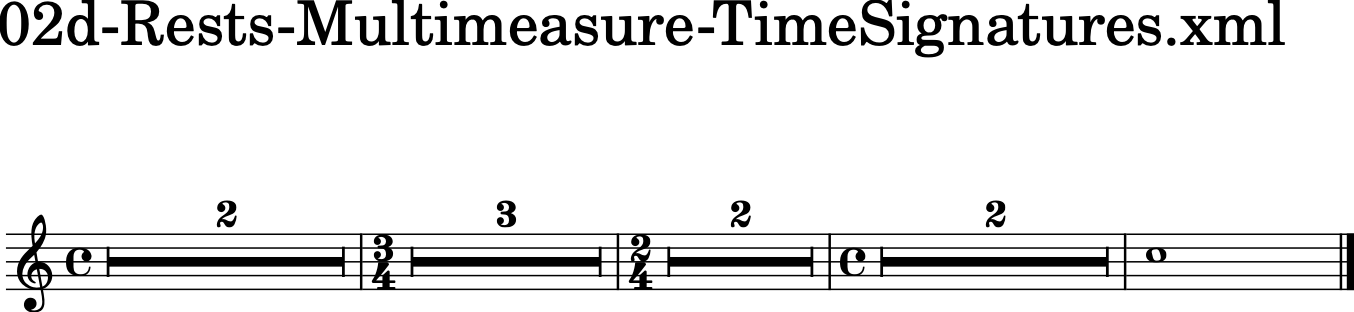

In [13]:
s('02d')

02e-Rests-NoType.xml

In some cases, a rest might not have its type attribute set (this happens, for example, with voices in Finale, where you don't manually insert a rest).


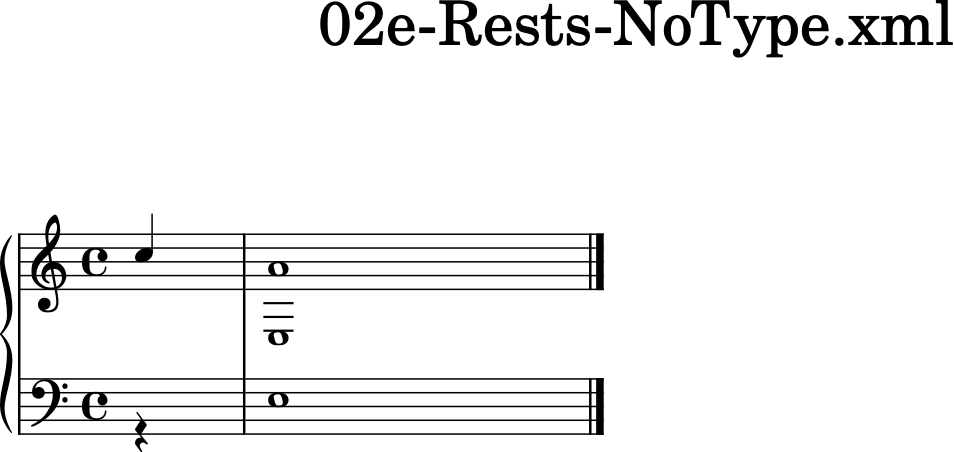

In [14]:
s('02e')

## 03 ... Rhythm

03aa-Rhythm-Durations.xml

All common note durations, from brevis, whole until 64th; First with their plain values, then dotted and finally doubly-dotted (to 32nd).


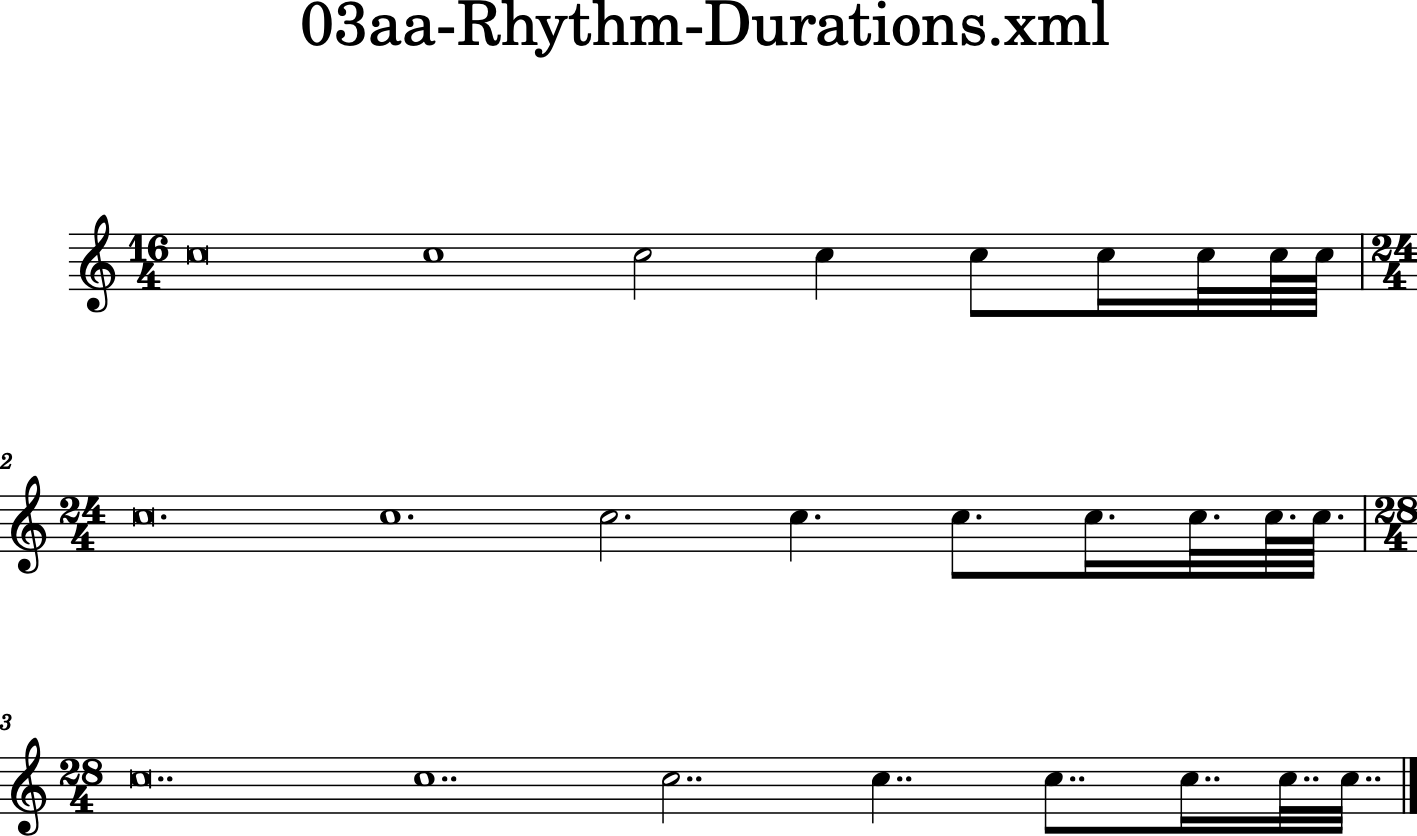

In [15]:
s('03aa') 

03ab-Rhythm-Durations.xml

Extreme note durations (pre 3.0): long and 128th; First with their plain values, then dotted and finally doubly-dotted.


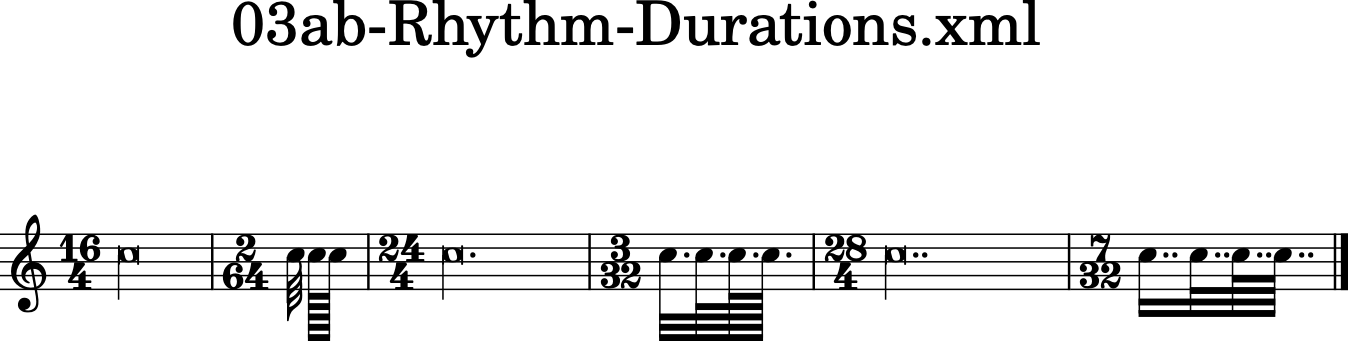

In [16]:
s('03ab')

03b-Rhythm-Backup.xml

Two voices with a backup, that does not jump to the beginning for the measure for voice 2, but somewhere in the middle. Voice 2 thus won't have any notes or rests for the first beat of the measures.


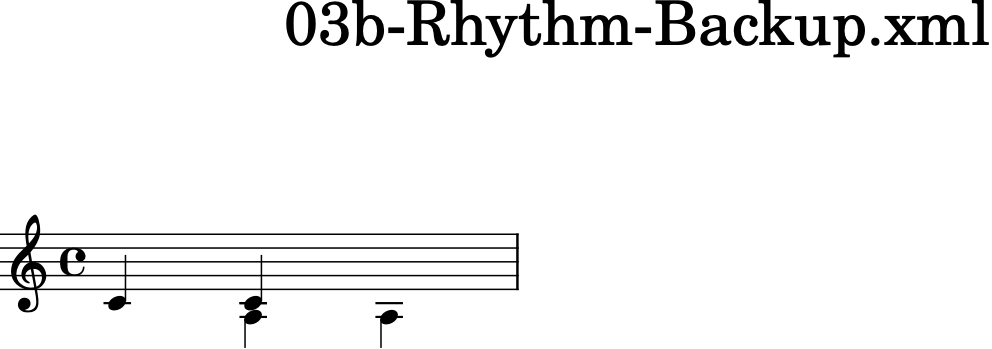

In [17]:
s('03b') # music21 creates a Rest w/ hideObjectOnPrint in this case.

03c-Rhythm-DivisionChange.xml

Although uncommon, the divisions of a quarter note can change somewhere in the middle of a MusicXML file. Here, the first half measure uses a division of 1, which then changes to 8 in the middle of the first measure and to 38 in the middle of the second measure.


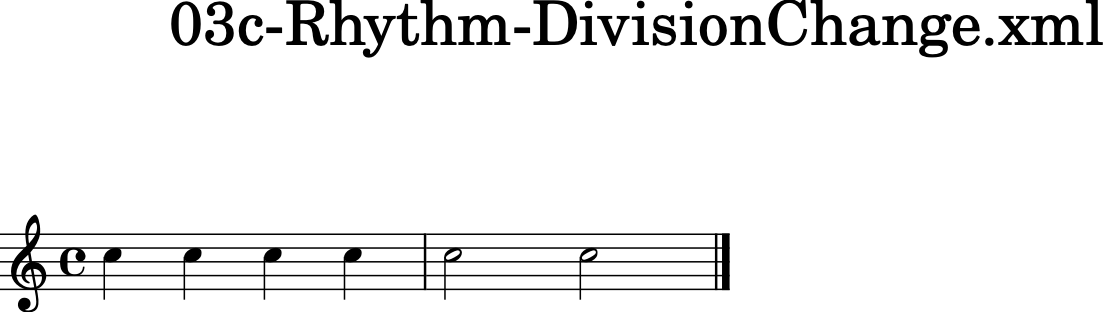

In [18]:
s('03c')

03d-Rhythm-DottedDurations-Factors.xml

Several durations can be written with dots. For multimeasure rests, we can also have durations that cannot be expressed with dotted notes (5/16 and 9/8).


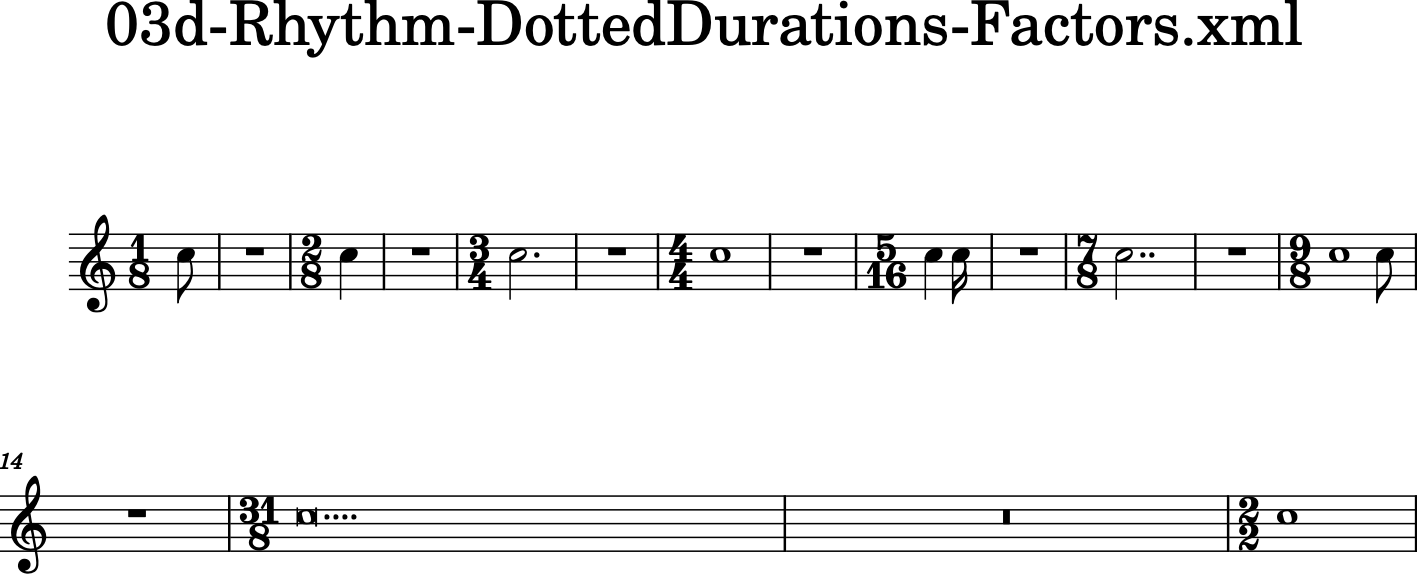

In [19]:
s('03d') # failing on not recognizing a way around 5/16, 9/8

In [20]:
scores['03d'].show('text') # import is fine.

{0.0} <music21.metadata.Metadata object at 0x121e45420>
{0.0} <music21.stream.Part MusicXML Part>
    {0.0} <music21.instrument.Instrument 'P1: MusicXML Part: '>
    {0.0} <music21.stream.Measure 1 offset=0.0>
        {0.0} <music21.meter.TimeSignature 1/8>
        {0.0} <music21.note.Note C>
    {0.0} <music21.spanner.MultiMeasureRest 1 measure>
    {0.0} <music21.spanner.MultiMeasureRest 1 measure>
    {0.0} <music21.spanner.MultiMeasureRest 1 measure>
    {0.0} <music21.spanner.MultiMeasureRest 1 measure>
    {0.0} <music21.spanner.MultiMeasureRest 1 measure>
    {0.0} <music21.spanner.MultiMeasureRest 1 measure>
    {0.0} <music21.spanner.MultiMeasureRest 1 measure>
    {0.0} <music21.spanner.MultiMeasureRest 1 measure>
    {0.5} <music21.stream.Measure 2 offset=0.5>
        {0.0} <music21.note.Rest eighth>
    {1.0} <music21.stream.Measure 3 offset=1.0>
        {0.0} <music21.meter.TimeSignature 2/8>
        {0.0} <music21.note.Note C>
    {2.0} <music21.stream.Measure 4 offset=2.

## 11 ... Time signatures

11a-TimeSignatures.xml

Various time signatures: 2/2 (alla breve), 4/4 (C), 2/2, 3/2, 2/4, 3/4, 4/4, 5/4, 3/8, 6/8, 12/8


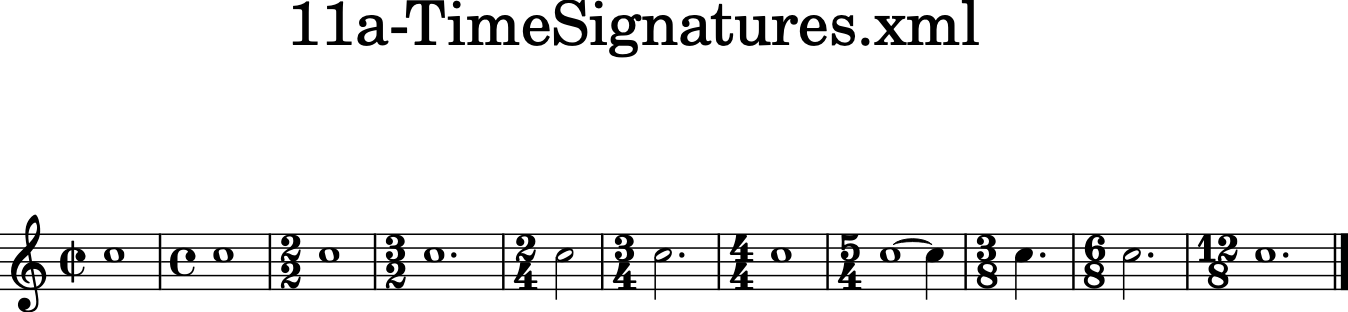

In [21]:
s('11a')

11b-TimeSignatures-NoTime.xml

A score without a time signature (but with a key and clefs)


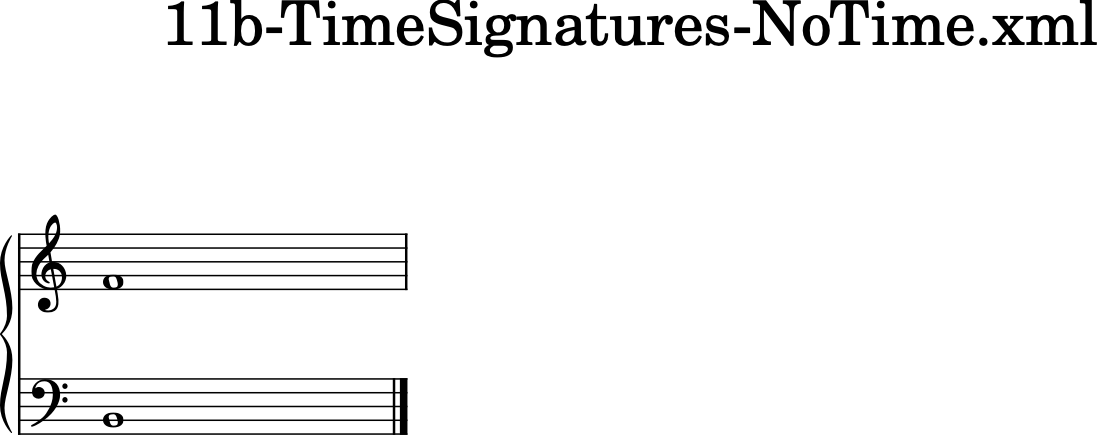

In [22]:
s('11b')

11c-TimeSignatures-CompoundSimple.xml

Compound time signatures with same denominator: (3+2)/8 and (5+3+1)/4.


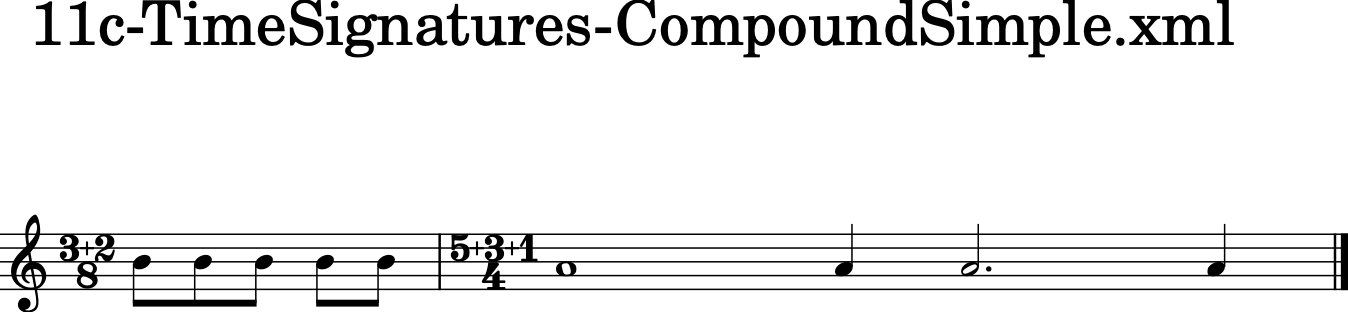

In [23]:
s('11c')

11d-TimeSignatures-CompoundMultiple.xml

Compound time signatures with separate fractions displayed: 3/8+2/8+3/4 and 5/2+1/8.


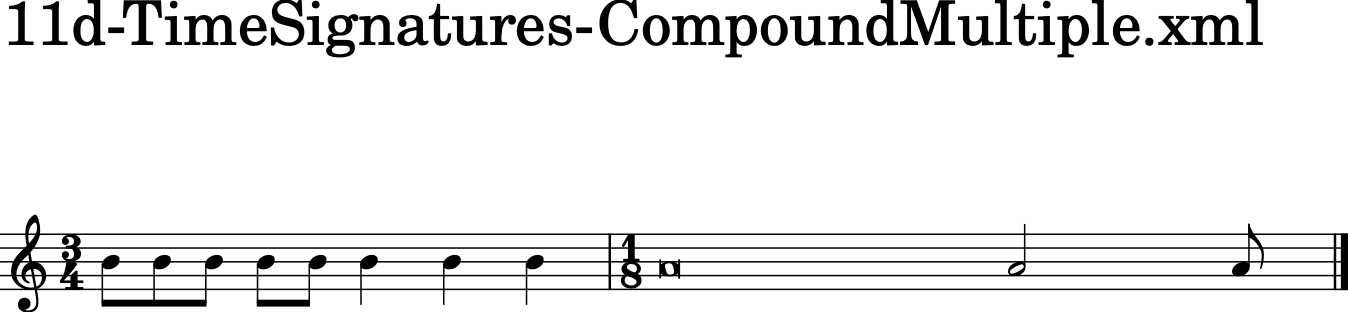

In [24]:
s('11d') # blocking: MuseScore.  Finale OK

In [25]:
for m in scores['11d'].recurse().getElementsByClass('TimeSignature'):
    print(m, m.displaySequence.flat)

<music21.meter.TimeSignature 3/8+2/8+3/4> {3/8+2/8+3/4}
<music21.meter.TimeSignature 5/2+1/8> {5/2+1/8}


11e-TimeSignatures-CompoundMixed.xml

Compound time signatures of mixed type: (3+2)/8+3/4.


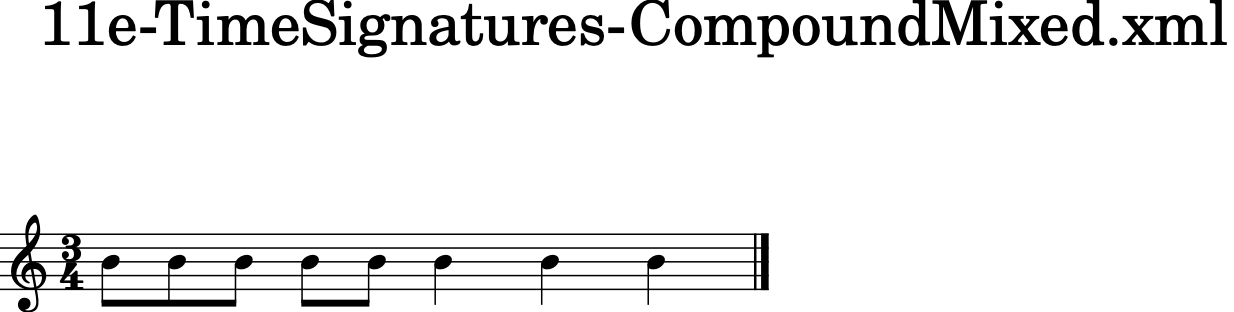

In [26]:
s('11e') # blocking: MuseScore, Finale OK

11f-TimeSignatures-SymbolMeaning.xml

A time signature of 3/8 with the symbol="cut" attribute and two symbol="single-number" attributes with compound time signatures. Shall the symbol be ignored in this case?


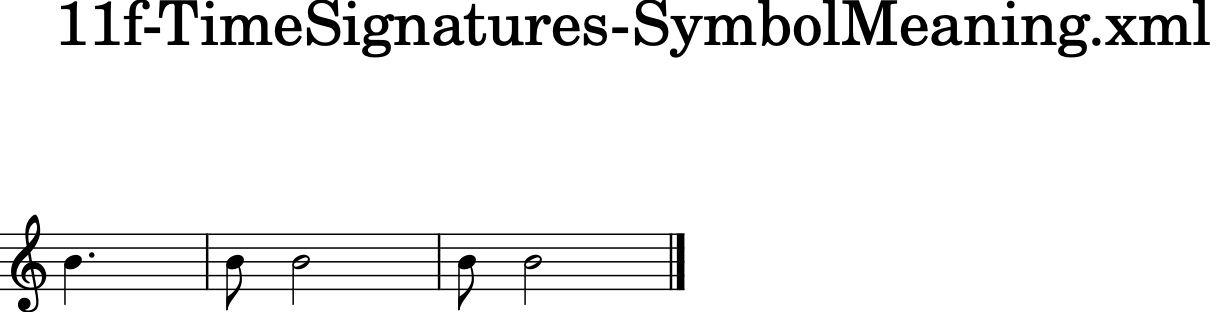

In [27]:
s('11f') # acceptable though different meaning from Lilypond

11g-TimeSignatures-SingleNumber.xml

Time signature displayed as a single number.


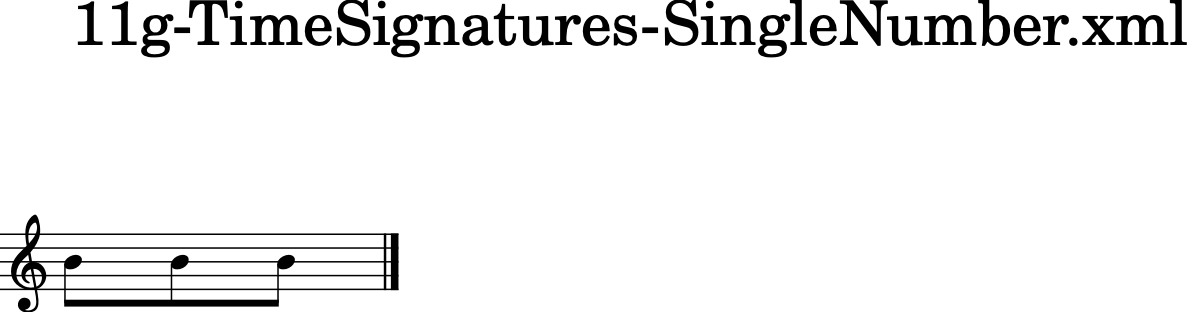

In [28]:
s('11g') # block: MuseScore

In [29]:
ts = scores['11g'].recurse().getElementsByClass('TimeSignature')[0]
ts.symbol

'single-number'

11h-TimeSignatures-SenzaMisura.xml

Senza-misura time signature


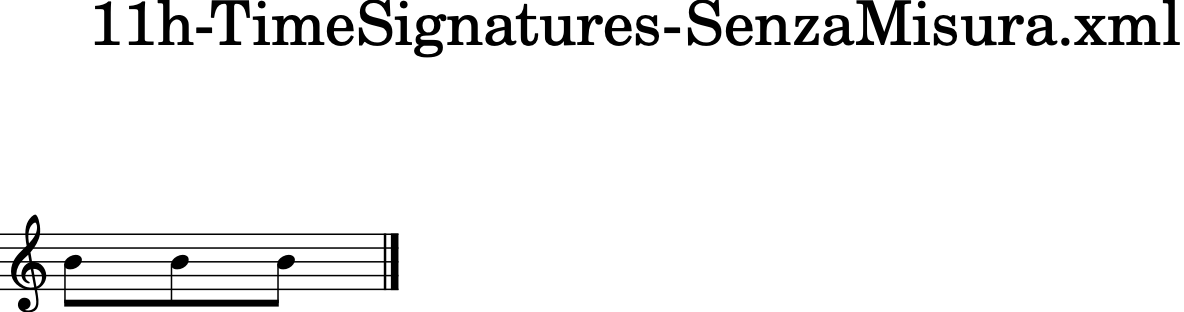

In [30]:
s('11h')

In [31]:
sc = scores['11h']
sc.recurse().getElementsByClass('SenzaMisuraTimeSignature')[0]

<music21.meter.SenzaMisuraTimeSignature>

## 12 ... Clefs

12aa-Clefs_Pitch_Traditional.xml

Four traditional clefs: G-treble, C-alto, C-tenor, F-bass


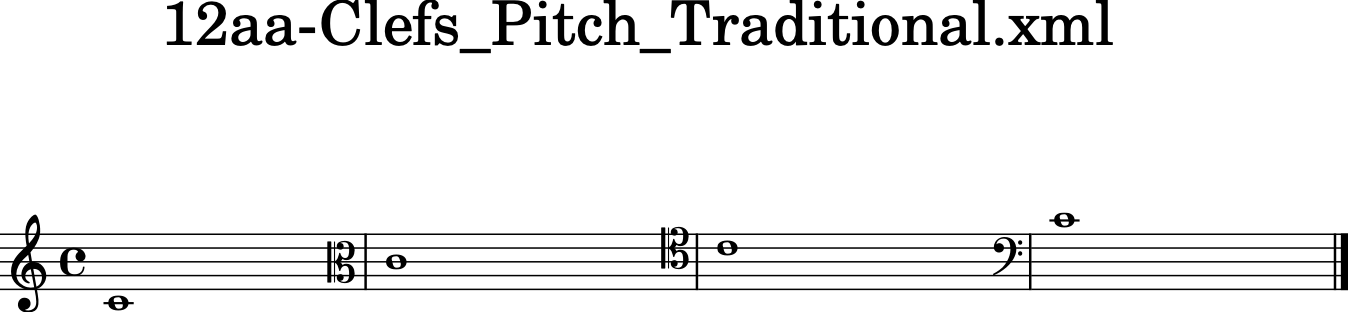

In [32]:
s('12aa')

12ab-Clefs-Percussion-NonTrad.xml

Clefs with octave shifts, clefs on staff lines other than default, and percussion. Order: Percussion, treble 8vb, bass 8vb, F3, G1, C5, C2, C1, treble 8va, bass 8va, 


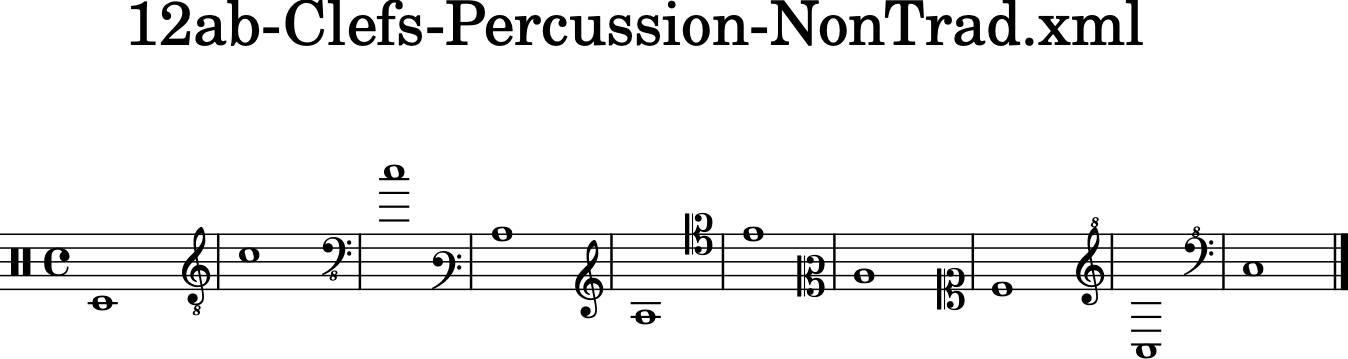

In [33]:
s('12ab')

12ac-Clefs-TAB-Switch.xml

none clef, TAB clef, Treble


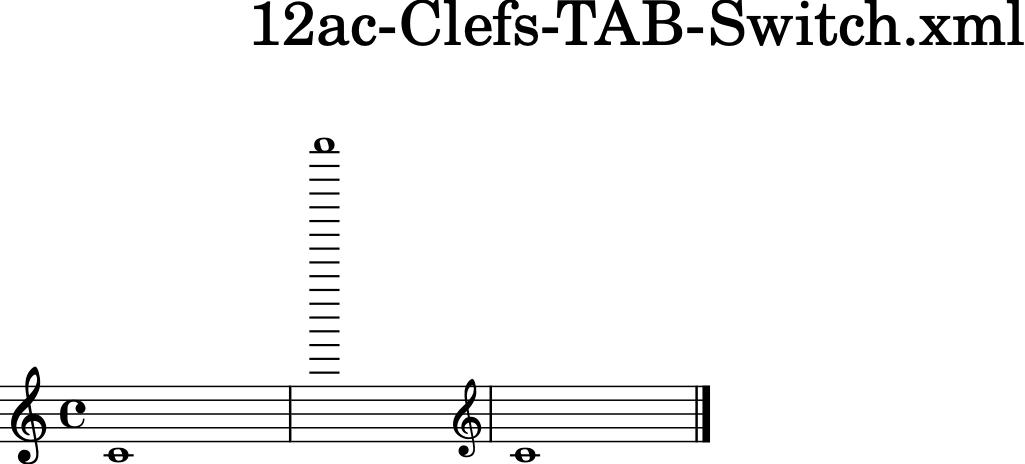

In [34]:
s('12ac') # block: MuseScore

12ad-Clefs-Extreme-Octave.xml

Clefs with abs(octave shifts) > 1 Order: treble 15vb (C2), bass 15vb (C2), treble 15va (C6), bass 15va (C6), treble 22va (C7), bass 22vb (C1). Should all display as middle C if clef octavation is ignored 


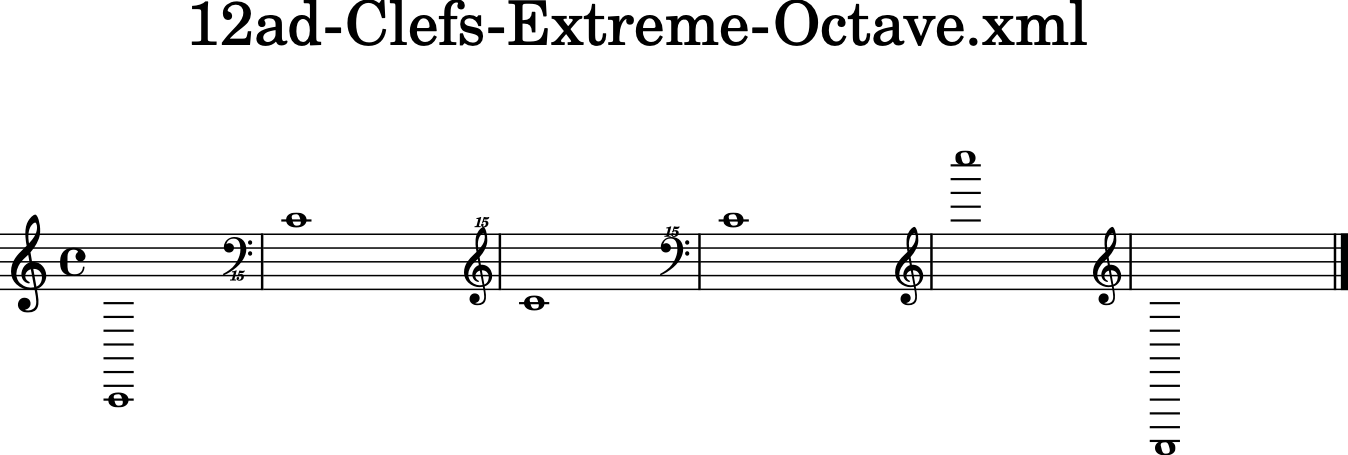

In [35]:
s('12ad') # block: MuseScore on treble 15vb, treble 22va, bass 22vb.

12b-Clefs-NoKeyOrClef.xml

A score without any key or clef defined. The default (4/4 in treble clef) should be used.


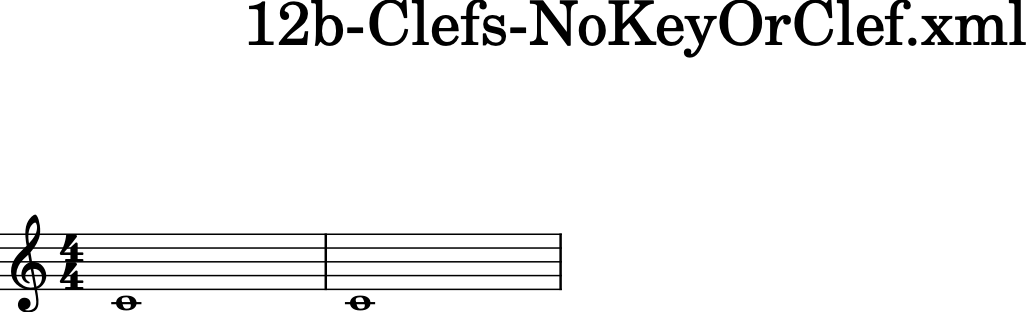

In [36]:
s('12b')

## 13 ... Key signatures

13a-KeySignatures.xml

Various standard key signatures: from 7 flats to 7 sharps (each one first one measure in major, then one measure in minor)


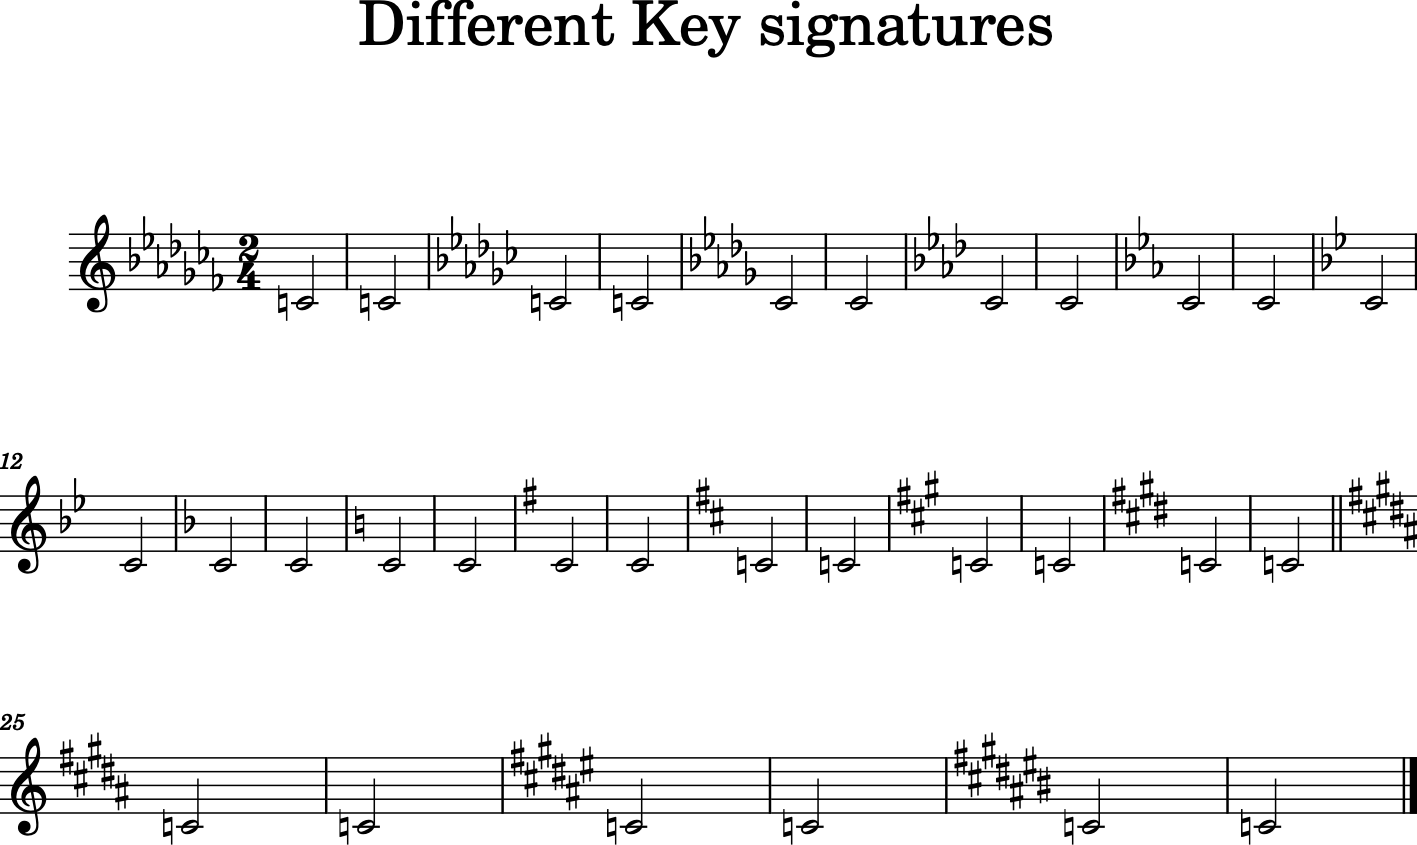

In [37]:
s('13a')

13aa-KeySignatures-Extreme.xml

Various extreme key signatures: from 11 flats to 7 flats and 7 sharps to 11 sharps (all marked as major)


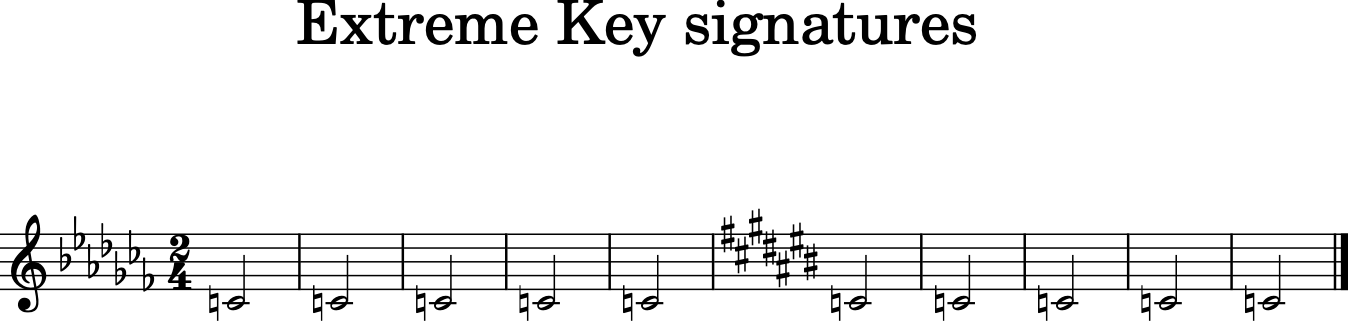

In [38]:
s('13aa') # blocked: MuseScore and Finale (on flats; sharps import fine)

In [39]:
print([ks.sharps for ks in scores['13aa'].recurse().getElementsByClass('KeySignature')])

[-11, -10, -9, -8, -7, 7, 8, 9, 10, 11]


13ab-KeySignatures-Cancel.xml

Tests of key signature cancelation, at default location, at right, and before-barline, then cancelling a key signature that does not exist... 


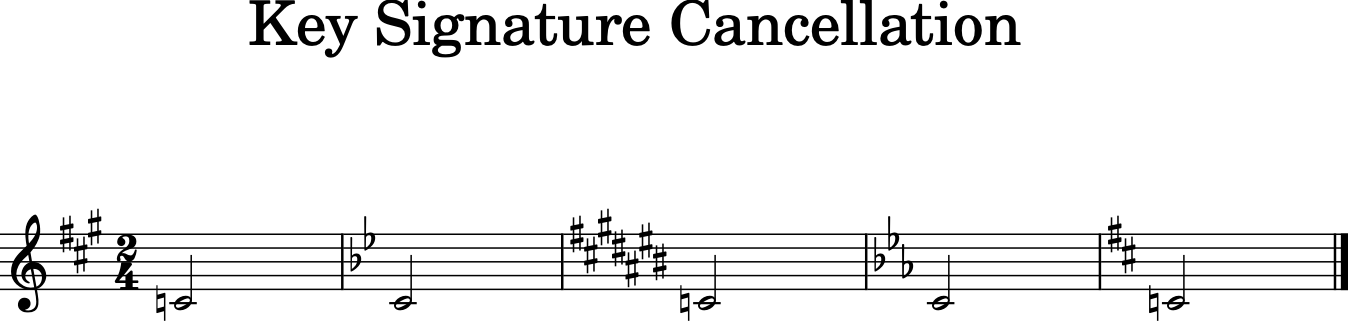

In [40]:
s('13ab') # no music21 support; blocked MuseScore

13ac-KeySignatures-Octaves.xml

Three tests of key signatures at octaves other than defaults. The third example uses the cancel element to cancel previous key signature octaves 


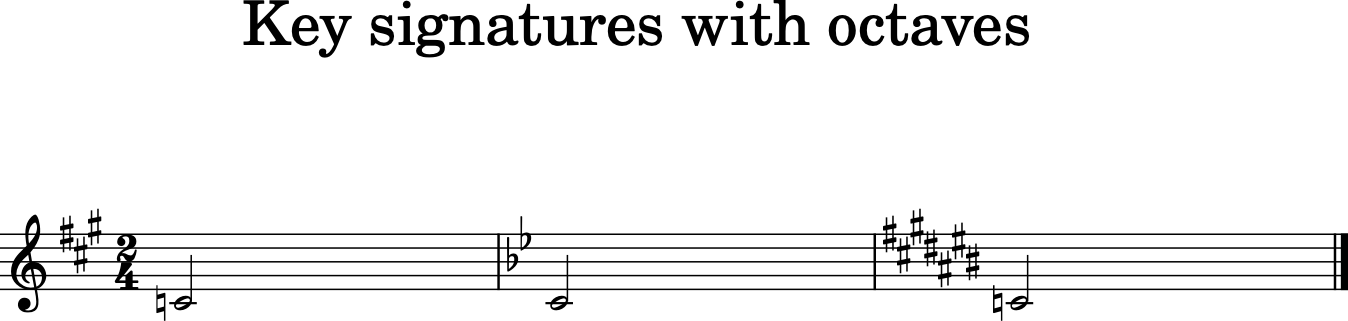

In [41]:
s('13ac') # no music21 support; blocked MuseScore + Finale

13b-KeySignatures-ChurchModes.xml

All different modes: major, minor, ionian, dorian, phrygian, lydian, mixolydian, aeolian, and locrian; All modes are given with 2 sharps.


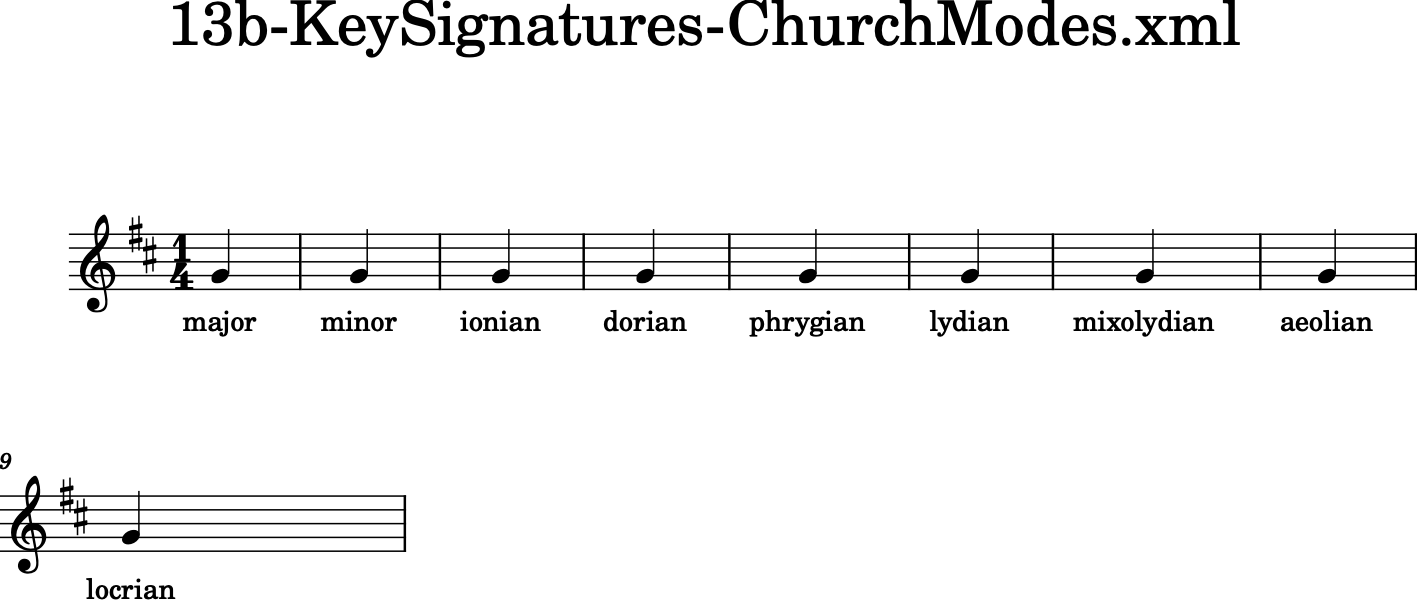

In [42]:
s('13b')

In [43]:
print([k.mode for k in scores['13b'].recurse().getElementsByClass('Key')])

['major', 'minor', 'ionian', 'dorian', 'phrygian', 'lydian', 'mixolydian', 'aeolian', 'locrian']


13c-KeySignatures-NonTraditional.xml

Non-traditional key signatures, where each alteration is separately given. Here we have (f sharp, a flat, b flat) and (c flatflat, g sharp sharp, d flat, b sharp, f natural), where in the second case an explicit octave is given for each alteration.


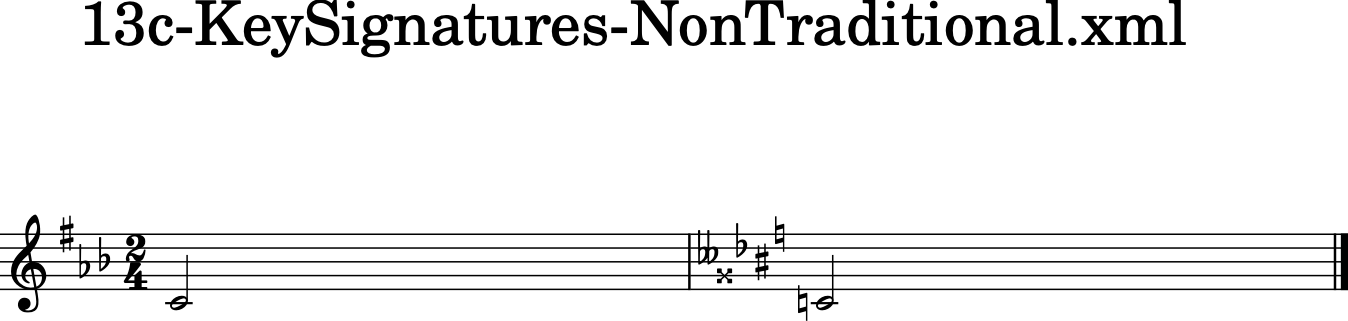

In [44]:
s('13c') # no octave support on musescore or finale

13d-KeySignatures-Microtones.xml

Non-traditional key signatures with microtone alterations: (g flat-and-a-half, a flat, b half-flat, c natural, d half-sharp, e sharp, f sharp-and-a-half).


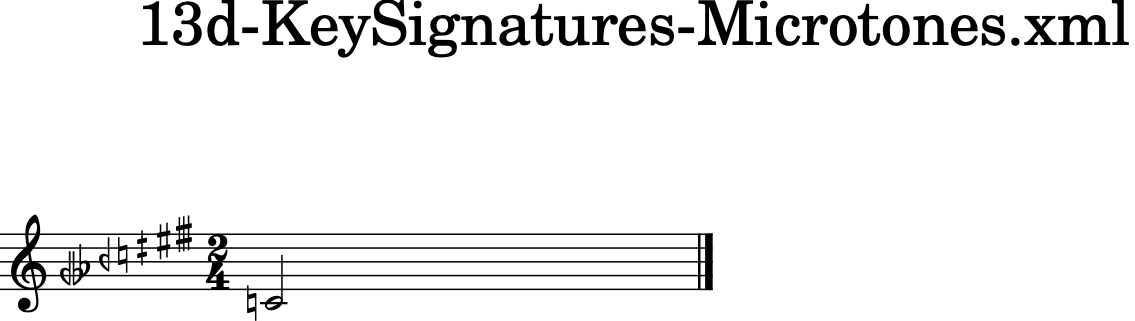

In [45]:
s('13d') # great musescore support except octaves. no Finale support; 

13e-KeySignatures-MidMeasure-Change.xml

Mid-Measure Key-Change: 2 sharps, 2 flats, 0 sharps/flats, 7 sharps, no mode.


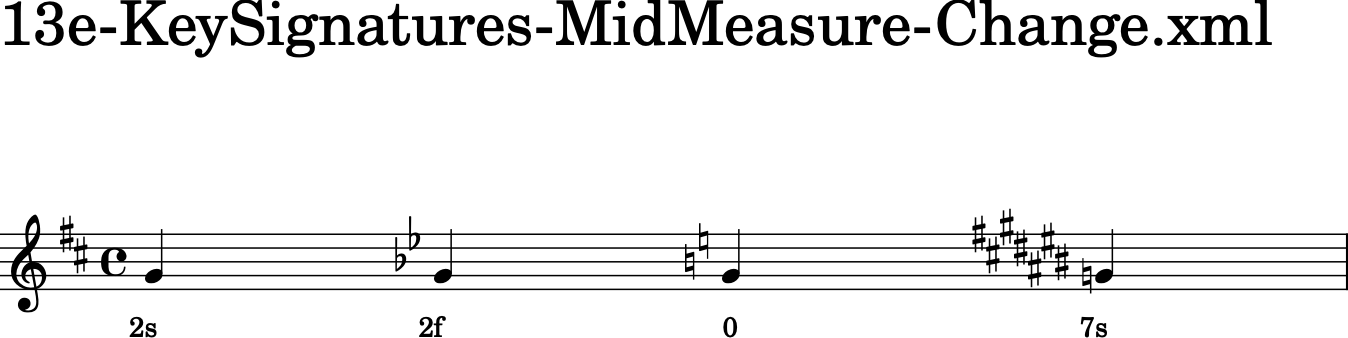

In [46]:
s('13e')

## 14 ... Staff attributes

14a-StaffDetails-LineChanges.xml

The number of staff lines can be modified by using the staff-lines child of the staff-details attribute. This can happen globally (the first staff has one line globally) or during the part at the beginning of a measure and even inside a measure (the second part has 5 lines initially, 4 at the beginning of the second measure, and 3 starting in the middle of the third measure).


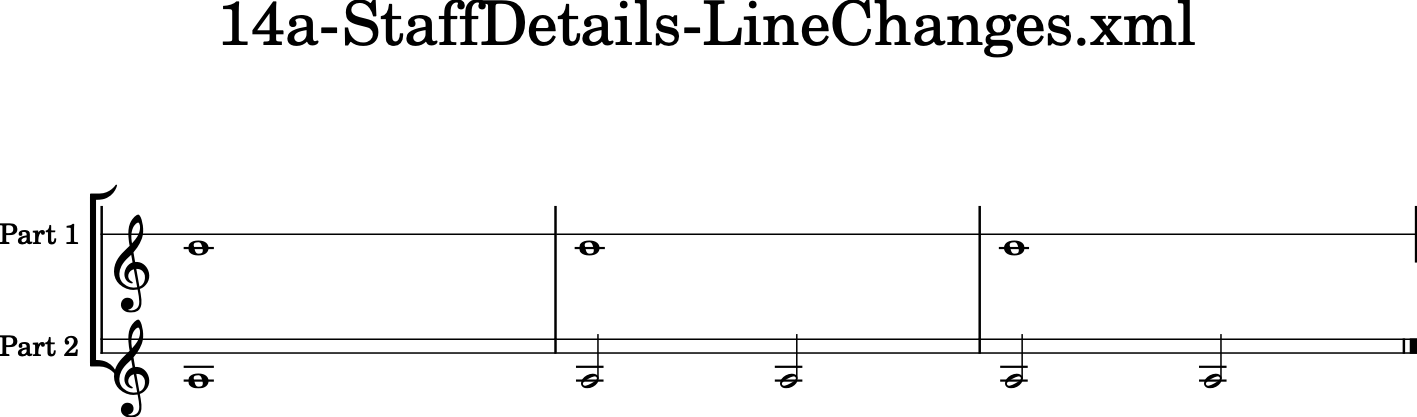

In [47]:
# failing on mid-measure staff-details change. 
# Incorrect interpretation of lines is MuseScore; finale incorrect also
s('14a') 

## 21 ... Chorded notes

21a-Chord-Basic.xml

One simple chord consisting of two notes.


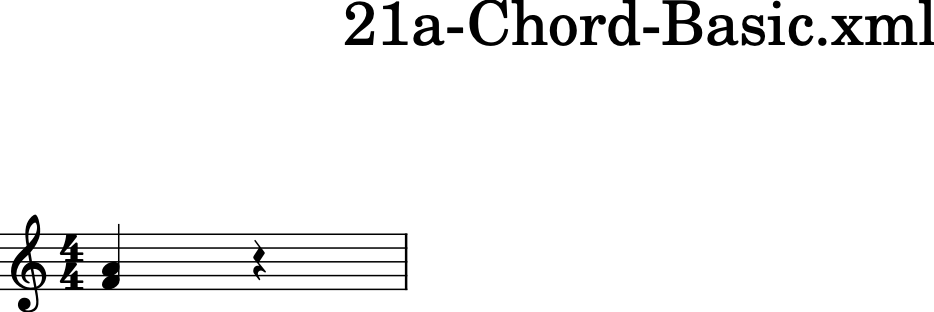

In [48]:
s('21a')

21b-Chords-TwoNotes.xml

Some subsequent (identical) two-note chords.


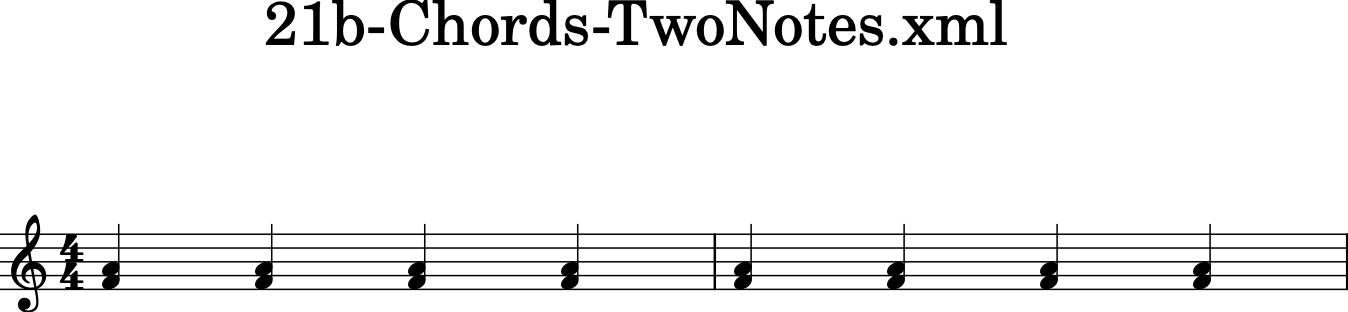

In [49]:
s('21b')

21c-Chords-ThreeNotesDuration.xml

Some three-note chords, with various durations.


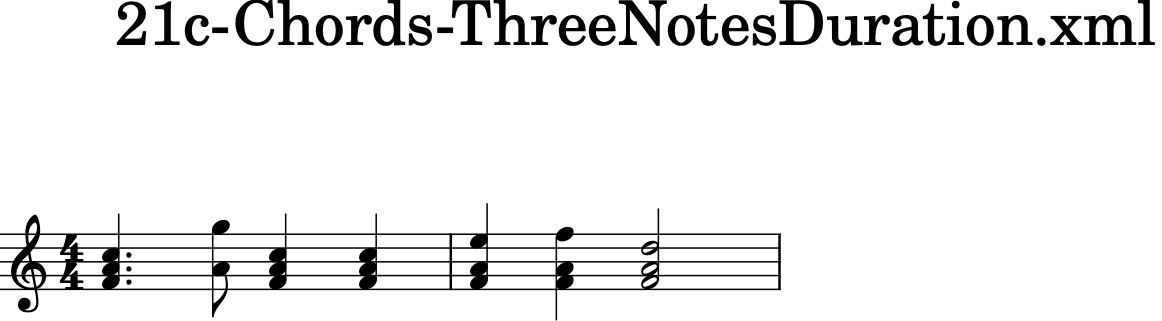

In [50]:
s('21c')

21d-Chords-SchubertStabatMater.xml

Chords in the second measure, after several ornaments in the first measure and a p at the beginning of the second measure.


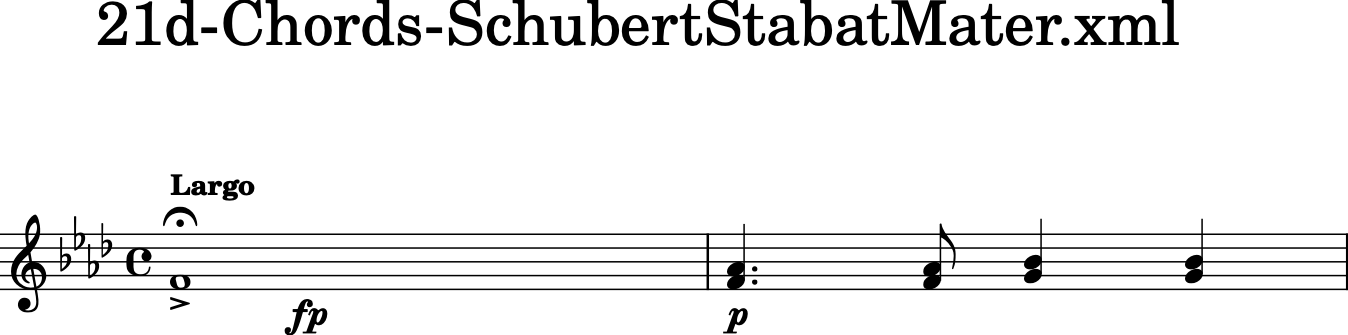

In [51]:
s('21d')

21e-Chords-PickupMeasures.xml

Check for proper chord detection after a pickup measure (i.e. the first beat of the measure is not aligned with multiples of the time signature)!


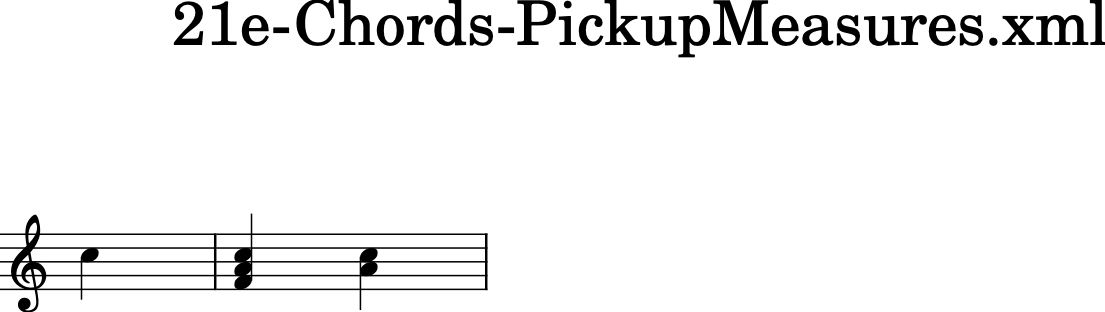

In [52]:
s('21e')

21f-Chord-ElementInBetween.xml

Between the individual notes of a chord there can be direction or harmony elements, which should be properly assigned to the chord (or the position of the chord).


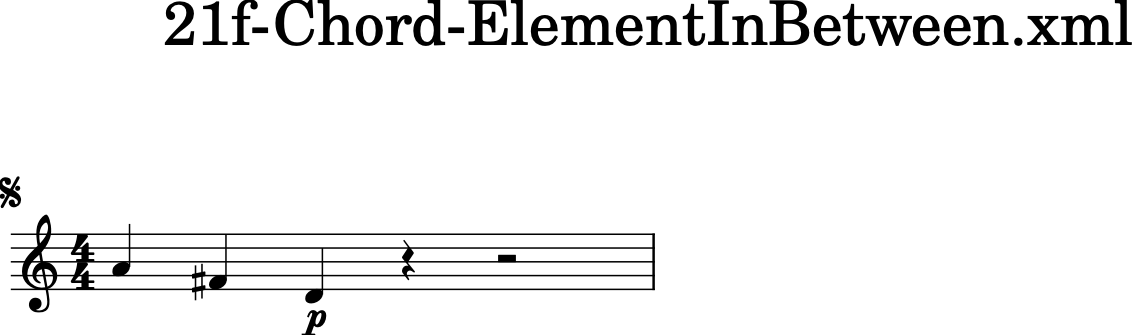

In [53]:
s('21f') # failing -- finale interprets chord correctly, but not the p; musescore, perfect.

## 22 ... Note settings, heads, etc.

22a-Noteheads.xml

Different note styles, using the <notehead> element. First, each note head style is printed with four quarter notes, two with filled heads, two with unfilled heads, where first the stem is up and then the stem is down. After that, each note head style is printed with a half note (should have an unfilled head by default). Finally, the Aiken note head styles are tested, once with stem up and once with stem down.


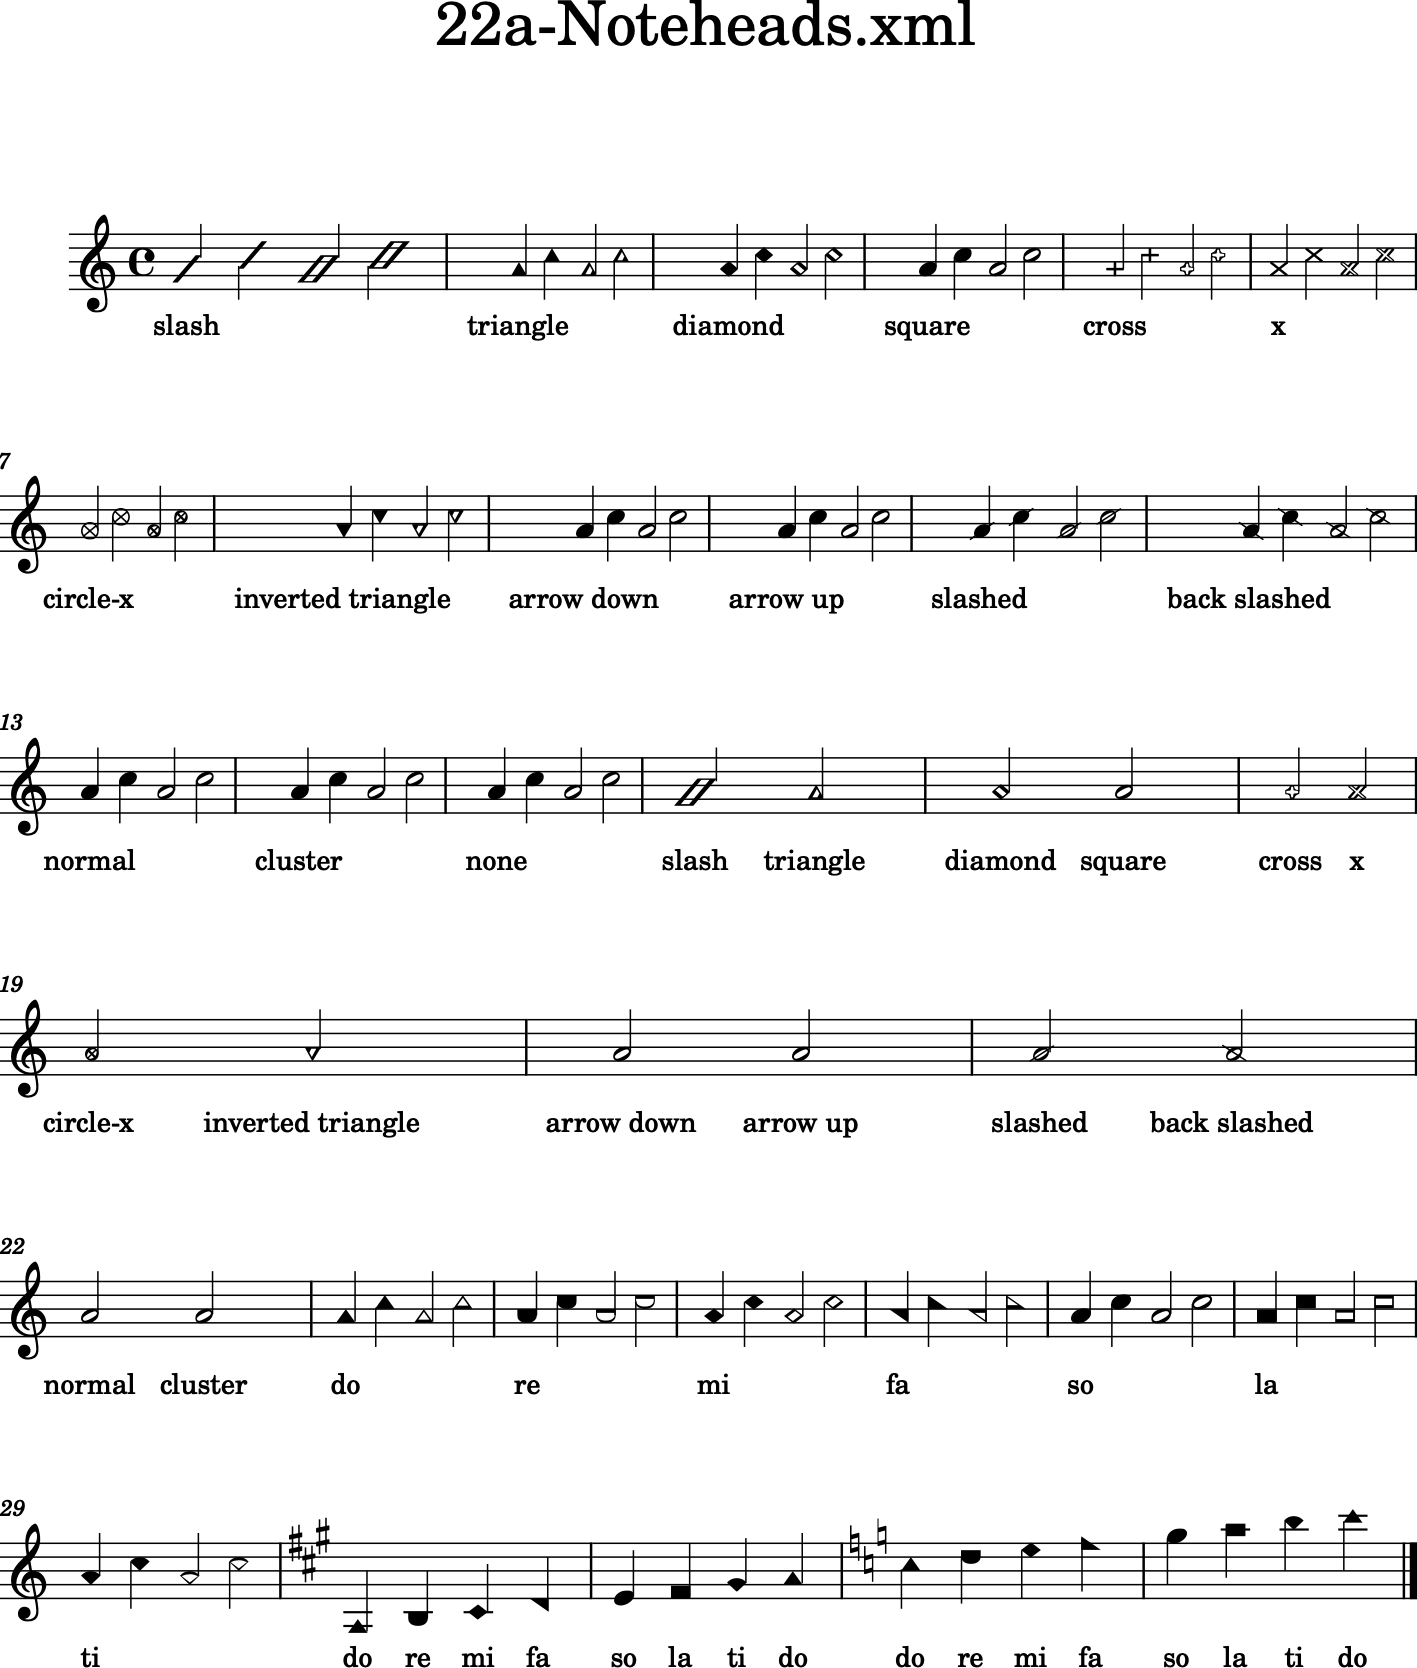

In [54]:
s('22a') # block: MuseScore; finale gets all but Cluster

22b-Staff-Notestyles.xml

Staff-connected note styles: slash notation, hidden notes (with and without hidden staff lines)


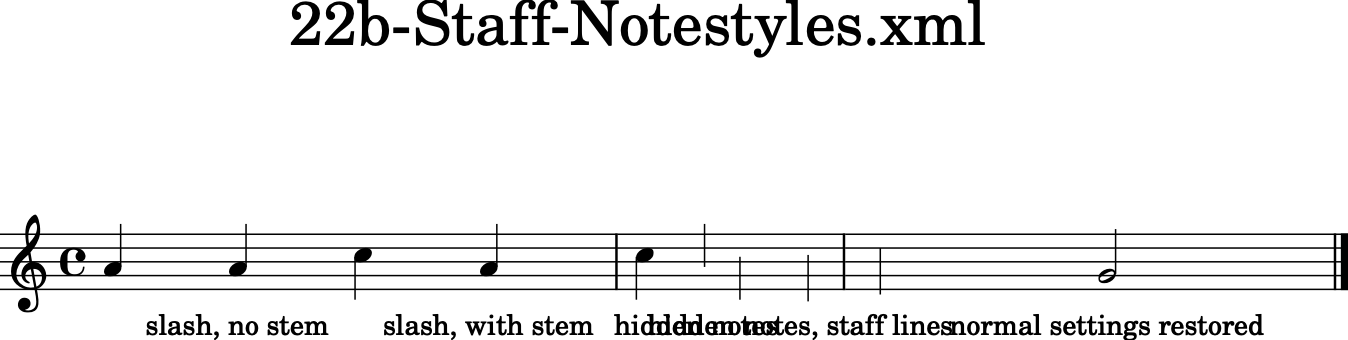

In [55]:
s('22b') # failing; finale gets right; musescore: as shown.

22c-Noteheads-Chords.xml

Different note styles for individual notes inside a chord, using the <notehead> element.


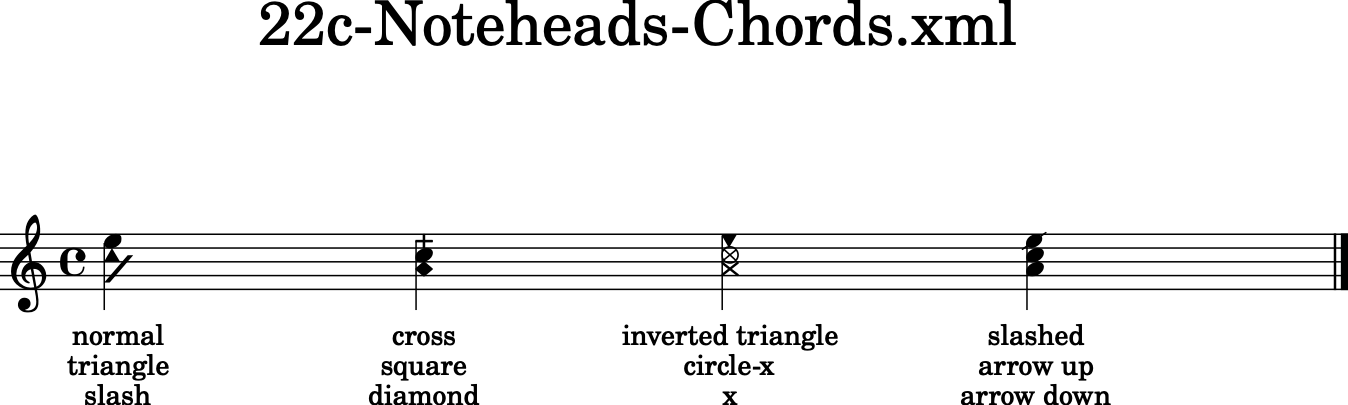

In [56]:
s('22c') # blocked by MuseScore: 22a

22d-Parenthesized-Noteheads.xml

Parenthesized note heads. First, a single parenthesized note is tested, once with a normal and then with a non-standard notehead, then two chords with some/all parenthesized noteheads and finally a parenthesized rest.


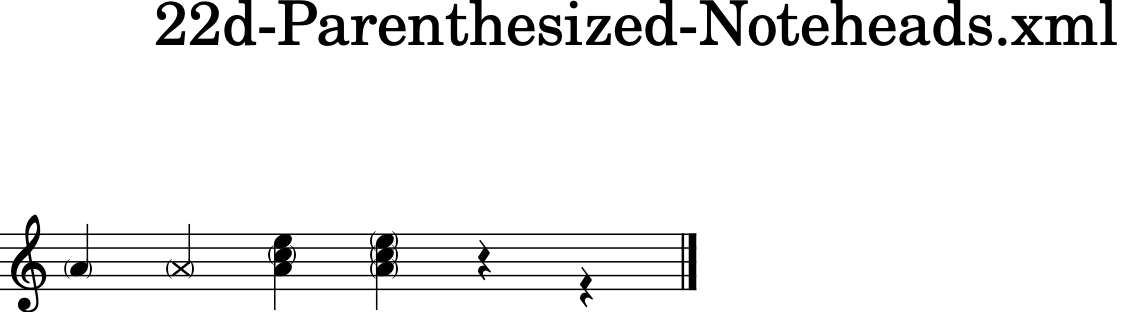

In [57]:
s('22d') # failing parenthesized rest; block MuseScore.  Finale no support.

## 23 ... Triplets, Tuplets

23a-Tuplets.xml

Some tuplets (3:2, 3:2, 3:2, 4:2, 4:1, 7:3, 6:2) with the default tuplet bracket displaying the number of actual notes played. The second tuplet does not have a number attribute set.


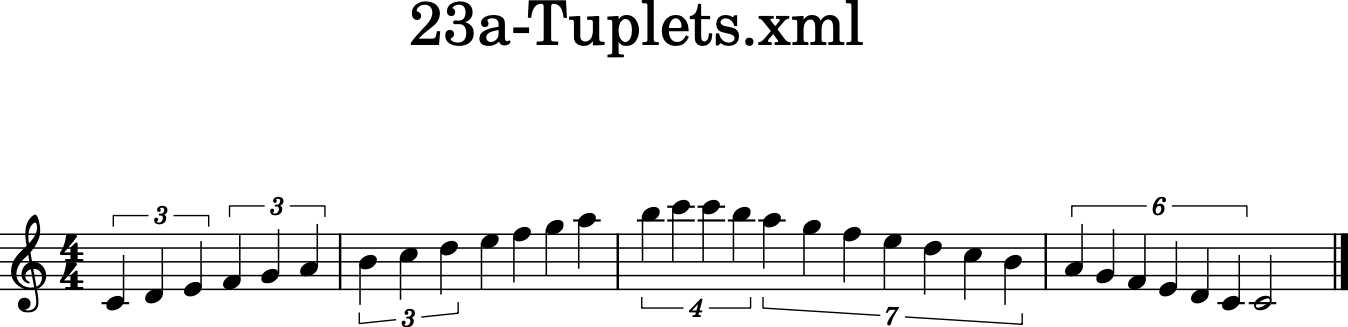

In [58]:
s('23a') # blocking on MuseScore not liking 4:2 (but okay on 4:1)

In [59]:
for n in scores['23a'].recurse().notes:
    if n.duration.tuplets:
        print(n.duration.tuplets[0], n.duration.tuplets[0].type)

<music21.duration.Tuplet 3/2/quarter> start
<music21.duration.Tuplet 3/2/quarter> None
<music21.duration.Tuplet 3/2/quarter> stop
<music21.duration.Tuplet 3/2/quarter> start
<music21.duration.Tuplet 3/2/quarter> None
<music21.duration.Tuplet 3/2/quarter> stop
<music21.duration.Tuplet 3/2/quarter> start
<music21.duration.Tuplet 3/2/quarter> None
<music21.duration.Tuplet 3/2/quarter> stop
<music21.duration.Tuplet 4/2/quarter> start
<music21.duration.Tuplet 4/2/quarter> None
<music21.duration.Tuplet 4/2/quarter> None
<music21.duration.Tuplet 4/2/quarter> stop
<music21.duration.Tuplet 4/1/quarter> start
<music21.duration.Tuplet 4/1/quarter> None
<music21.duration.Tuplet 4/1/quarter> None
<music21.duration.Tuplet 4/1/quarter> stop
<music21.duration.Tuplet 7/3/quarter> start
<music21.duration.Tuplet 7/3/quarter> None
<music21.duration.Tuplet 7/3/quarter> None
<music21.duration.Tuplet 7/3/quarter> None
<music21.duration.Tuplet 7/3/quarter> None
<music21.duration.Tuplet 7/3/quarter> None
<musi

In [60]:
scores['23a'].show('text')

{0.0} <music21.metadata.Metadata object at 0x122474940>
{0.0} <music21.stream.Part MusicXML Part>
    {0.0} <music21.instrument.Instrument 'P1: MusicXML Part: '>
    {0.0} <music21.stream.Measure 1 offset=0.0>
        {0.0} <music21.clef.TrebleClef>
        {0.0} <music21.key.Key of C major>
        {0.0} <music21.meter.TimeSignature 4/4>
        {0.0} <music21.note.Note C>
        {0.6667} <music21.note.Note D>
        {1.3333} <music21.note.Note E>
        {2.0} <music21.note.Note F>
        {2.6667} <music21.note.Note G>
        {3.3333} <music21.note.Note A>
    {4.0} <music21.stream.Measure 2 offset=4.0>
        {0.0} <music21.note.Note B>
        {0.6667} <music21.note.Note C>
        {1.3333} <music21.note.Note D>
        {2.0} <music21.note.Note E>
        {2.5} <music21.note.Note F>
        {3.0} <music21.note.Note G>
        {3.5} <music21.note.Note A>
    {8.0} <music21.stream.Measure 3 offset=8.0>
        {0.0} <music21.note.Note B>
        {0.25} <music21.note.Note C>
    

23b-Tuplets-Styles.xml

Different tuplet styles: default, none, x:y, x:y-note; Each with bracket, slur and none. Finally, non-standard 4:3 and 17:2 tuplets are given.


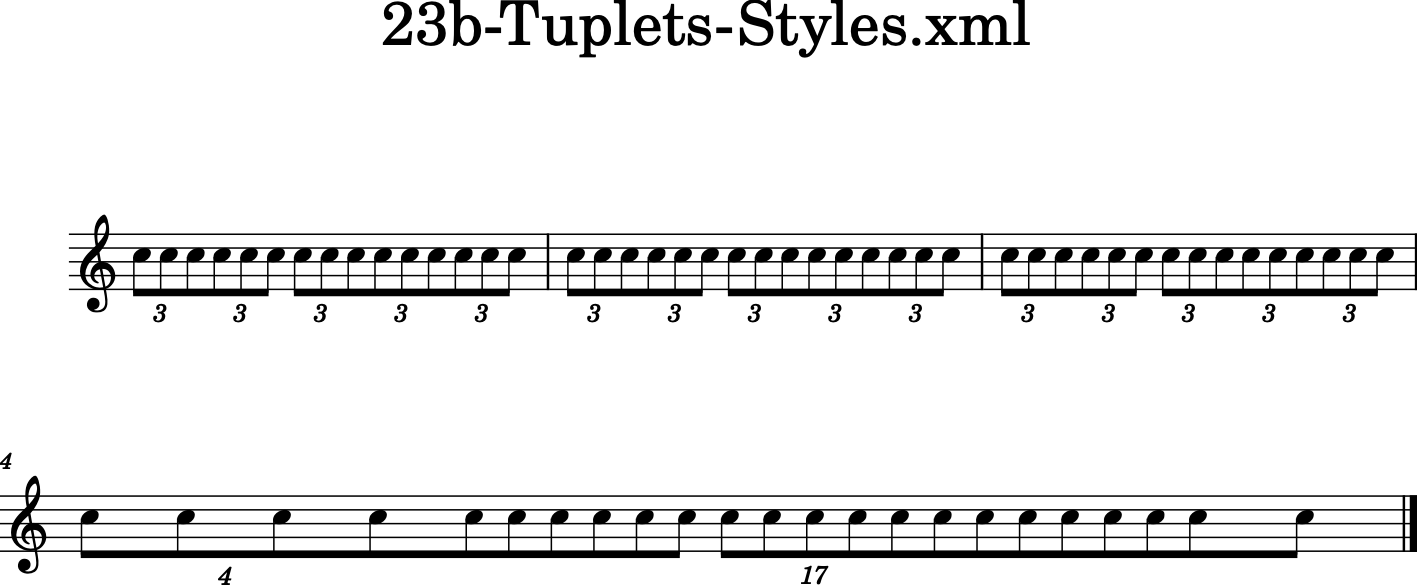

In [61]:
s('23b') # block MuseScore + Finale.  Bad beaming is a separate problem.

23c-Tuplet-Display-NonStandard.xml

Displaying tuplet note types, that might not coincide with the displayed note. The first two tuplets take the type from the note, the second two from the <time-modification> element, the remaining pair of tuplets from the <tuplet> notation element. The tuplets in measure 3 specify both a number of notes and a type inside the <tuplet-actual> and <tuplet-normal> elements, the ones in measure 4 specify only a note type (but no number), and the ones in measure 5 specify only a number of tuplet-notes (but no type, which is deduced from the note's type). The first tuplet of measures 3-5 uses 'display-type="actual"', the second one 'display-type="both"'. FIXME: The tuplet-normal should coincide with the real notes!


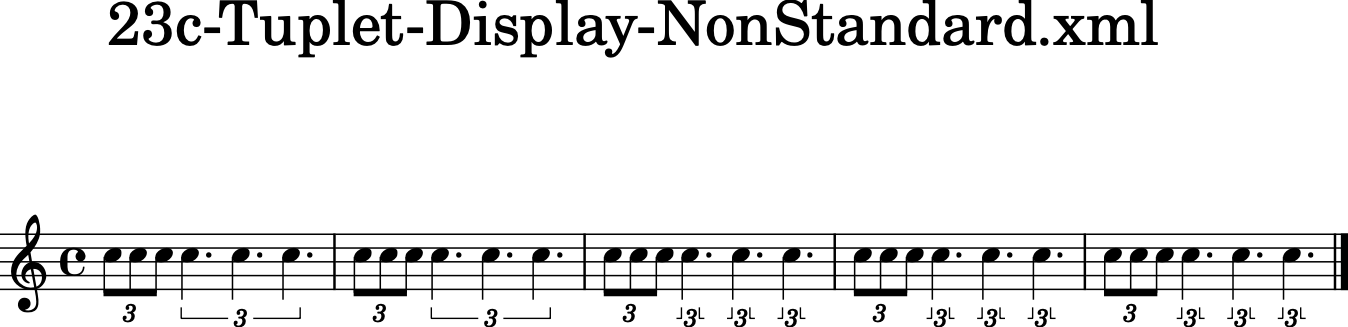

In [62]:
s('23c') # acceptable...

23d-Tuplets-Nested.xml

Tuplets can be nested. Here there is a 5:2 tuplet inside a 3:2 tuple (all consisting of written eighth notes).


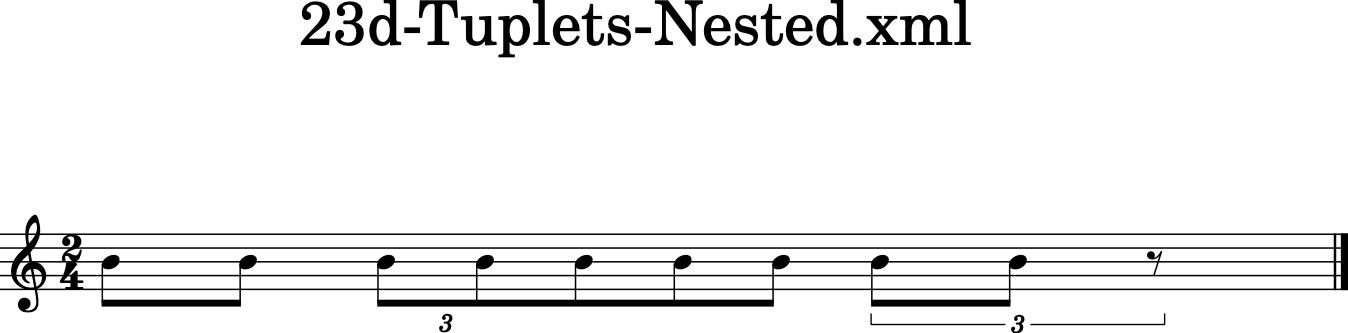

In [63]:
s('23d') # block: musescore

23e-Tuplets-Tremolo.xml

Tremolo tuplets are tuplets on single notes with a tremolo ornament. The application shall correctly import these notes with 2/3 or their time...


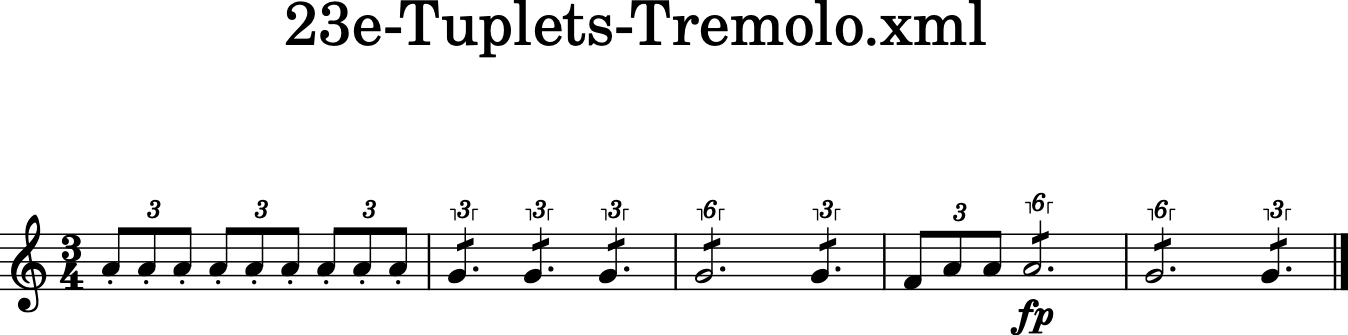

In [64]:
s('23e') 

23f-Tuplets-DurationButNoBracket.xml

Some "triplets" on the end of the first and in the second staff, using only <time-modification>, but not explicit tuplet bracket. Thus, the duration of the notes in the second staff should be scaled properly in comparison to staff 1, but no visual indication about the tuplets is given.


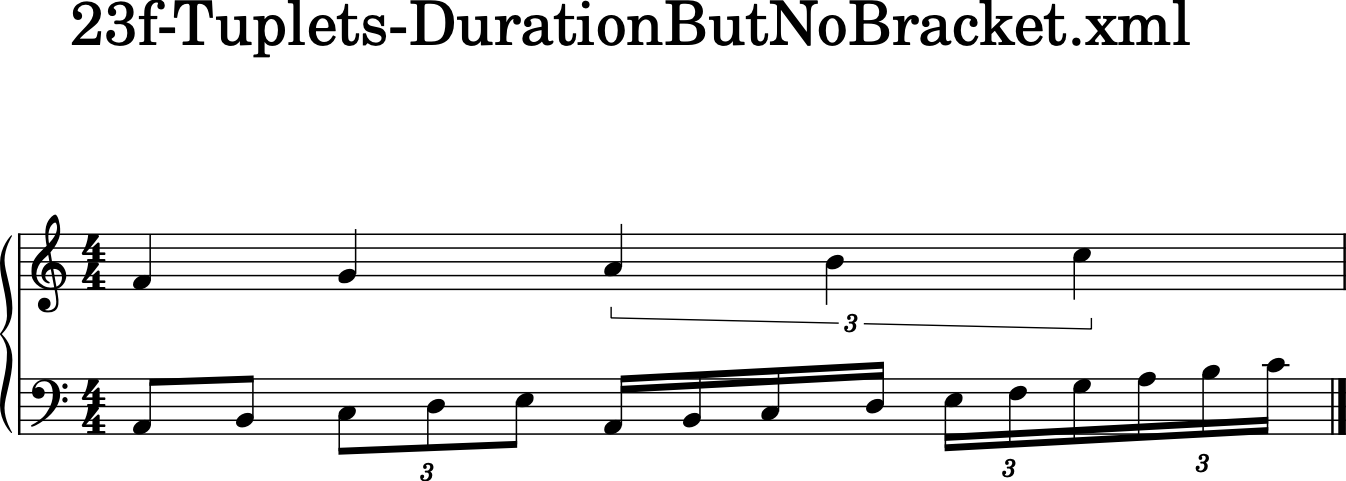

In [65]:
s('23f') # acceptable behavior unless supports Tuplet is explicit.

## 24 ... Grace notes

24a-GraceNotes.xml

Different kinds of grace notes: acciaccatura, appoggiatura; beamed grace notes; grace notes with accidentals; different durations of the grace notes.


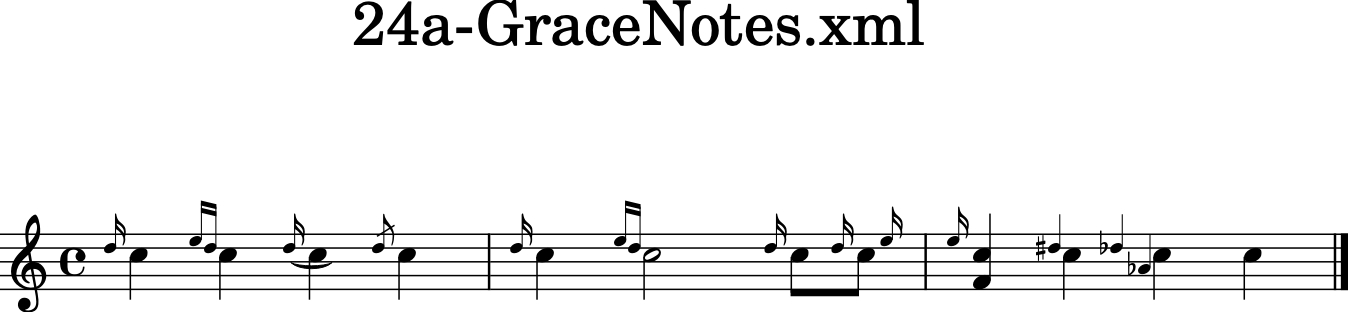

In [66]:
s('24a') # are slurs default?

24b-ChordAsGraceNote.xml

Chords as grace notes.


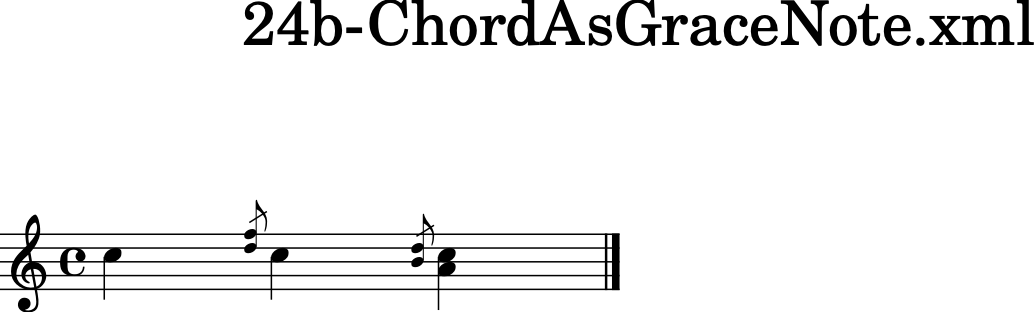

In [67]:
s('24b')

24c-GraceNote-MeasureEnd.xml

A grace note that appears at the measure end (without any steal-from-* attribute set). Some applications need to convert this into an after-grace.


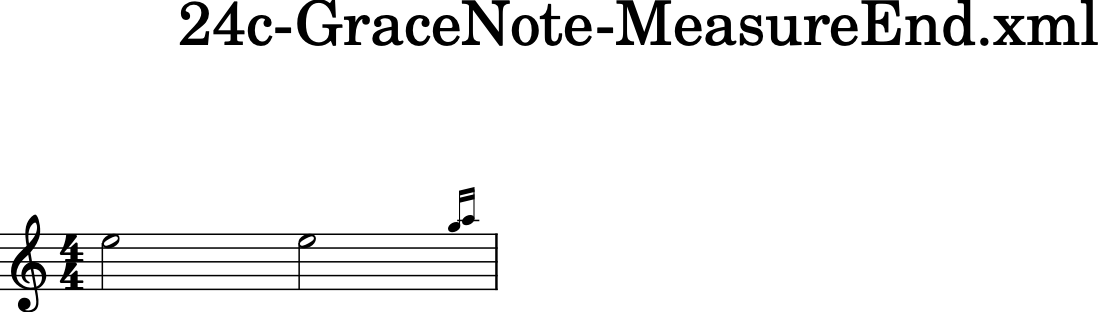

In [68]:
s('24c')

24d-AfterGrace.xml

Some grace notes and after-graces (indicated by steal-time-previous and steal-time-following).


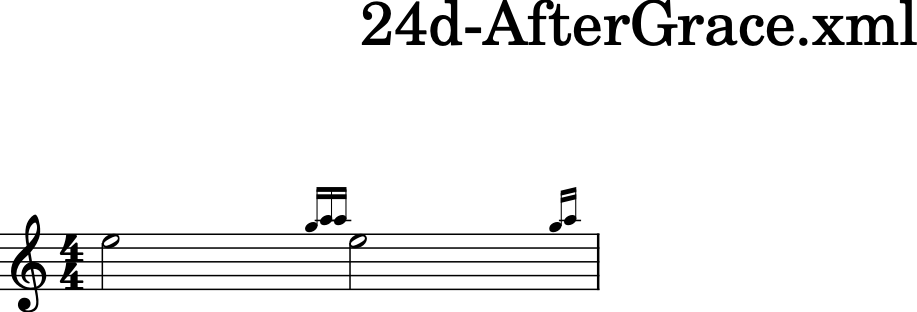

In [69]:
s('24d')

24e-GraceNote-StaffChange.xml

A grace note on a different staff than the actual note.


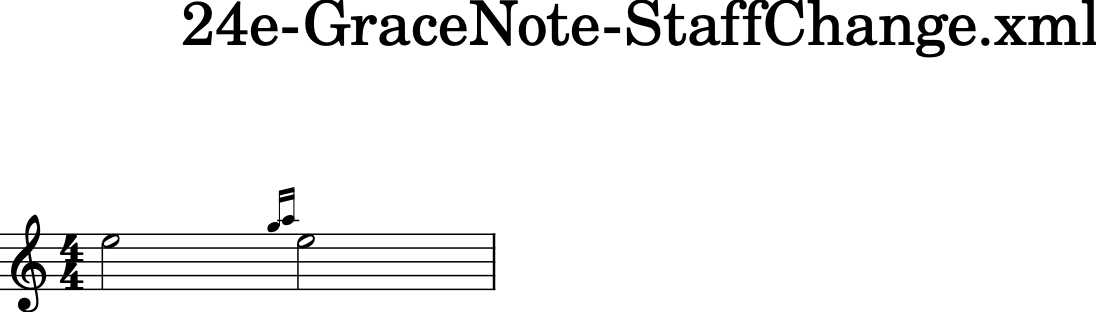

In [70]:
s('24e') # failing but blocked by MuseScore and Finale

24f-GraceNote-Slur.xml

A grace note with a slur to the actual note. This can be interpreted as acciaccatura or appoggiatura, depending on the existence of a slash.


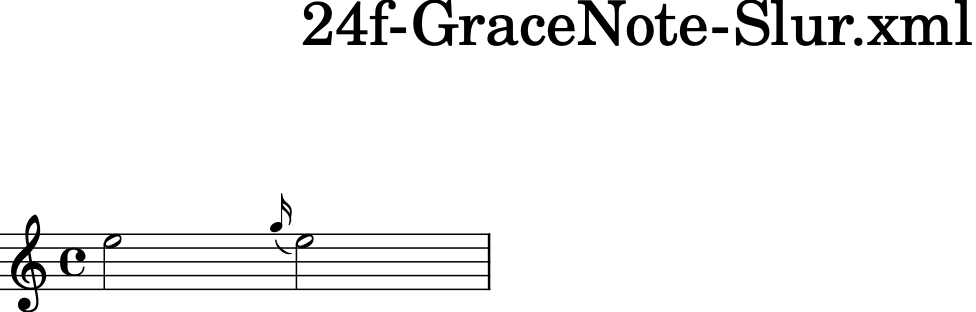

In [71]:
s('24f')

In [72]:
grace = scores['24f'].recurse().notes[1]
grace.duration.isGrace

True

In [73]:
sl = scores['24f'].recurse().getElementsByClass('Slur')[0]
sl[0]

<music21.note.Note G>

In [74]:
sl[0] is grace

True

## 31 ... Dynamics and other single symbols

31a-Directions.xml

All <direction> elements defined in MusicXML. The lyrics for each note describes the direction element assigned to that note.


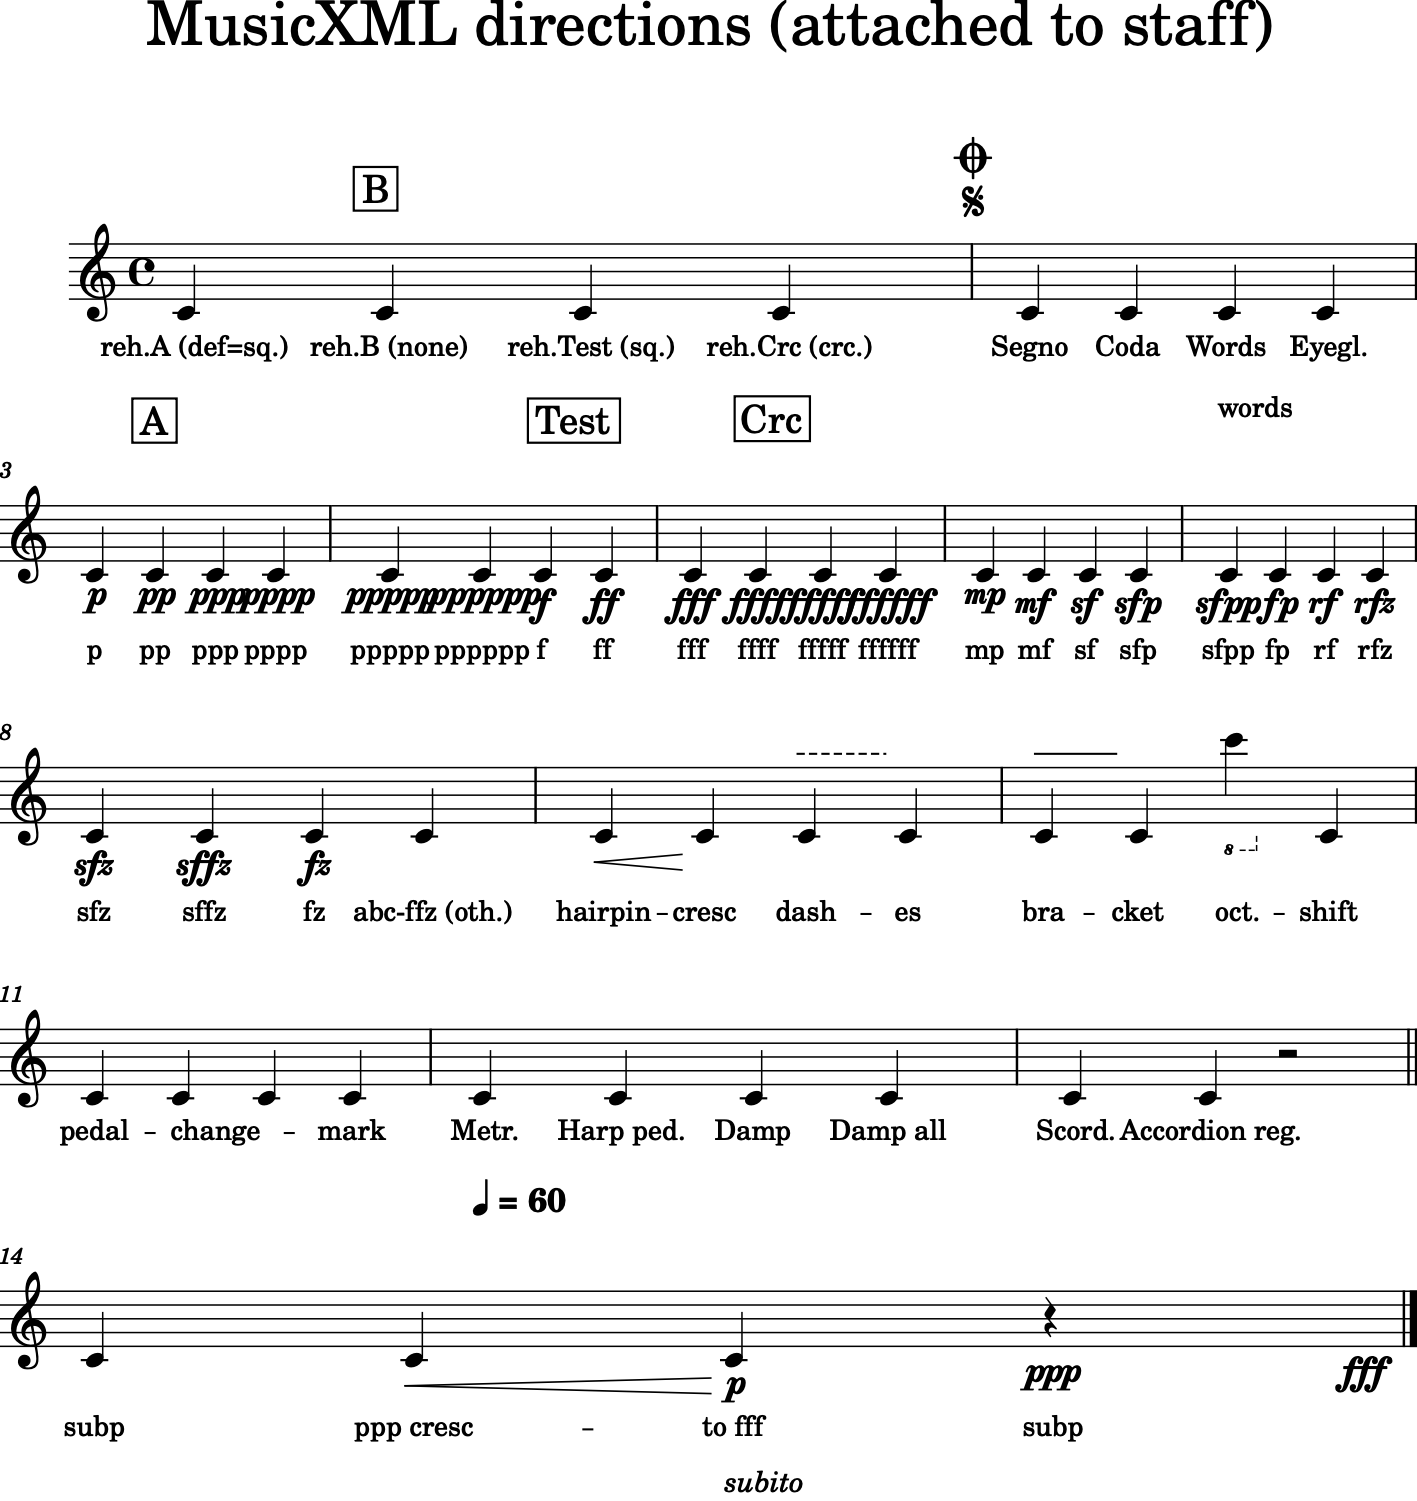

In [75]:
s('31a') # todo, split...

31c-MetronomeMarks.xml

Tempo Markings: note=bpm, text (note=bpm), note=note, (note=note), (note=bpm)


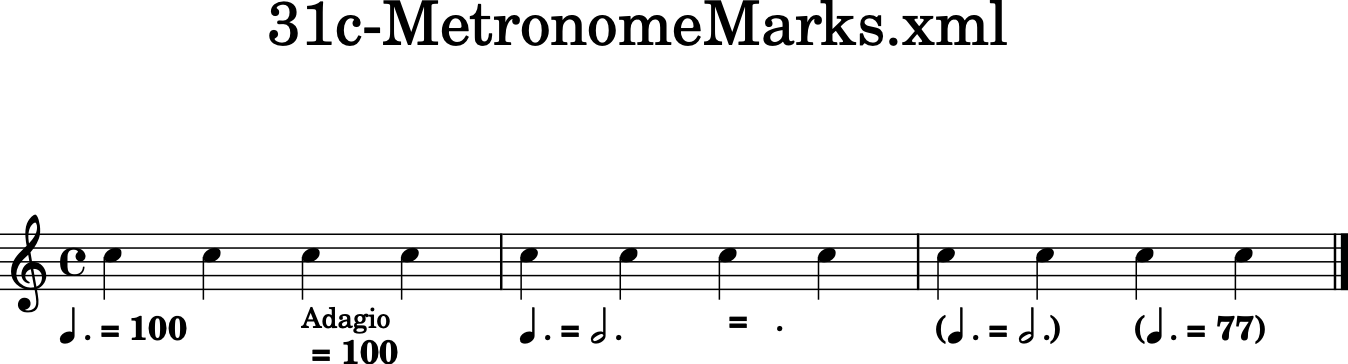

In [76]:
s('31c') # todo, split

## 32 ... Notations and Articulations

32a-Notations.xml

All <notation> elements defined in MusicXML. The lyrics show the notation assigned to each note.


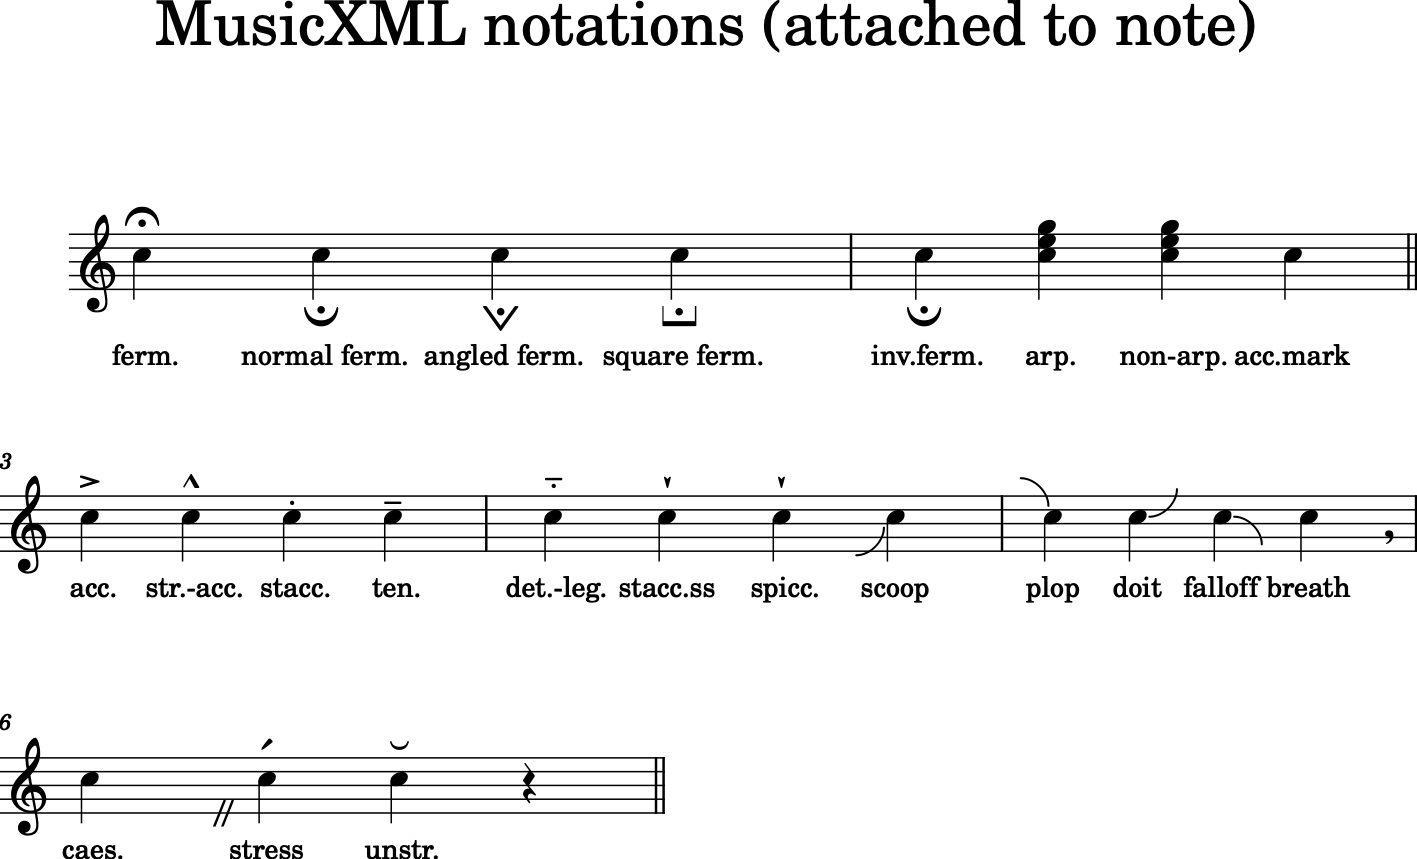

In [77]:
# failling on normal from, angled ferm, squareferm position; 
# arp., non-arp., acc.mark (block museScore -- what is this?),
s('32a-Notations') 

32aa-Notations2_Ornaments.xml

All <ornament> elements defined in MusicXML. The lyrics show the ornament assigned to each note.


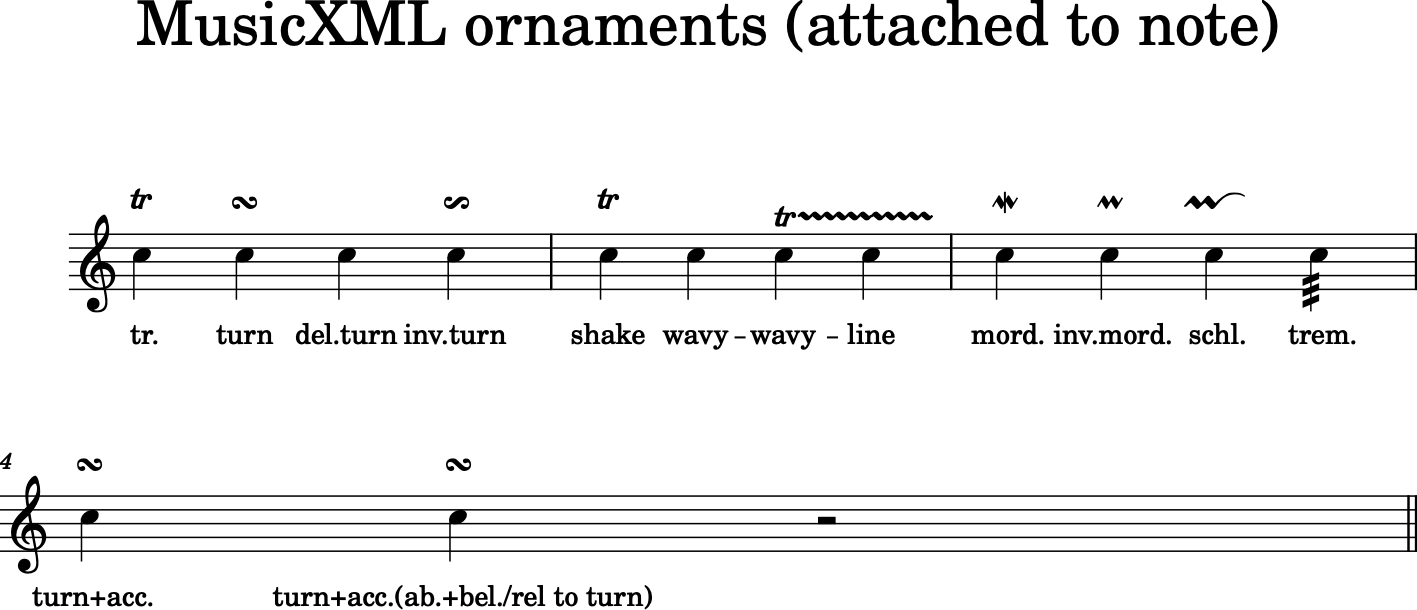

In [78]:
# failing on delayed turn (at least a turn should be put in), 
# turn + accidental (block: museScore).
s('32aa')

32ab-Notations3.xml

All <technical> elements defined in MusicXML. The lyrics show the technical assigned to each note.


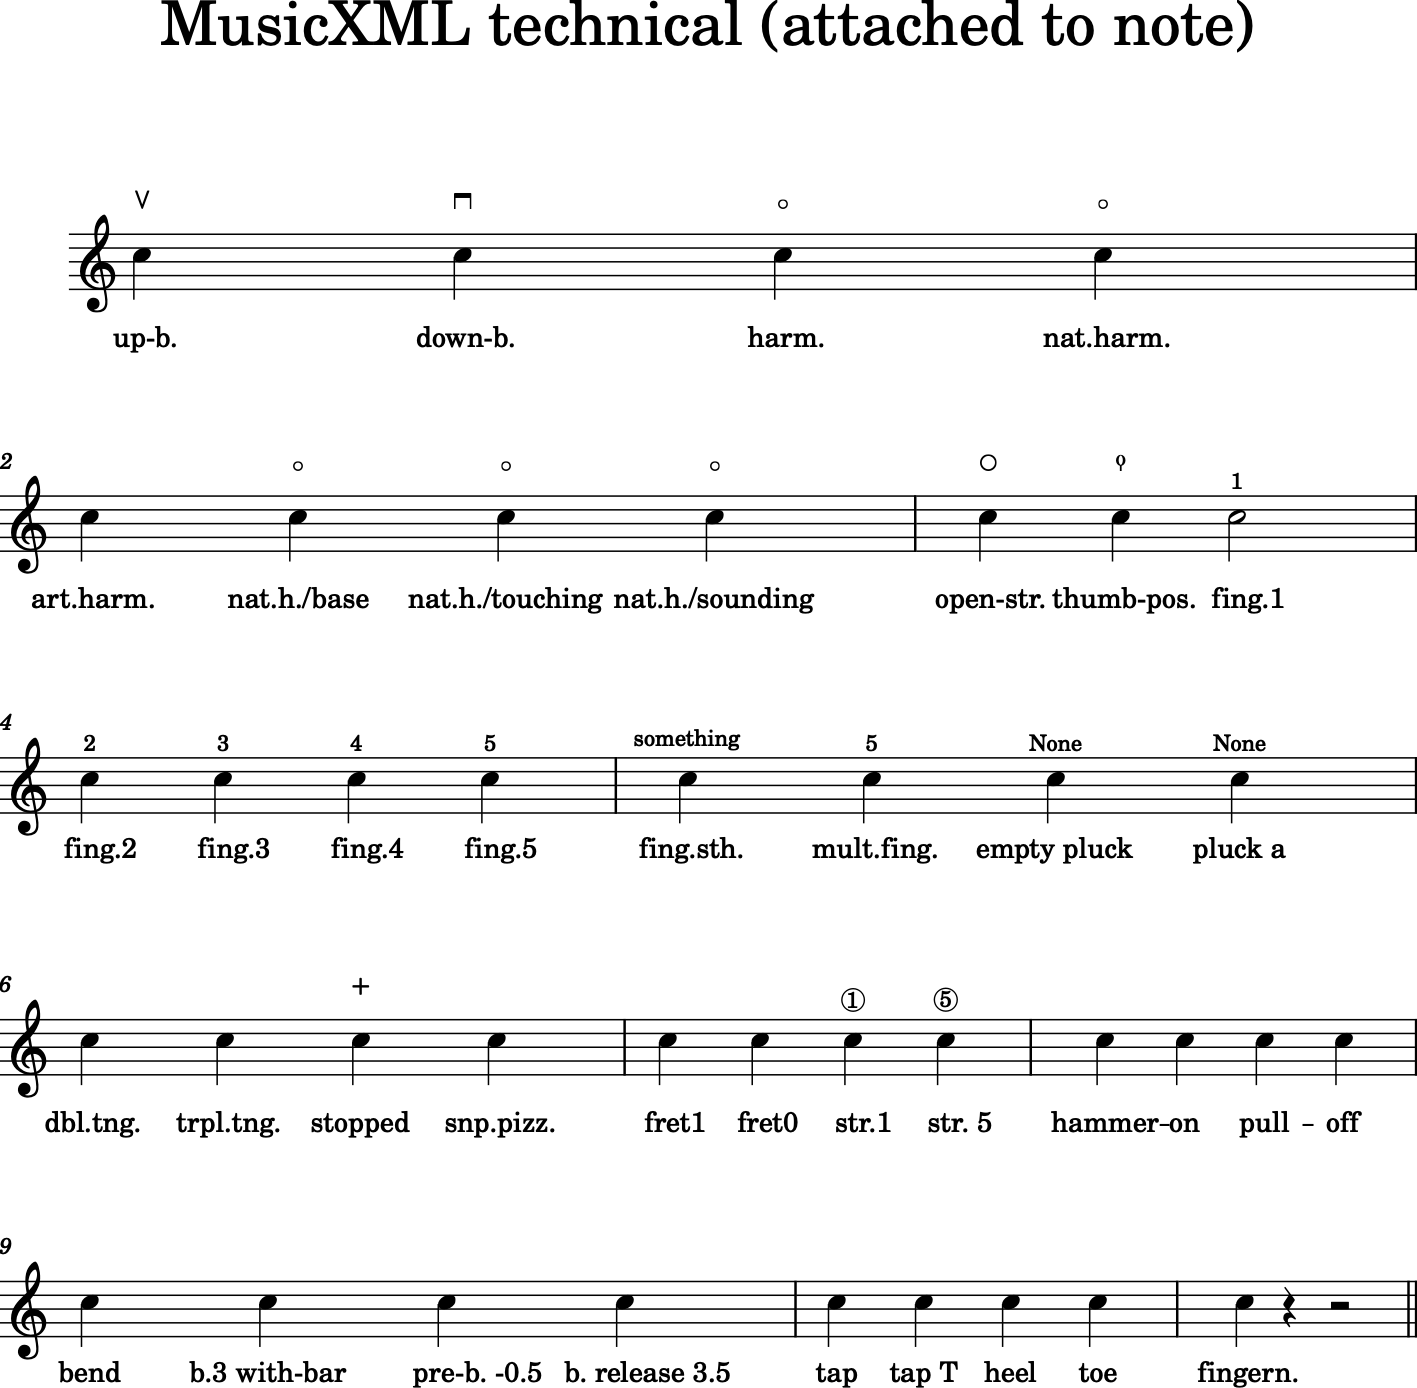

In [79]:
# harmonics -- all: block museScore
# dbl + trp. tongue (block MS), fre1, fret0 (block MS)
# all from "hammer" to the end: blocked by MS.
s('32ab')

32ac-Notations4.xml

Some miscellanious <notation> elements defined in MusicXML including dynamics in notations. The lyrics show the notation assigned to each note.


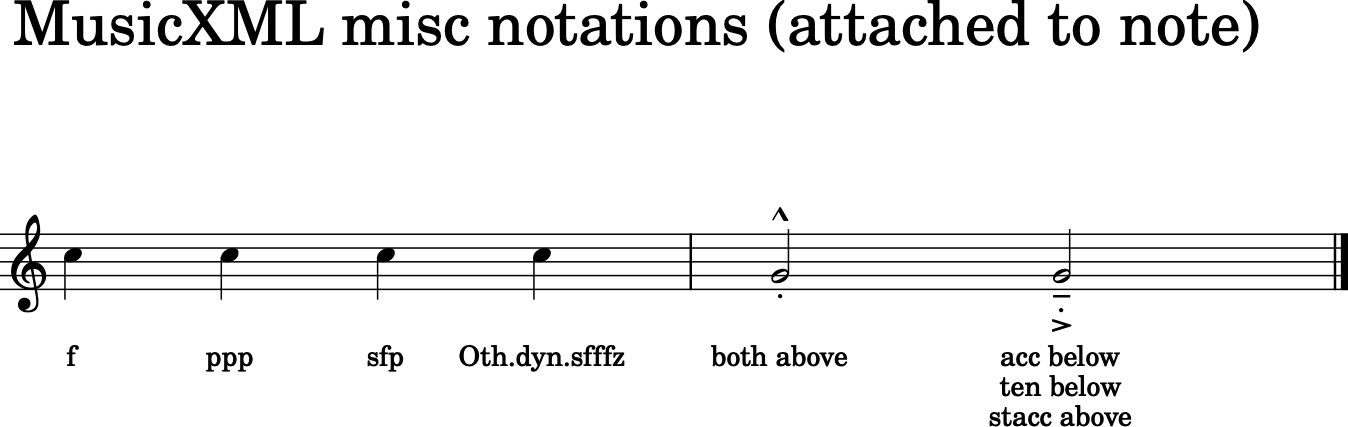

In [80]:
# failing: dynamics in misc notations
# accent positions not working on MS either -- may be a change in standard.
s('32ac')

32b-Articulations-Texts.xml

Text markup: different font sizes, weights and colors.


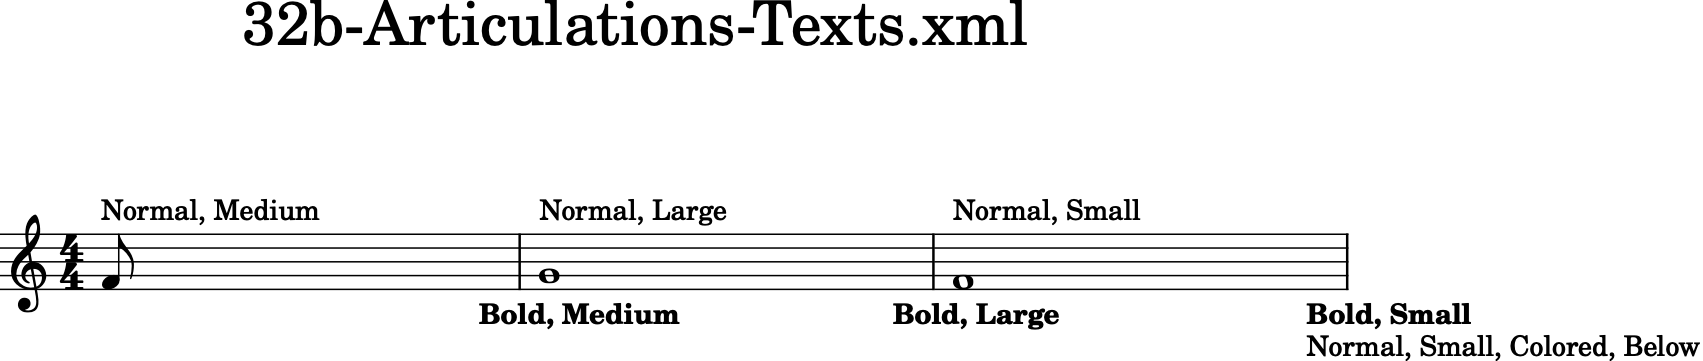

In [81]:
s('32b')  # font-sizes, colors not working.

32c-MultipleNotationChildren.xml

 It should not make any difference whether two articulations are given inside two different notation elements, inside two different articulations children of the same notation element or inside the same articulations element. Thus, all three notes should have a staccato and an accent. 


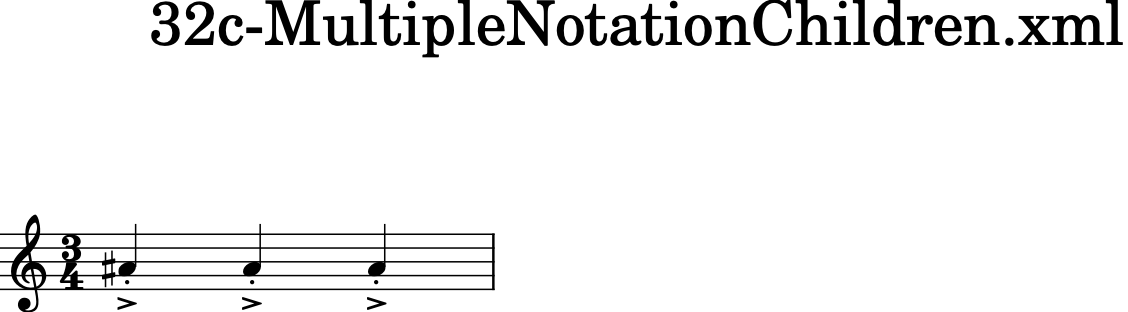

In [82]:
s('32c')

32d-Arpeggio.xml

Different Arpeggio directions (normal, up, down, non-arpeggiate)


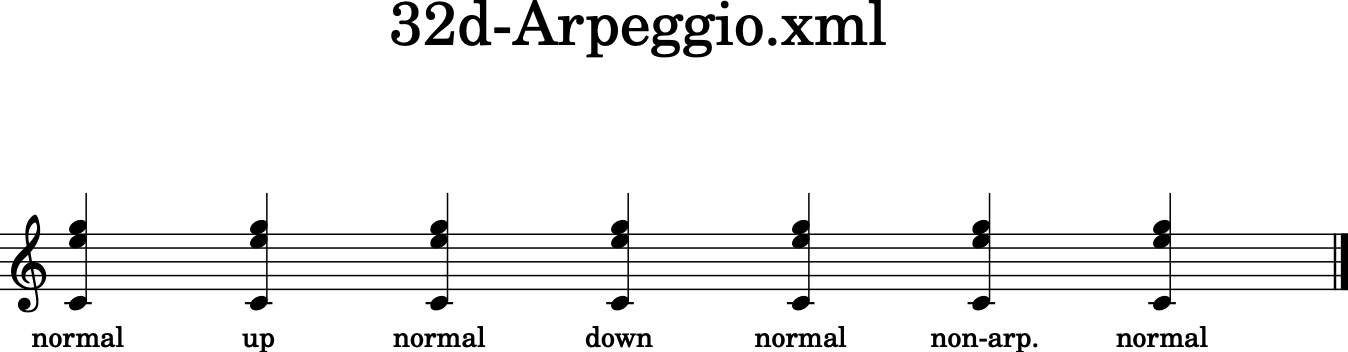

In [83]:
s('32d') # block M21 not supported; musescore supports all.

## 33 ... Spanners

33a-Spanners.xml

Several spanners defined in MusicXML: tuplet, slur (solid, dashed), tie, wedge (cresc, dim), tr + wavy-line, single-note trill spanner, octave-shift (8va,15mb), bracket (solid down/down, dashed down/down, solid none/down, dashed none/up, solid none/none), dashes, glissando (wavy), bend-alter, slide (solid), grouping, two-note tremolo (B to D#), hammer-on, pull-off, pedal (down, change, up).


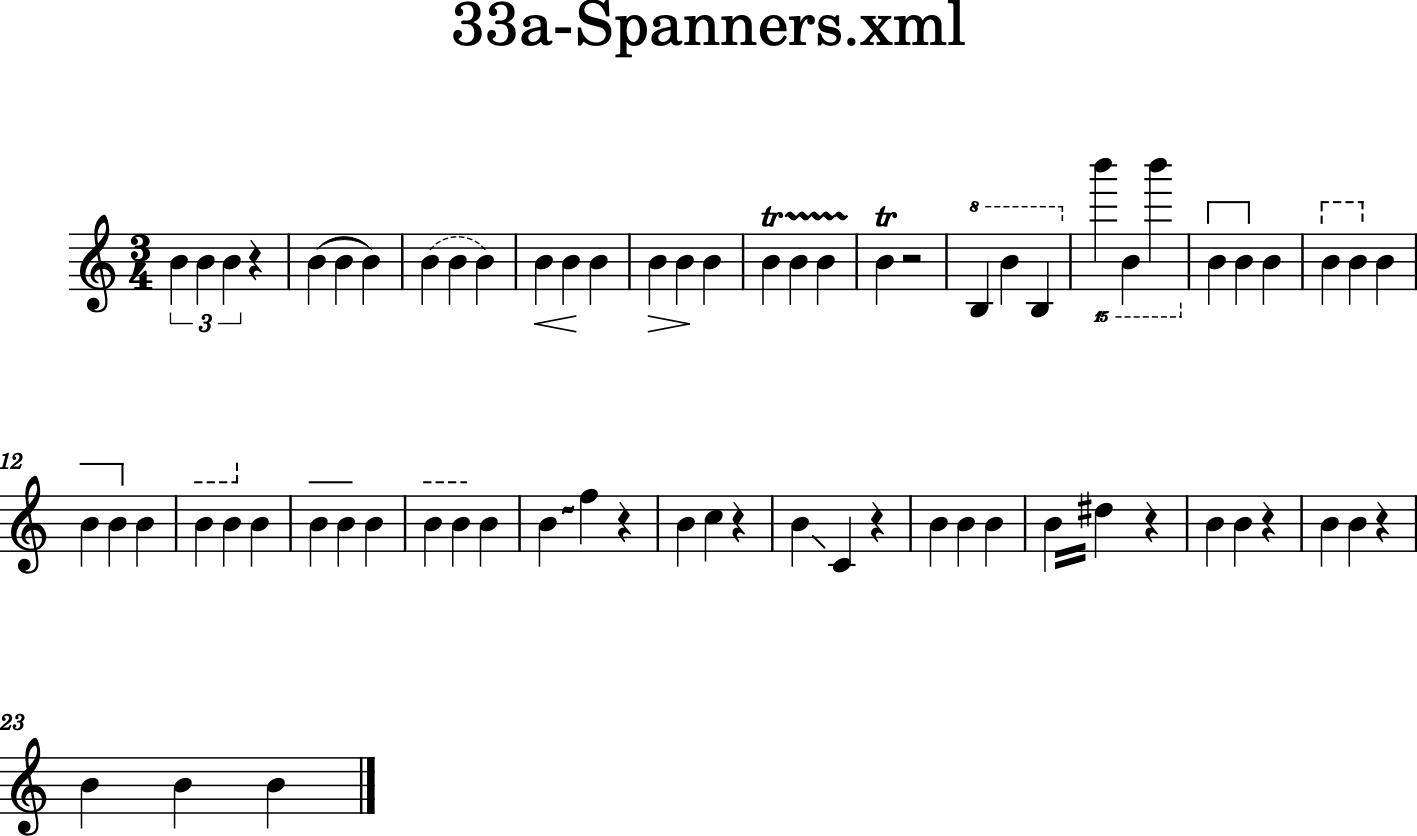

In [84]:
# block MuseScore: 
#    bend-alter, hammer, pull, ped change
# failing: dashed slur, octave shift mark, bend-alter, slide, 
#    grouping. hammer, pull, all ped.
s('33a')

33b-Spanners-Tie.xml

Two simple tied whole notes


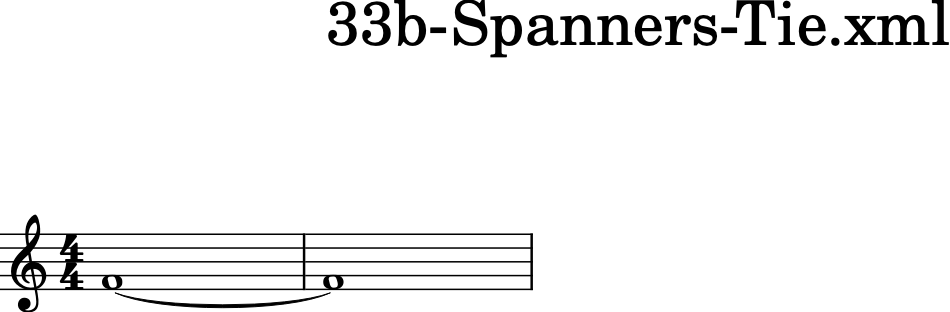

In [85]:
s('33b') # not necessarily a spanner except in Lilypond

33c-Spanners-Slurs.xml

A note can be the end of one slur and the start of a new slur. Also, in MusicXML, nested slurs are possible like in the second measure where one slur goes over all four notes, and another slur goes from the second to the third note.


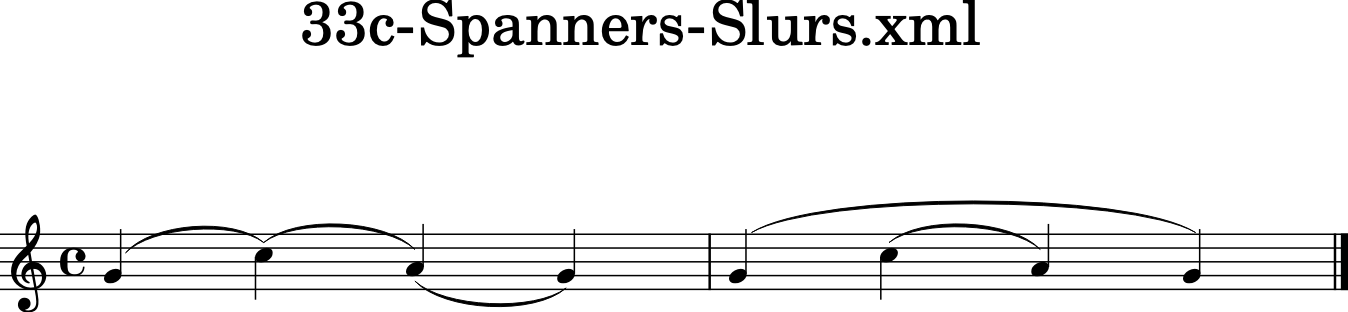

In [86]:
s('33c')

33d-Spanners-OctaveShifts.xml

All types of octave shifts (15ma, 15mb, 8va, 8vb)


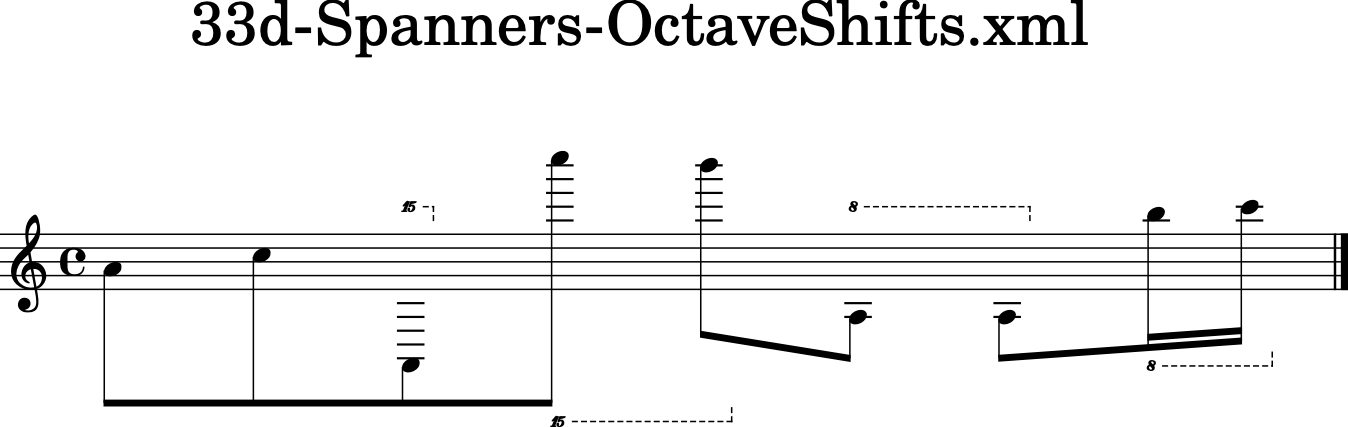

In [87]:
s('33d') # overinterpreting.

In [88]:
try:
    s('33e') # check if actually invalid
except spanner.SpannerException:
    print('Music21 v7.3 no longer writes ottava with invalid size')

33e-Spanners-OctaveShifts-InvalidSize.xml

Invalid octave-shifts: 27 down, 11 up.
Music21 v7.3 no longer writes ottava with invalid size


33f-Trill-EndingOnGraceNote.xml

A trill spanner that spans a grace note and ends on an after-grace note at the end of the measure.


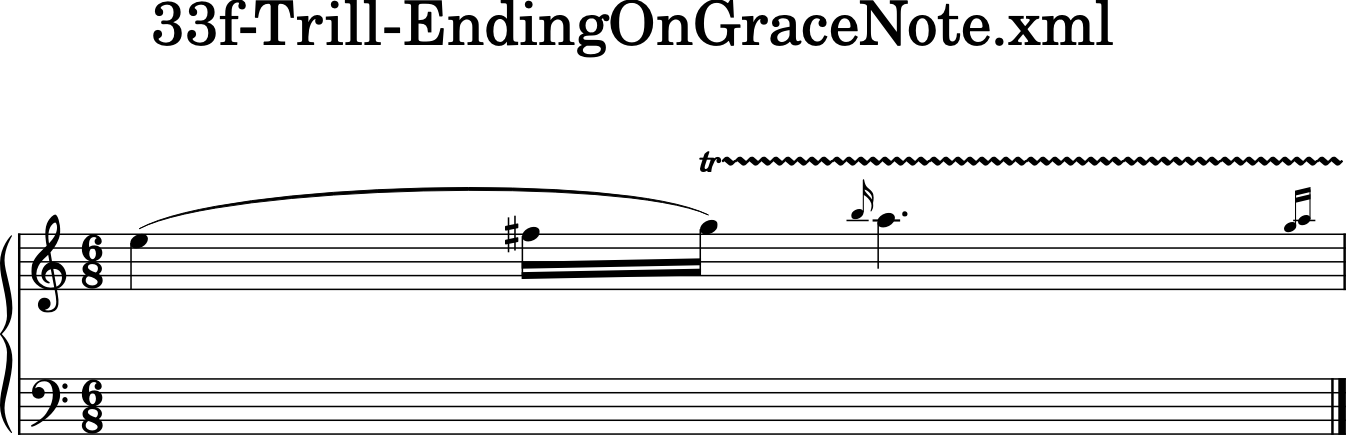

In [89]:
s('33f') # blocking: MuseScore

33g-Slur-ChordedNotes.xml

Slurs on chorded notes: Only the first note of the chord should get the slur notation. Some applications print out the slur for all notes -- these should be ignored. Edited by MSC to not reuse the same slur number in generating the overlapping slurs. 


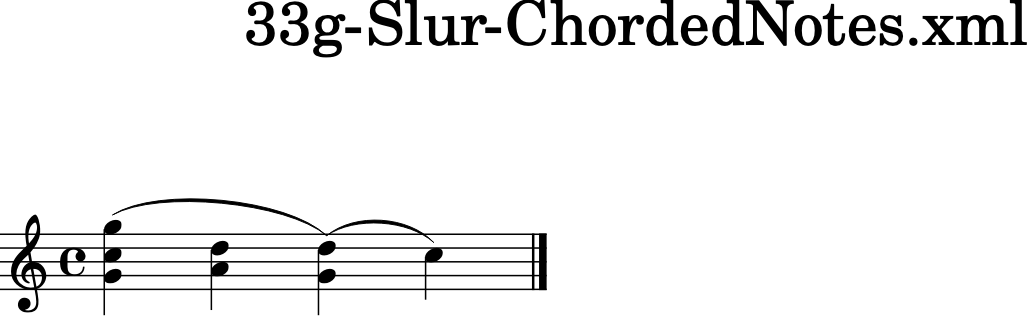

In [90]:
s('33g')

33h-Spanners-Glissando.xml

All different types of glissando defined in MusicXML


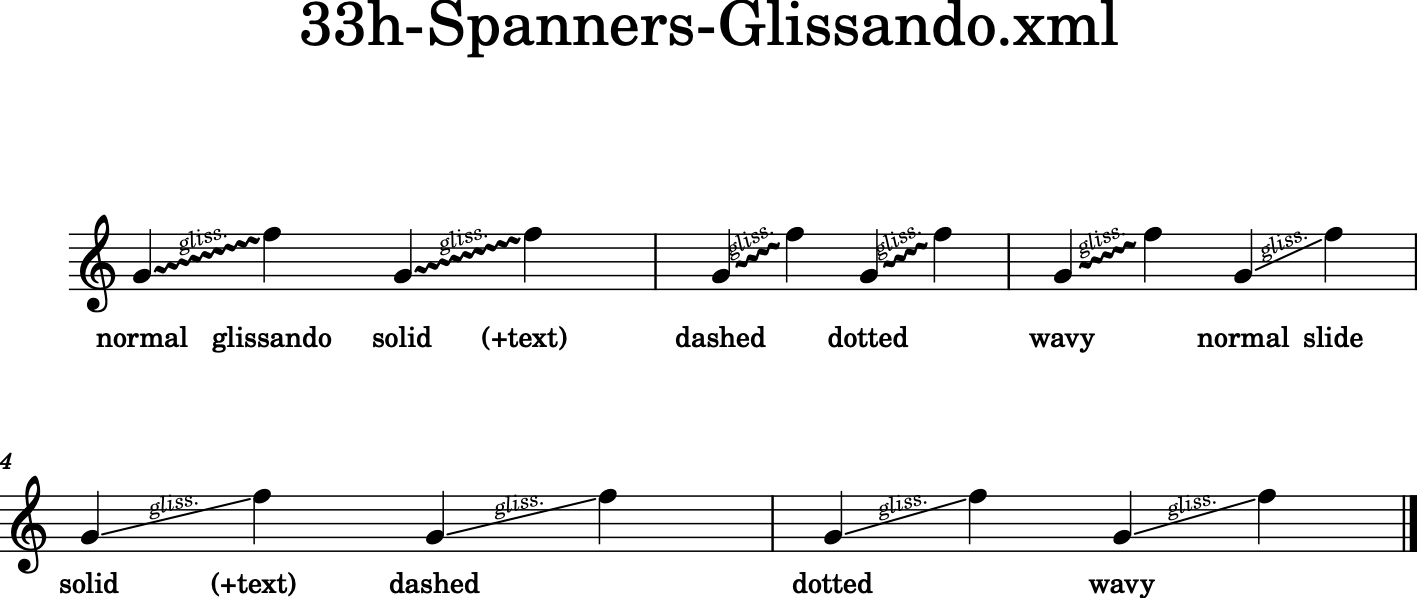

In [91]:
# failing except for normal/wavy glissando
# museScore blocking: solid, dashed, dotted for gliss, and 
#    dashed, dotted, wavy for slide.  Text works great!
s('33h')

33i-Ties-NotEnded.xml

Several ties that have their end tag missing.


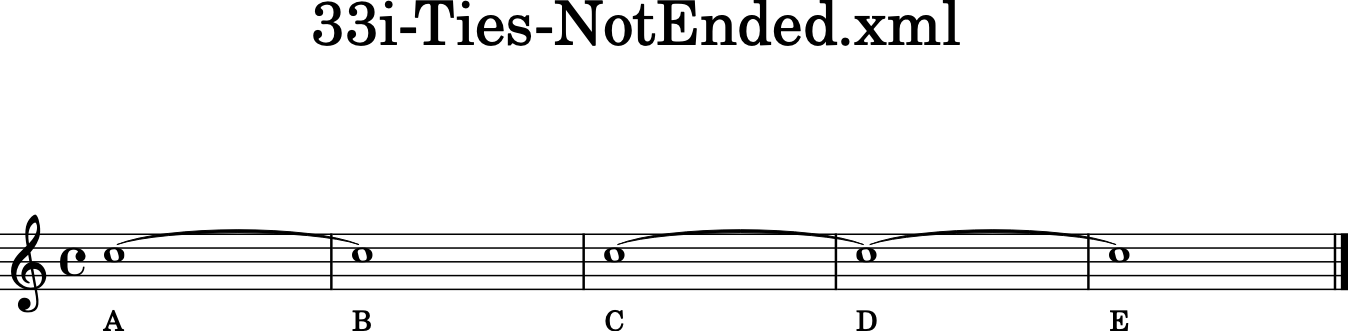

In [92]:
s('33i')

## 41 ... Multiple parts (staves)

41a-MultiParts-Partorder.xml

A piece with four parts (P0, P1, P2, P3; different from what Finale creates!). Are they converted in the correct order?


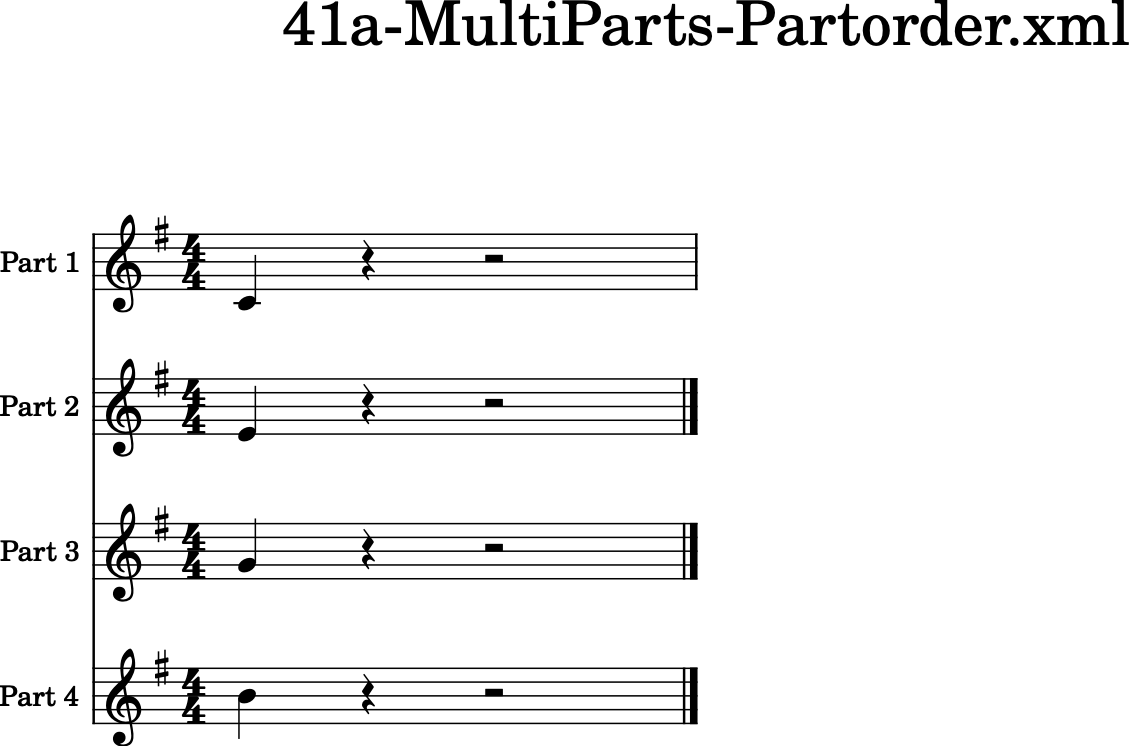

In [93]:
s('41a')

41b-MultiParts-MoreThan10.xml

A piece with 20 parts to check whether an application supports that many parts and whether they are correctly sorted.


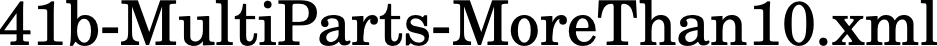

In [94]:
s('41b') # blocking: MuseScore? needs instruments?

41c-StaffGroups.xml

A huge orchestra score with 28 parts and different kinds of nested bracketed groups. Each part/group is assigned a name and an abbreviation to be shown before the staff. Also, most of the groups show unbroken barlines, while the barlines are broken between the groups.


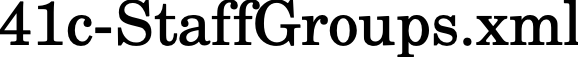

In [95]:
s('41c') # blocking since music21 only displays the first page in the notebook and the staves are on the next page.

41d-StaffGroups-Nested.xml

Two properly nested part groups: One group (with a square bracket) goes from staff 2 to 4) and another group (with a curly bracket) goes from staff 3 to 4.


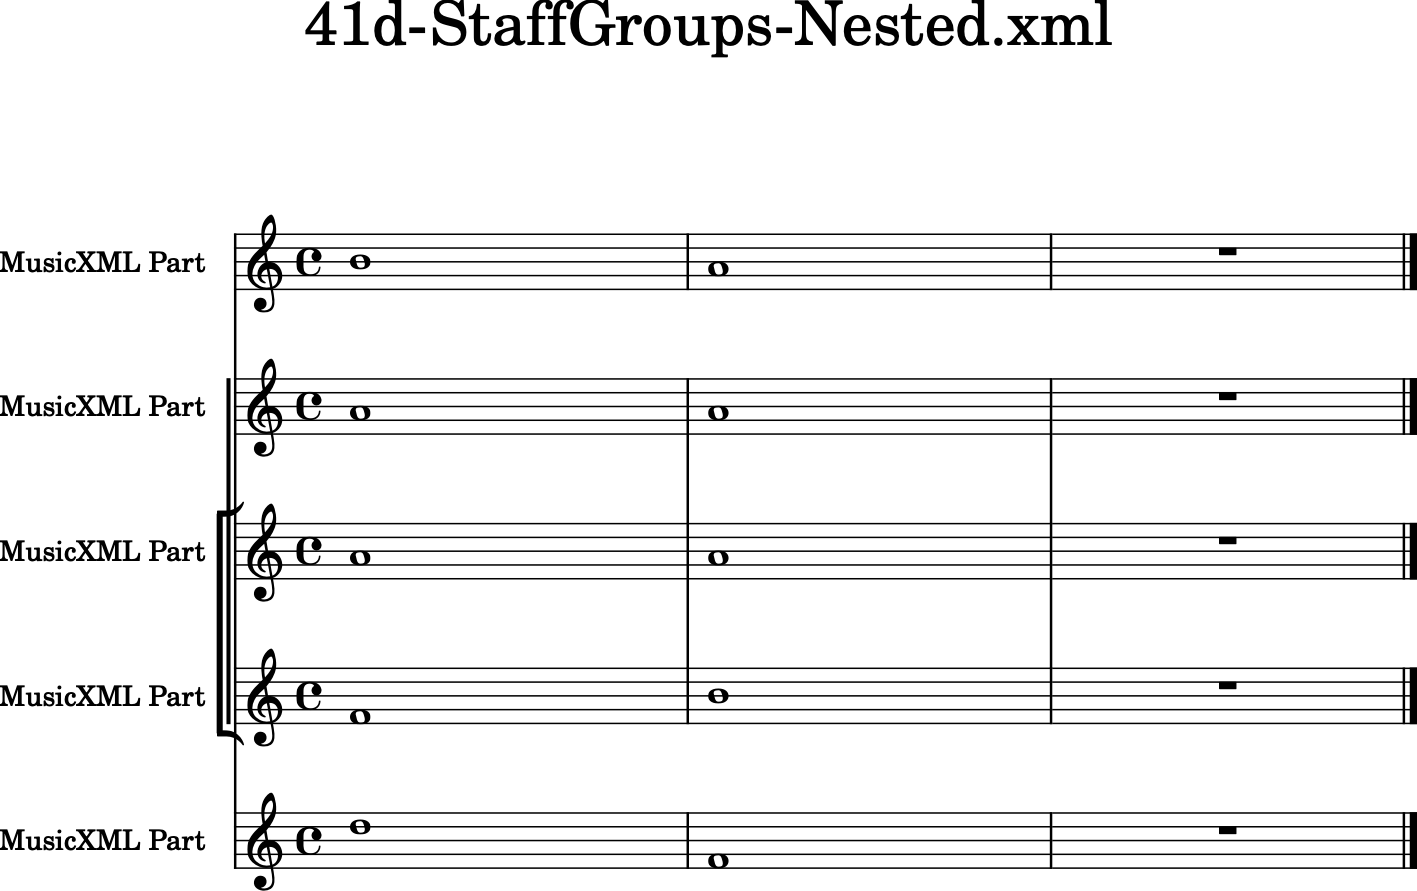

In [96]:
s('41d')

41e-StaffGroups-InstrumentNames-Linebroken.xml

Part names and abbreviations can contain line breaks.


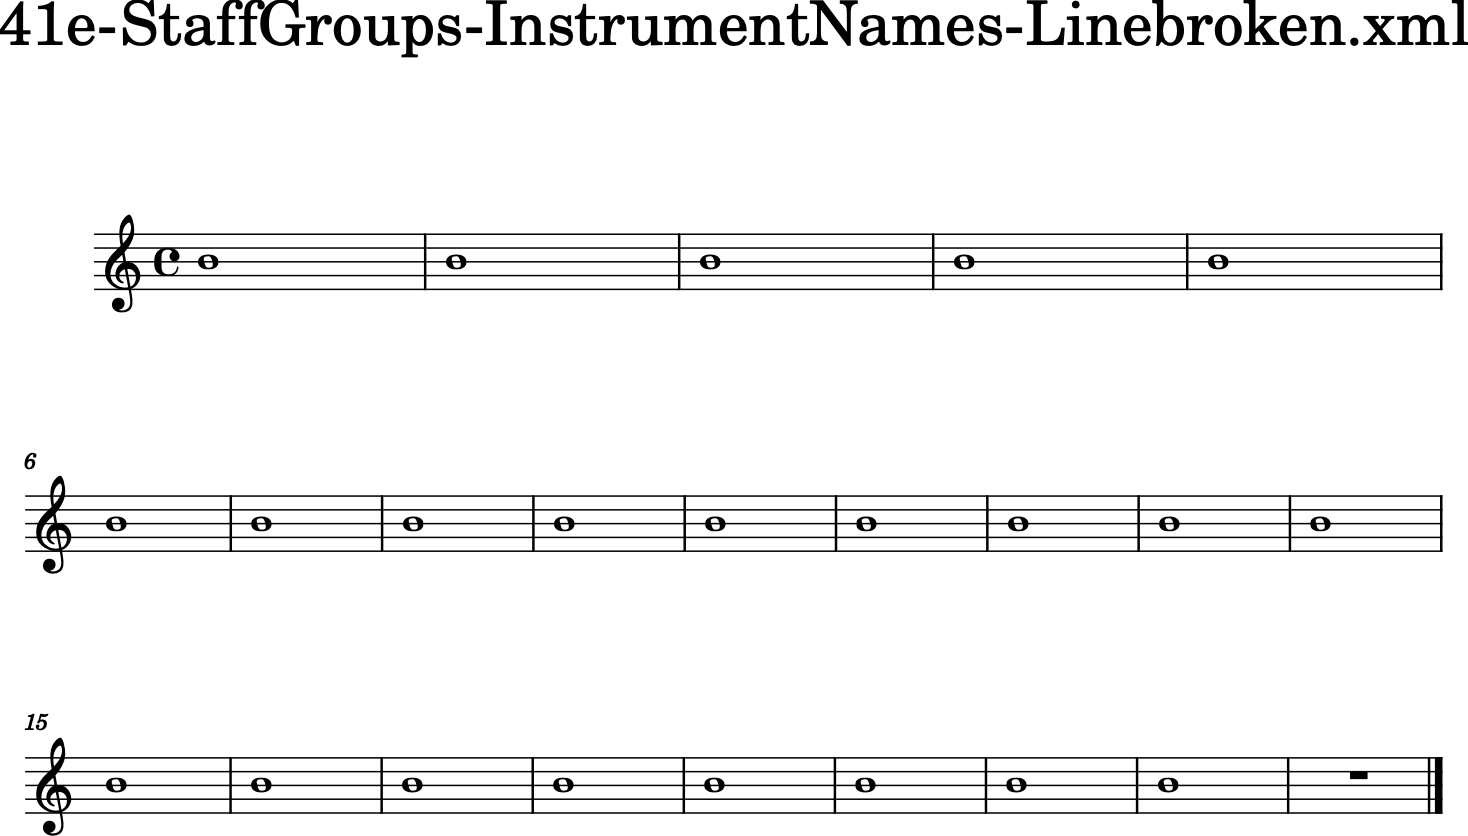

In [97]:
s('41e') # failing

41f-StaffGroups-Overlapping.xml

MusicXML allows for overlapping part-groups, while many applications do not allow overlapping groups, but require them to be properly nested. In this case, one group (with a square bracket) goes from staff 2 to 4) and another group (with a curly bracket) goes from staff 3 to 5.


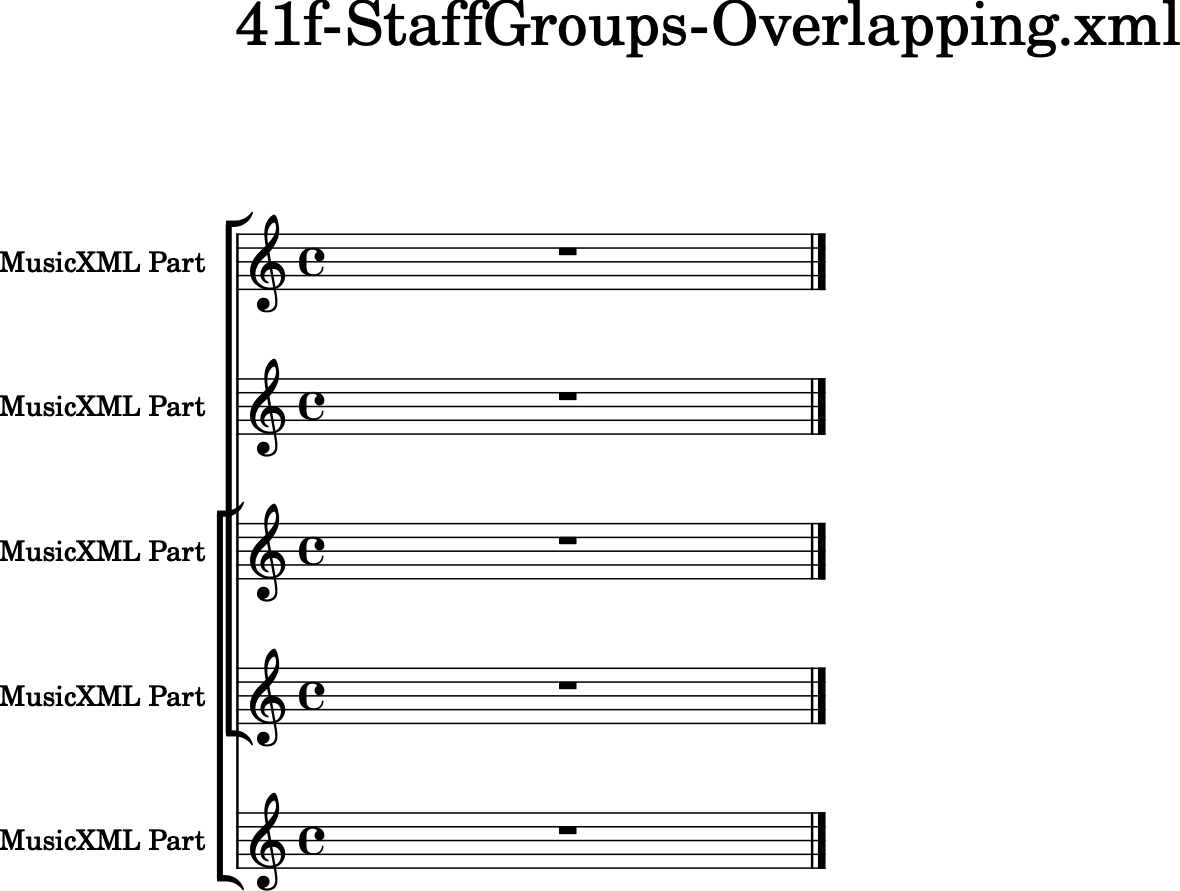

In [98]:
s('41f')

41g-PartNoId.xml

A part with no id attribute. Since this piece has only one part, it is clear which part is described by the one part element.


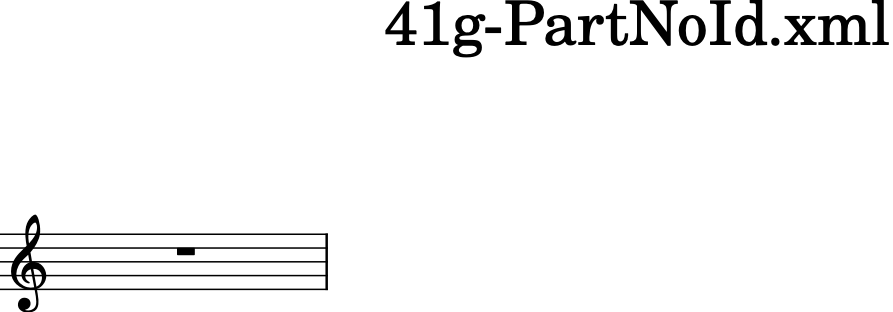

In [99]:
s('41g')

41h-TooManyParts.xml

This piece has more part elements than the part-list section gives. One can either convert all the parts present, but not listed in the part-list, or simply not import / ignore them.


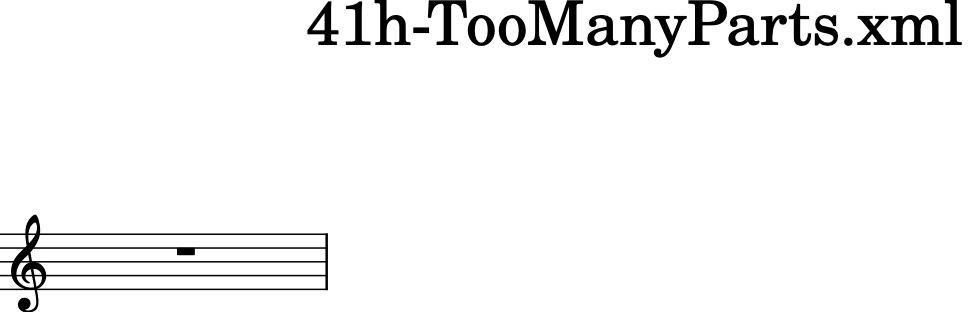

In [100]:
s('41h') # warns, skips the part -- acceptable behavior

41i-PartNameDisplay-Override.xml

MusicXML allows part-name and part-name-display in the score-part element. If part-name-display is given, it overrides the part-name for display. The first staff uses only part-name, while the second one (same part-name) overrides it with a custom text. Similar for the part-abbreviation used in subsequent staves. 


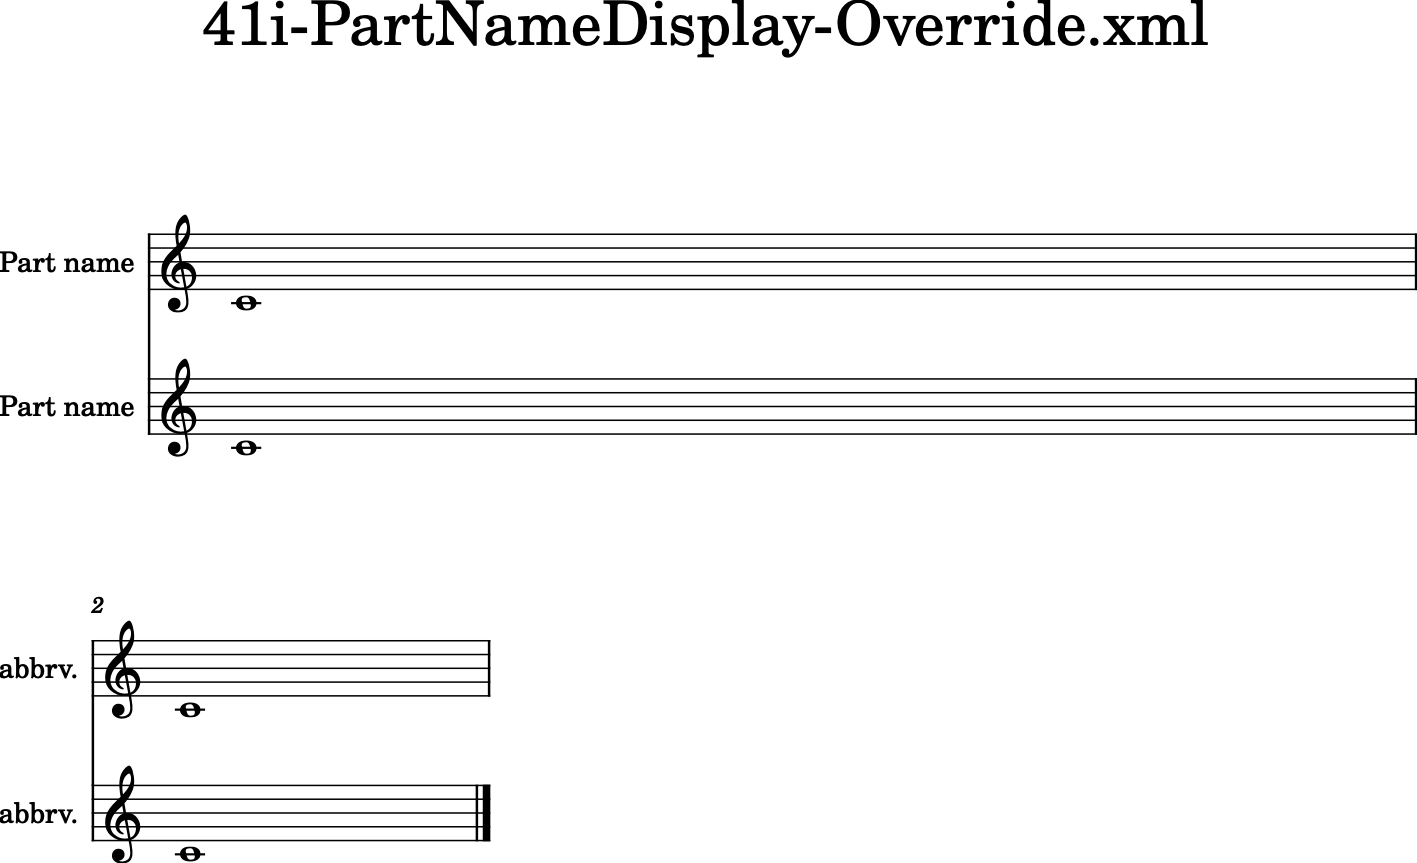

In [101]:
s('41i')

## 42 ... Multiple voices per staff

42a-MultiVoice-TwoVoicesOnStaff-Lyrics.xml

Two voices share one staff. Each voice is assigned some lyrics.


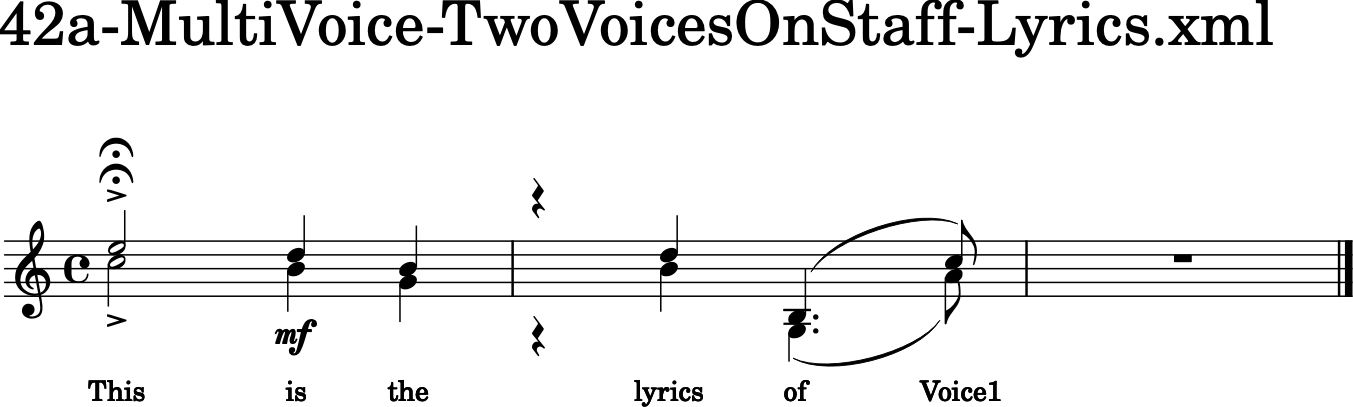

In [102]:
s('42a') # failing (works in musescore.)

42b-MultiVoice-MidMeasureClefChange.xml

A multi-voice / multi-staff part with a clef change in the middle of a measure and a <backward> for voice 2 jumping back beyond that clef change.


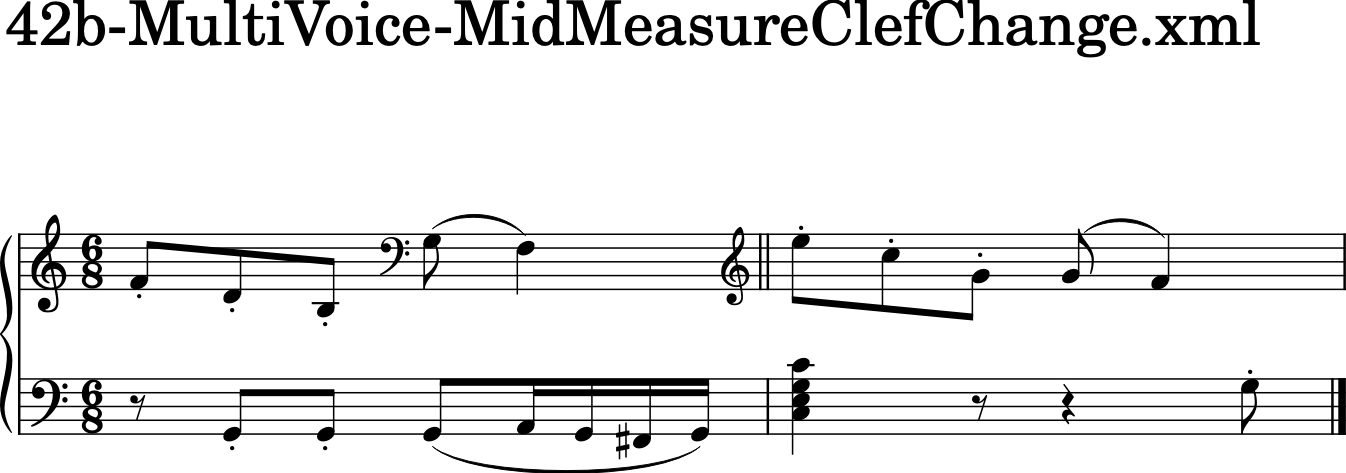

In [103]:
s('42b')

## 43 ... One part on multiple staves

43a-PianoStaff.xml

A simple piano staff


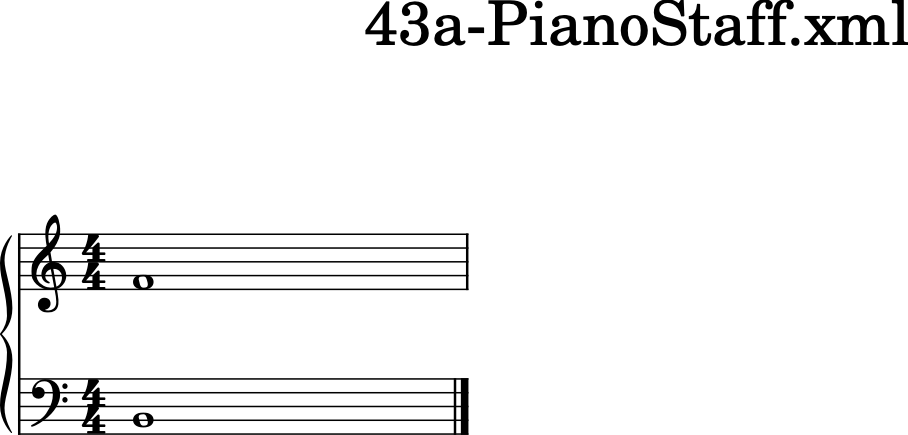

In [104]:
s('43a')

43b-MultiStaff-DifferentKeys.xml

A piano staff with different keys and clefs for each of its staves. The keys and clefs for both staves are given at the very beginning of the measure.


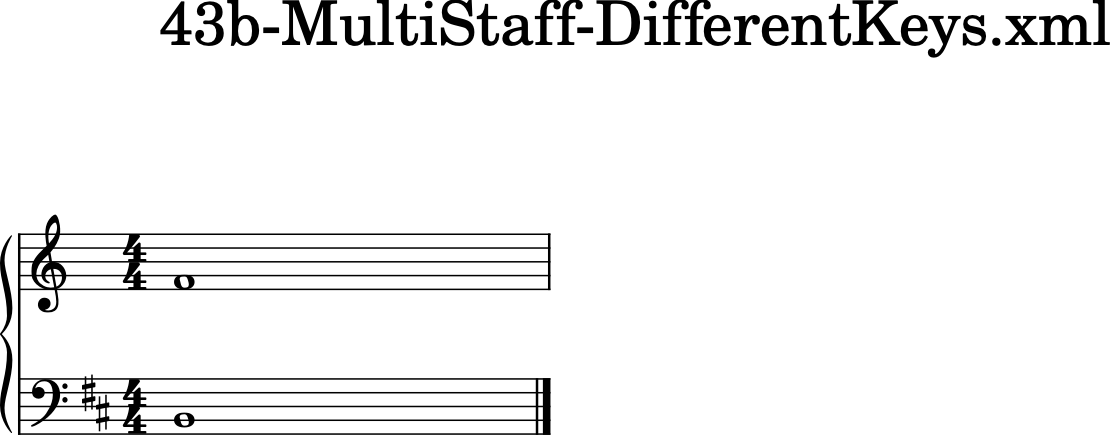

In [105]:
s('43b')

43c-MultiStaff-DifferentKeysAfterBackup.xml

A piano staff with different keys and clefs for each of its staves. The key and clef for the second staff is given only after a backward, just before the first note of the second staff is given, but after the whole measure for staff 1 has been given.


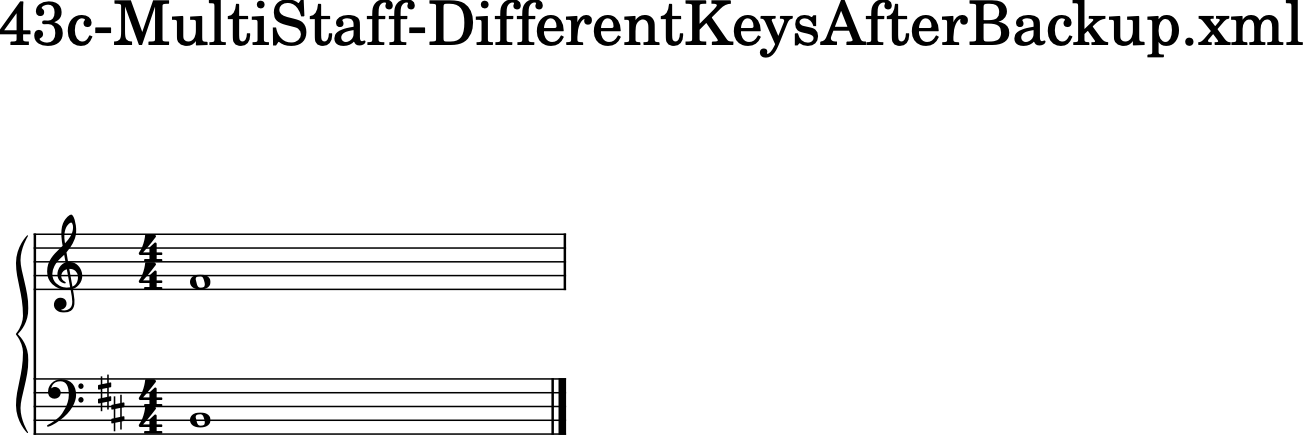

In [106]:
s('43c')

43d-MultiStaff-StaffChange.xml

Staff changes in a piano staff. The voice from the second staff has some notes/chords on the first staff. The final two chords have some notes on the first, some on the second staff.


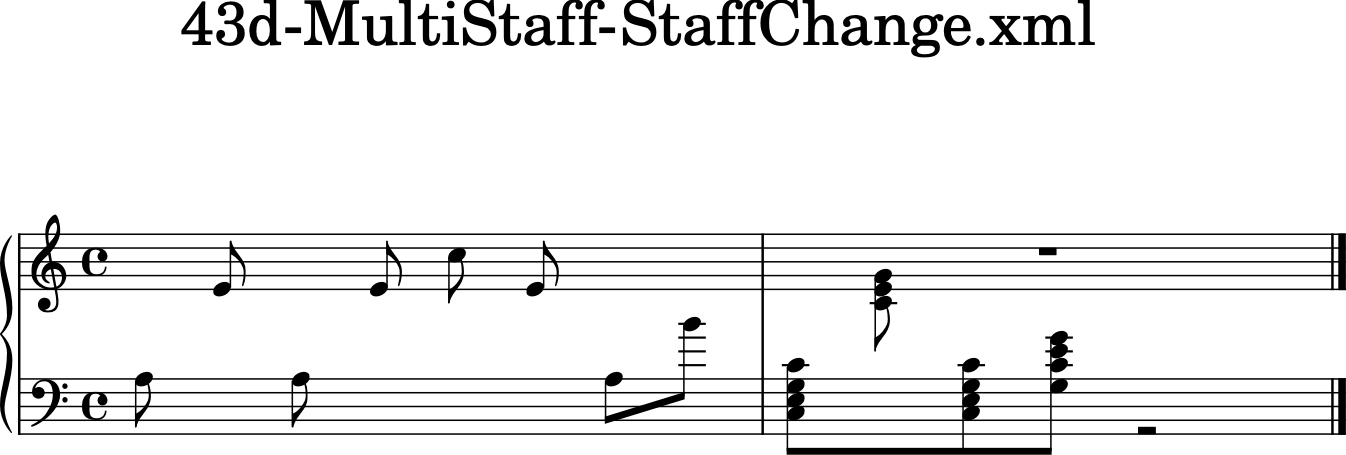

In [107]:
s('43d') # failing # cross-staff-beaming. fails utterly in m21 so far. 
# chord tones fail to cross on musescore; perfect on Finale.

43e-Multistaff-ClefDynamics.xml

A piano staff with dynamics and clef changes, where each element (ffff, wedge and clef changes) applies only to one voice or one staff, respectively.


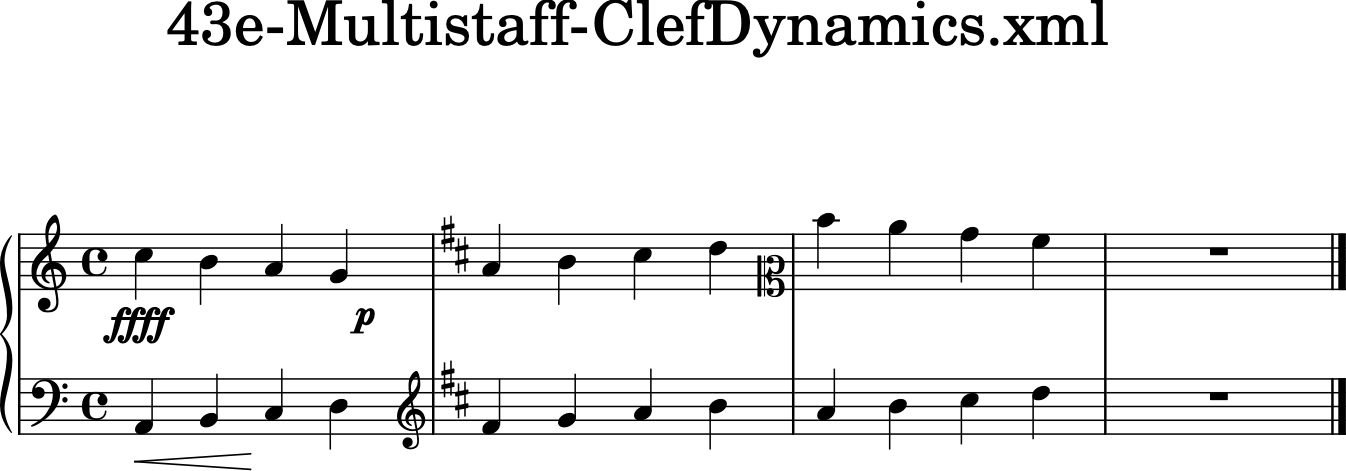

In [108]:
s('43e')

## 45 ... Repeats

45a-SimpleRepeat.xml

A simple, repeated measure (repeated 5 times)


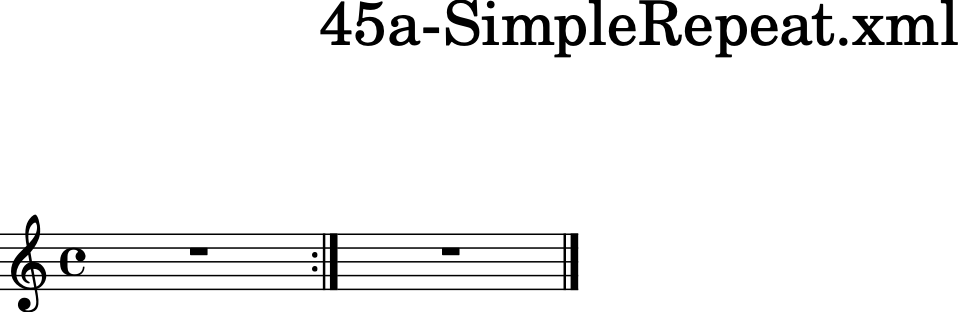

In [109]:
s('45a')

45b-RepeatWithAlternatives.xml

A simple repeat with two alternative endings (volta brackets).


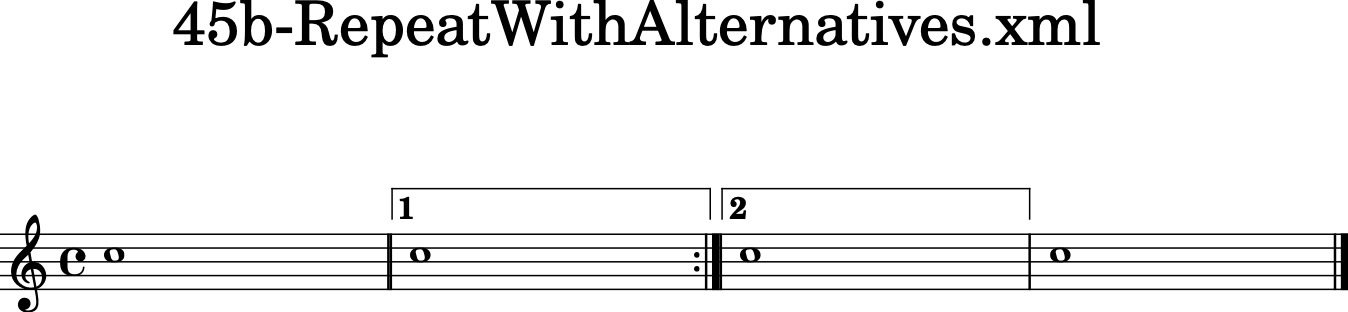

In [110]:
s('45b')

45c-RepeatMultipleTimes.xml

Repeats can also be nested.


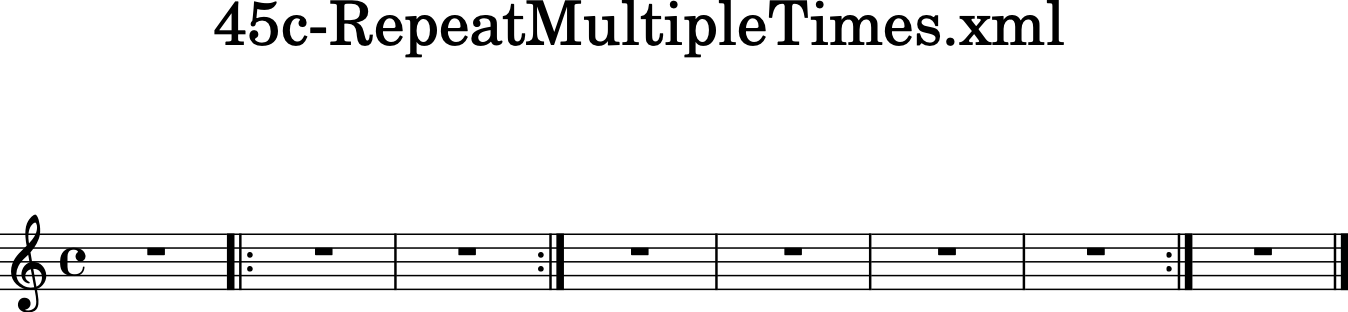

In [111]:
s('45c')

In [112]:
print(musicxmlOut['45c'])

<?xml version="1.0" encoding="utf-8"?>
<!DOCTYPE score-partwise  PUBLIC "-//Recordare//DTD MusicXML 3.1 Partwise//EN" "http://www.musicxml.org/dtds/partwise.dtd">
<score-partwise version="3.1">
  <work>
    <work-title>45c-RepeatMultipleTimes.xml</work-title>
  </work>
  <movement-title>45c-RepeatMultipleTimes.xml</movement-title>
  <identification>
    <creator type="composer">Music21</creator>
    <encoding>
      <encoding-date>2022-03-26</encoding-date>
      <software>music21 v.7.3.0</software>
    </encoding>
  </identification>
  <defaults>
    <scaling>
      <millimeters>7</millimeters>
      <tenths>40</tenths>
    </scaling>
  </defaults>
  <part-list>
    <score-part id="P1">
      <part-name>MusicXML Part</part-name>
    </score-part>
  </part-list>
  <!--=========================== Part 1 ===========================-->
  <part id="P1">
    <!--========================= Measure 1 ==========================-->
    <measure number="1">
      <attributes>
        <divisions>1

45d-Repeats-Nested-Alternatives.xml

Nested repeats, each with alternative endings.


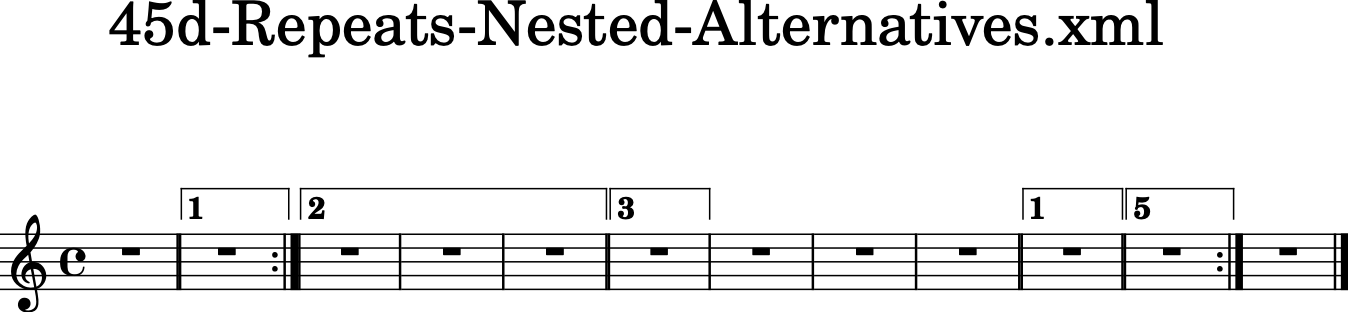

In [113]:
s('45d')

45e-Repeats-Nested-Alternatives.xml

Some more nested repeats with alternatives. The barline between measure 7 and 8 will probably be messed up! (Should be a repeat on both sides!)


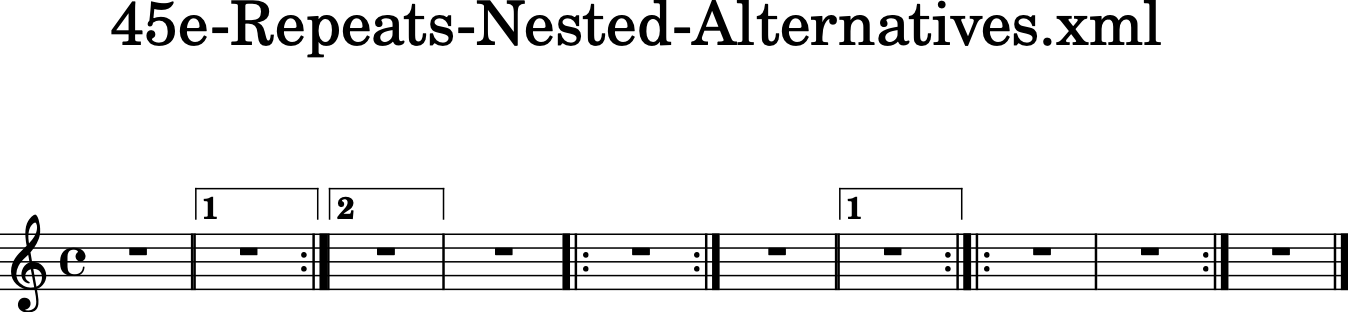

In [114]:
s('45e')

45f-Repeats-InvalidEndings.xml

Some more nested repeats with alternatives, where the MusicXML file does not make sense in the first place. How well are applications able to cope with improper repeats and alternatives?


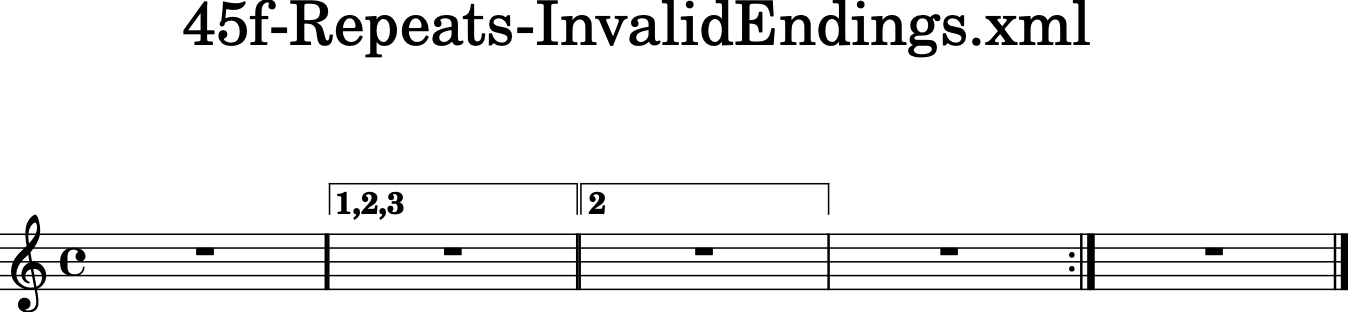

In [115]:
s('45f')

45g-Repeats-NotEnded.xml

A forward-repeating bar line without an ending repeat bar.


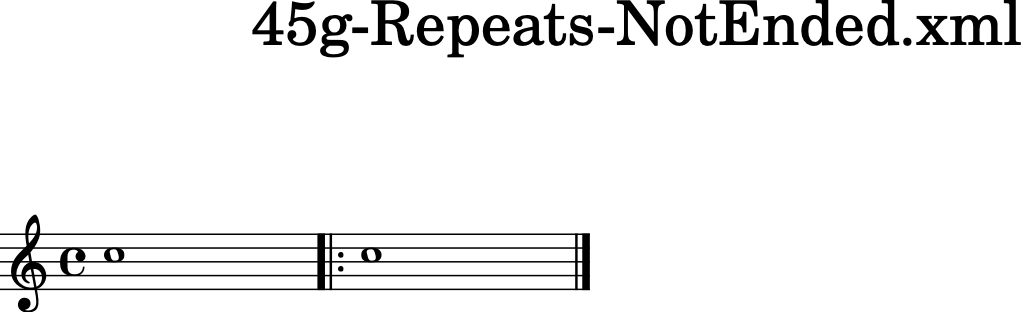

In [116]:
s('45g')

## 46 ... Barlines, Measures

46a-Barlines.xml

Different types of (non-repeat) barlines: default (no setting), regular, dotted, dashed, heavy, light-light, light-heavy, heavy-light, heavy-heavy, tick, short, none.


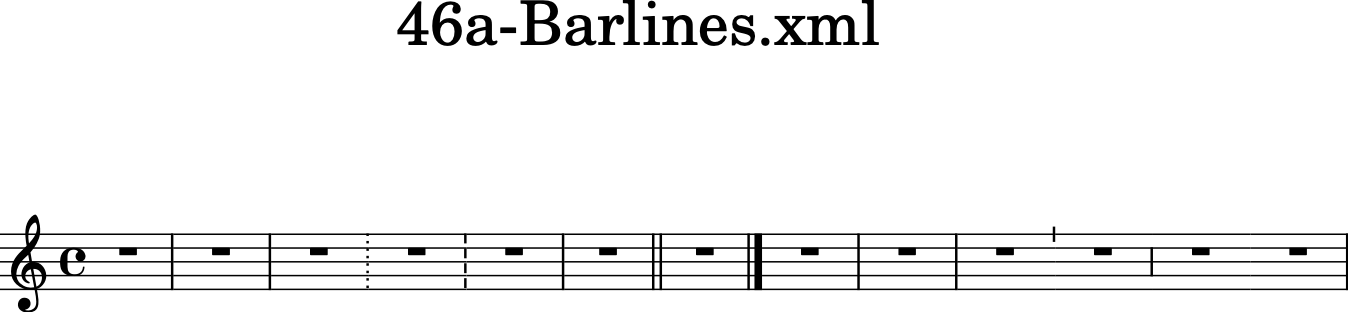

In [117]:
s('46a')

46b-MidmeasureBarline.xml

Barlines can appear at mid-measure positions, without using an implicit measure!


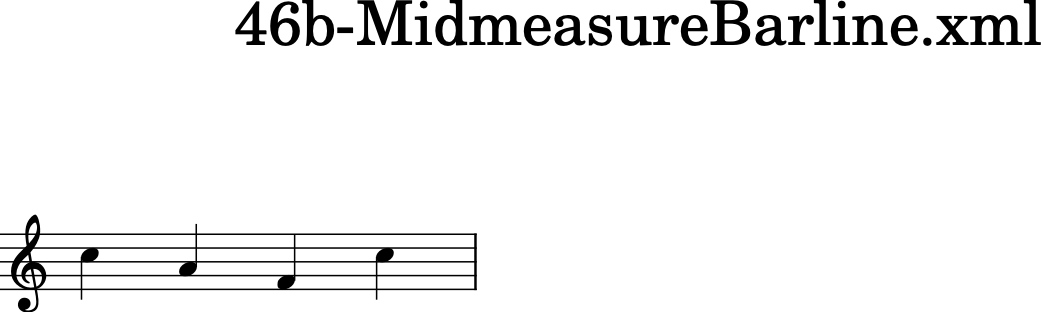

In [118]:
s('46b') # failing

46c-Midmeasure-Clef.xml

A clef change in the middle of a measure, using either an implicit measure or simply placing the attributes in the middle of the measure.


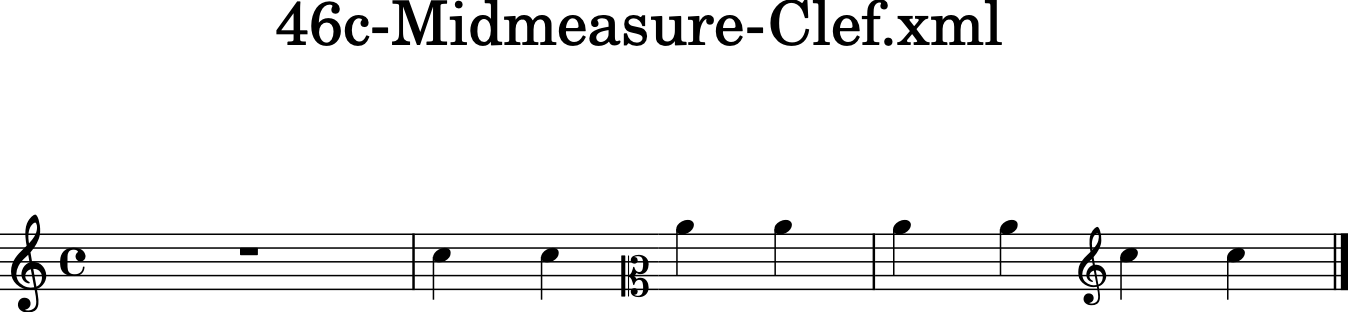

In [119]:
s('46c')

46d-PickupMeasure-ImplicitMeasures.xml

A 3/8 pickup measure, a measure that is split into one (incomplete, only 2/4) measure and an implicit measure, and an incomplete measure (containg 3/4).


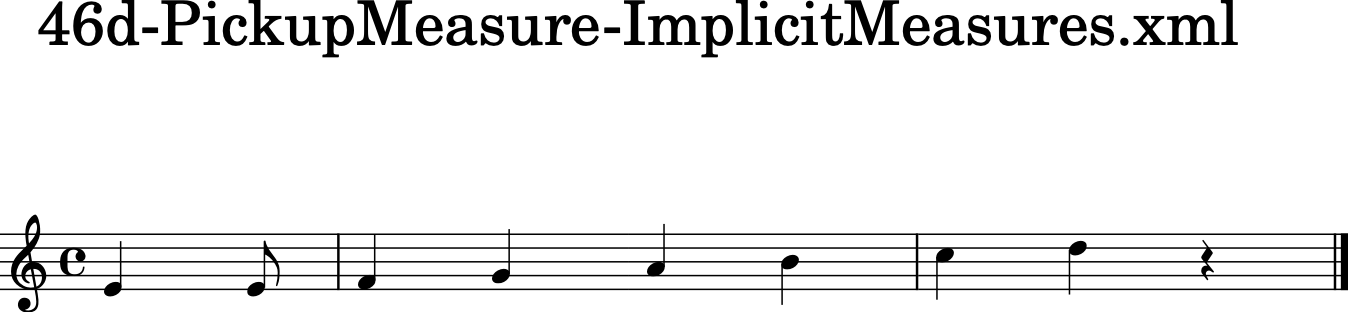

In [120]:
s('46d')

46e-PickupMeasure-SecondVoiceStartsLater.xml

Voice 2 should start at 2nd beat of first full measure.


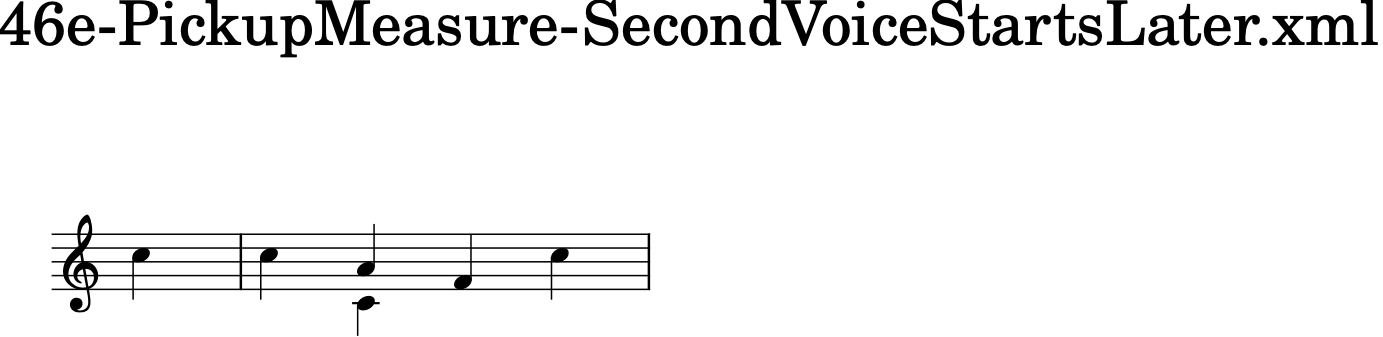

In [121]:
s('46e')

46f-IncompleteMeasures.xml

Measures can contain less notes than the time signature says. Here, the first and third measures contain only two quarters instead of four.


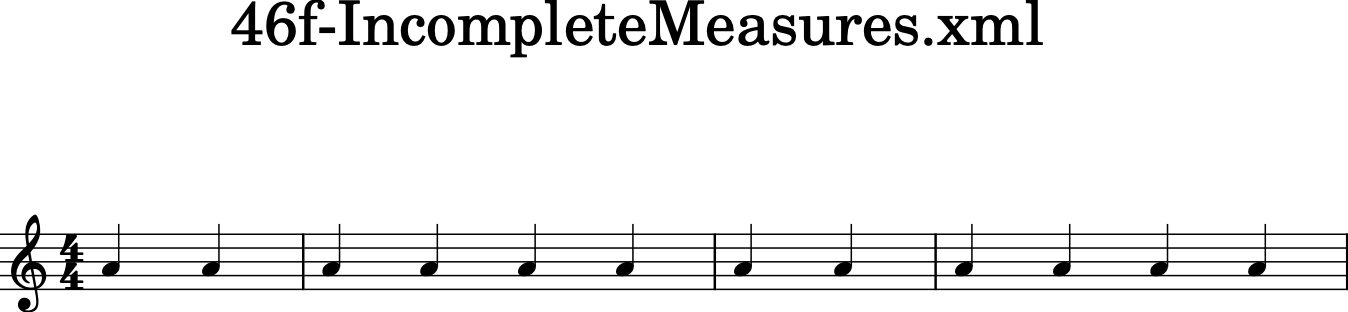

In [122]:
s('46f')

46g-PickupMeasure-Chordnames-FiguredBass.xml

Pickup measure with chord names and figured bass.


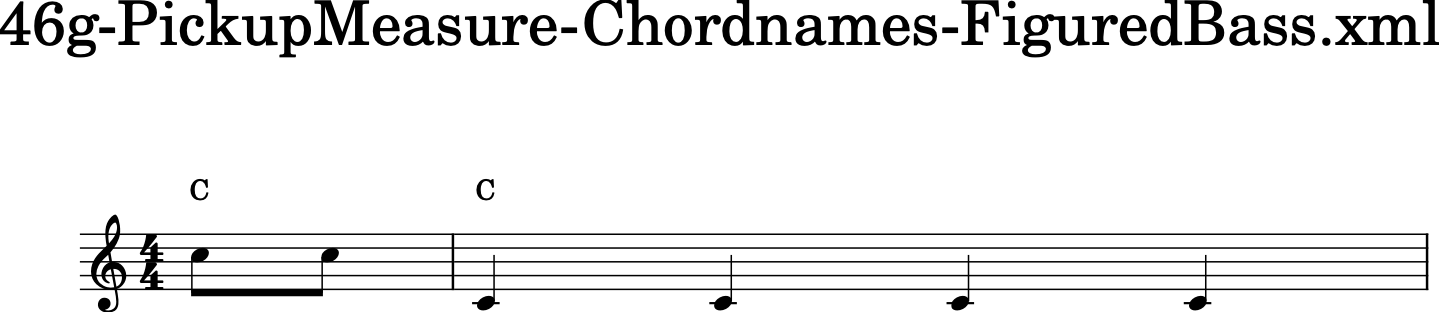

In [123]:
s('46g')  # failing somewhere on FiguredBass

## 51 ... Header information

51b-Header-Quotes.xml

Several header fields and part names can contain quotes ("). This test checks whether they are converted/imported without problems (i.e. whether they are correctly escaped when converting).


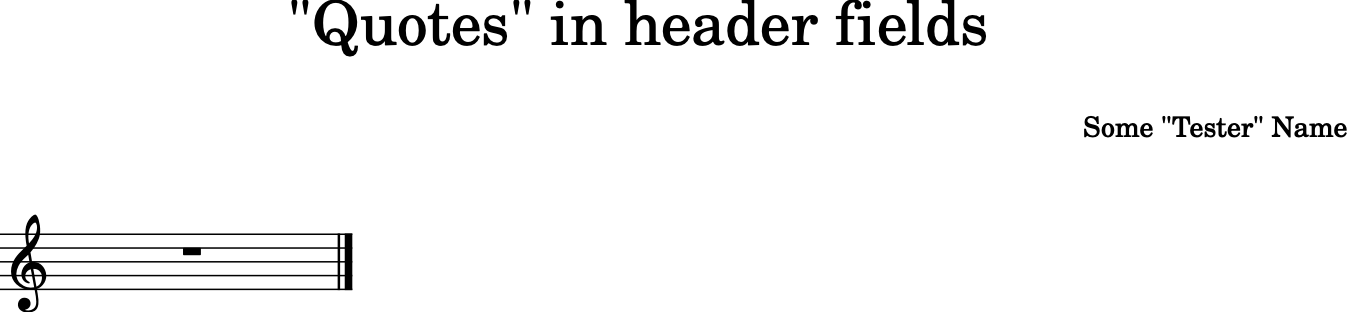

In [124]:
s('51b')

51c-MultipleRights.xml

There can be multiple <rights> tags in the identification element of the score. The conversion shall still work, ideally using both of them.


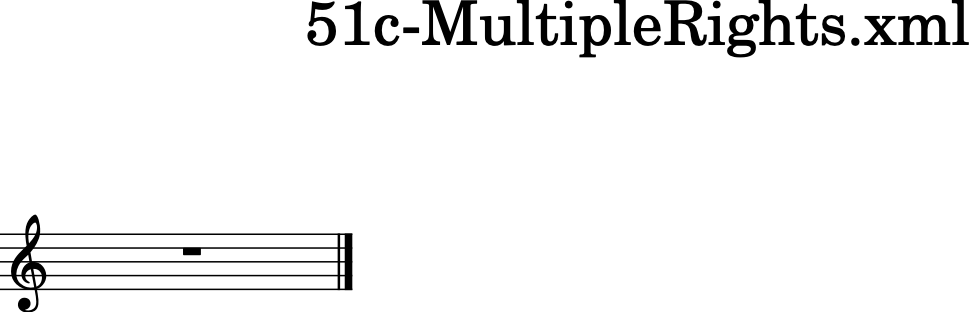

In [125]:
s('51c')

51d-EmptyTitle.xml

A piece with an empty (but existing) work-title, but a non-empty movement-title. In this case the movement-title should be chosen, even though the work-title exists.


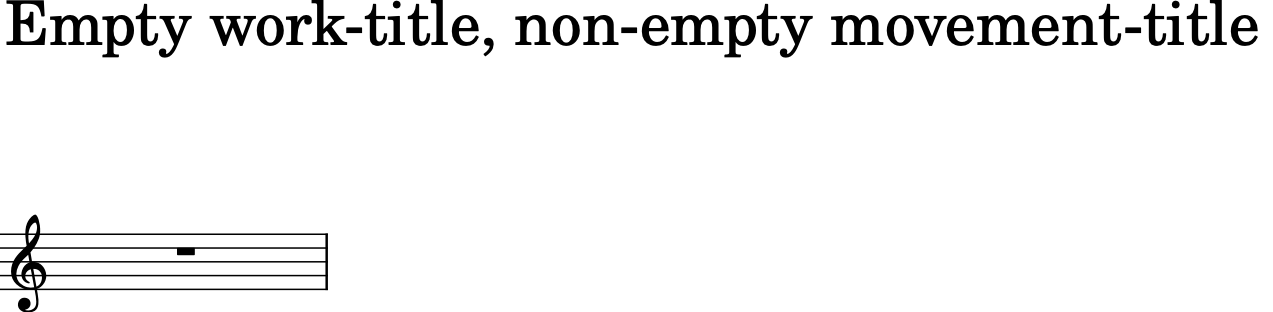

In [126]:
s('51d')

## 52 ... Page layout

52a-PageLayout.xml

Several page layout settings: paper size, margins, system margins and distances, different fonts, etc.


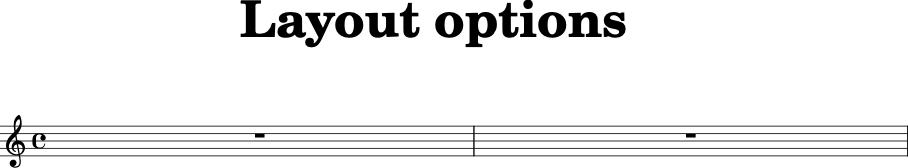

In [127]:
s('52a') # block: ipython21 -- only gives first png image.

52b-Breaks.xml

System and page breaks, given in a <print> element


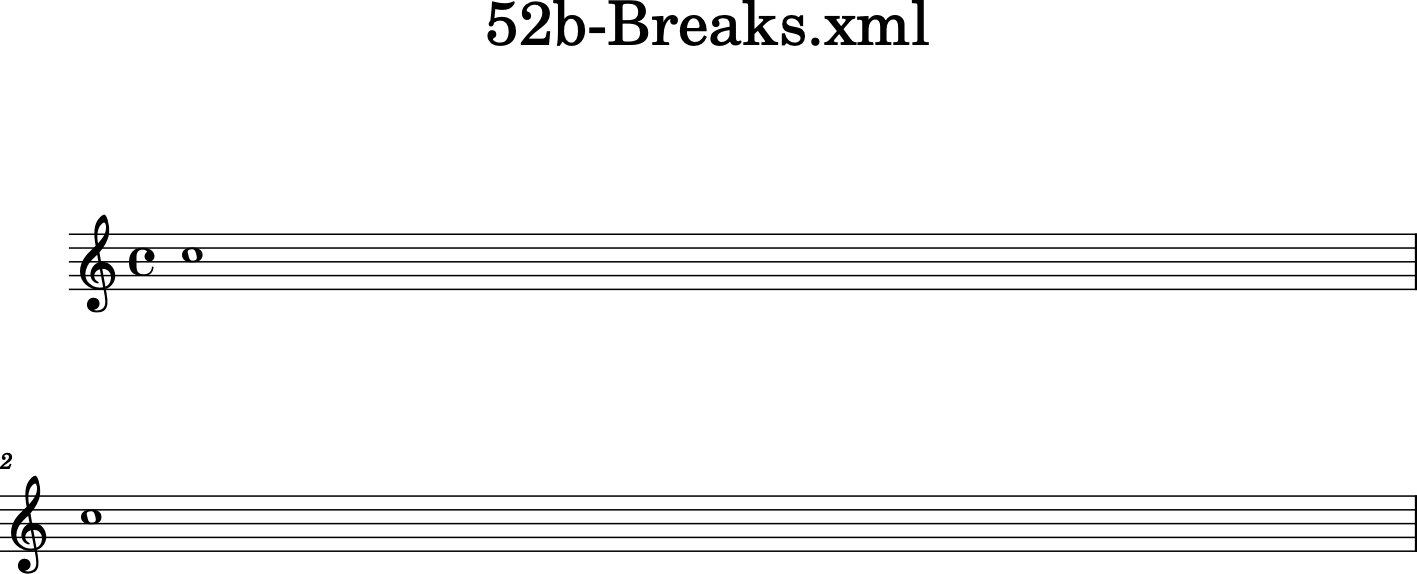

In [128]:
s('52b') # block: ipython21 -- only gives first png image.

## 61 ... Lyrics

61a-Lyrics.xml

Some notes with simple lyrics: Syllables, notes without a syllable, syllable spanners.


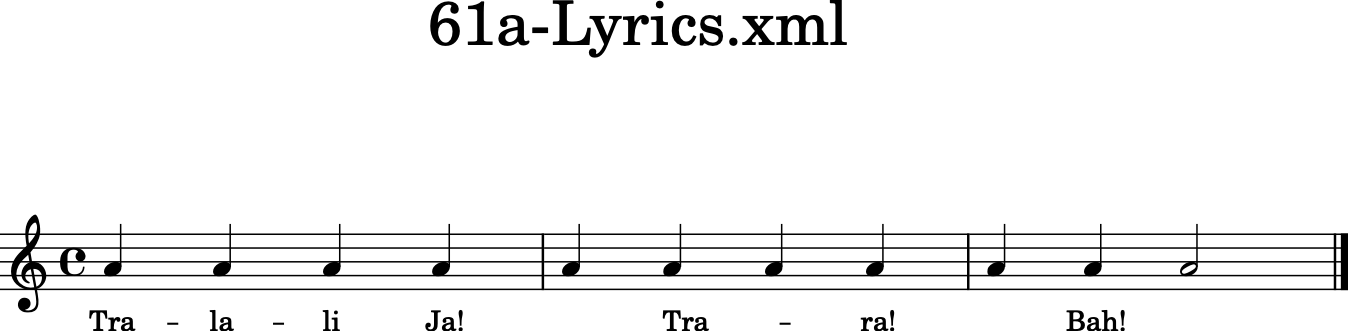

In [129]:
s('61a')

61b-MultipleLyrics.xml

Multiple (simple) lyrics. The order of the exported stanzas is relevant (identified by the number attribute in this test case)


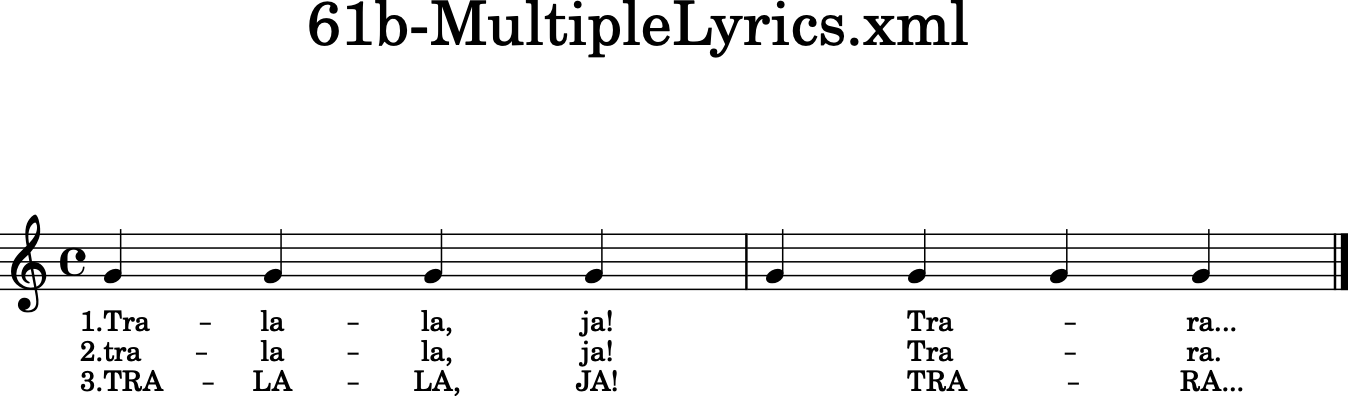

In [130]:
s('61b')

61c-Lyrics-Pianostaff.xml

Lyrics assigned to the voices of a piano staff containing two simple staves. Each staff is assigned exactly one lyrics line.


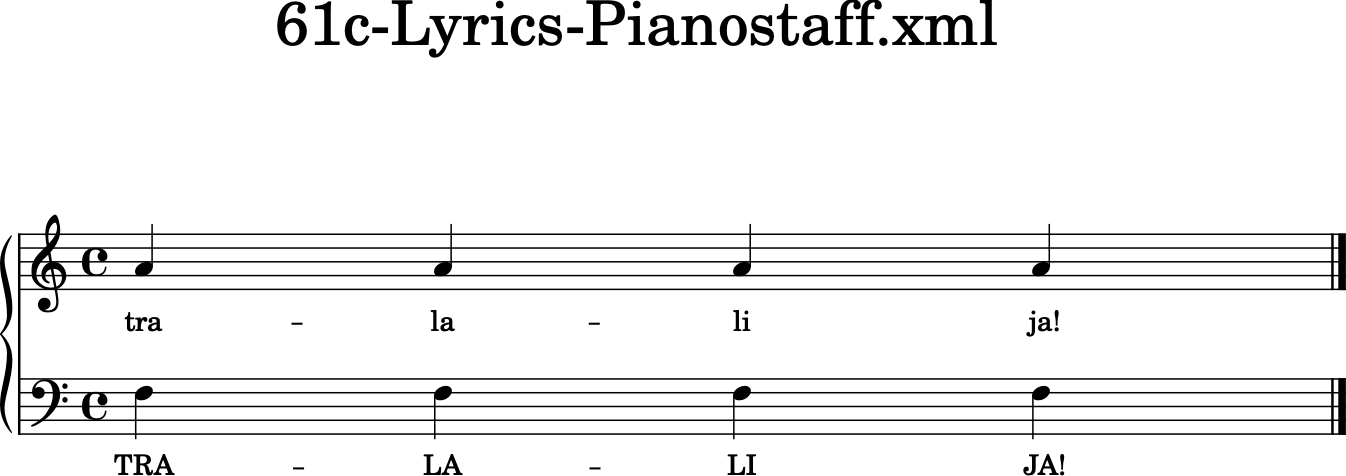

In [131]:
s('61c')

61d-Lyrics-Melisma.xml

How to treat lyrics and slurred notes. Normally, a slurred group of notes is assigned only one lyrics syllable.


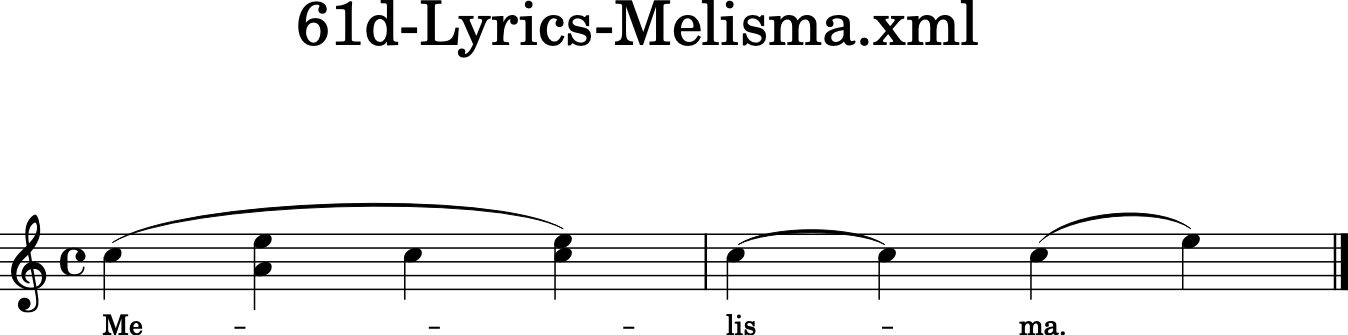

In [132]:
s('61d')

61e-Lyrics-Chords.xml

Assigning lyrics to chorded notes.


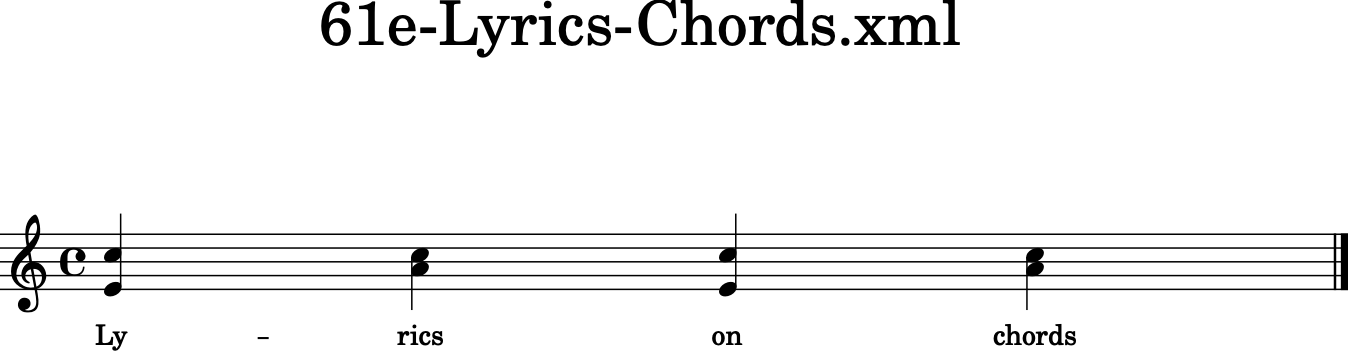

In [133]:
s('61e')

61f-Lyrics-GracedNotes.xml

Grace notes shall not mess up the lyrics, and they shall not be assigned a syllable.


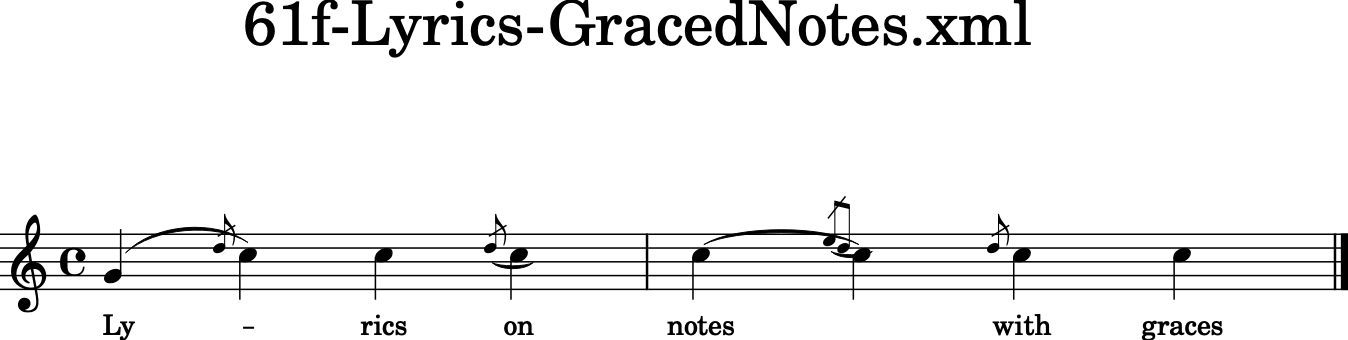

In [134]:
s('61f')

61g-Lyrics-NameNumber.xml

A lyrics syllable can have both a number and a name attribute. The question is: What should be used to put syllables of the same voice together. This example uses different number/name combinations to check how different applications handle this unspecified case (The advice on the MusicXML mailing list was "there is no correct way, each application can do what it thinks is best"). The complete text should be (by note number): 1: Verse1A, Chorus1A, AnotherChorus1A 2: 1B, 2B 3: Verse1C, Chorus2C 4: Chorus1D 5: VerseE 6: NoneF (indicating no number or name was given) 


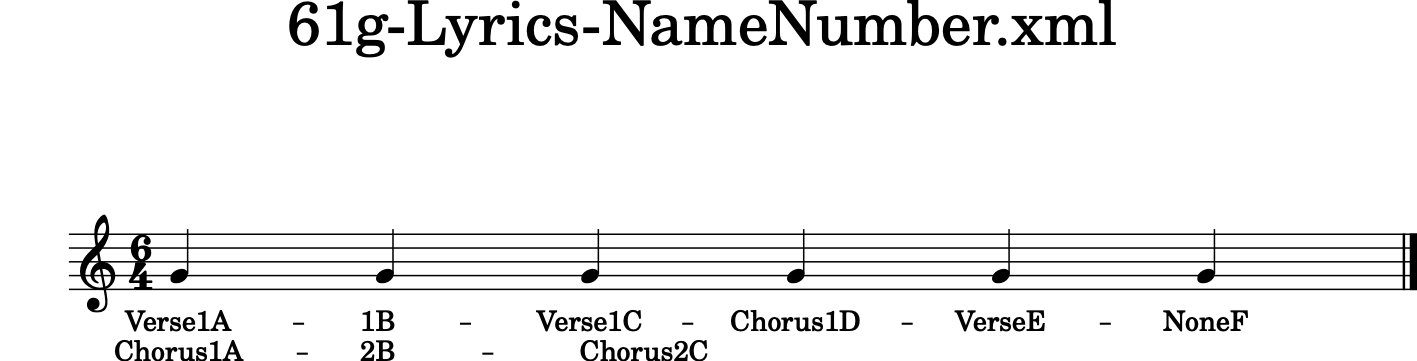

In [135]:
s('61g')

61h-Lyrics-BeamsMelismata.xml

Beaming or slurs can indicate melismata for lyrics. Also make sure that notes without an explicit syllable are treated as if they were part of a melisma.


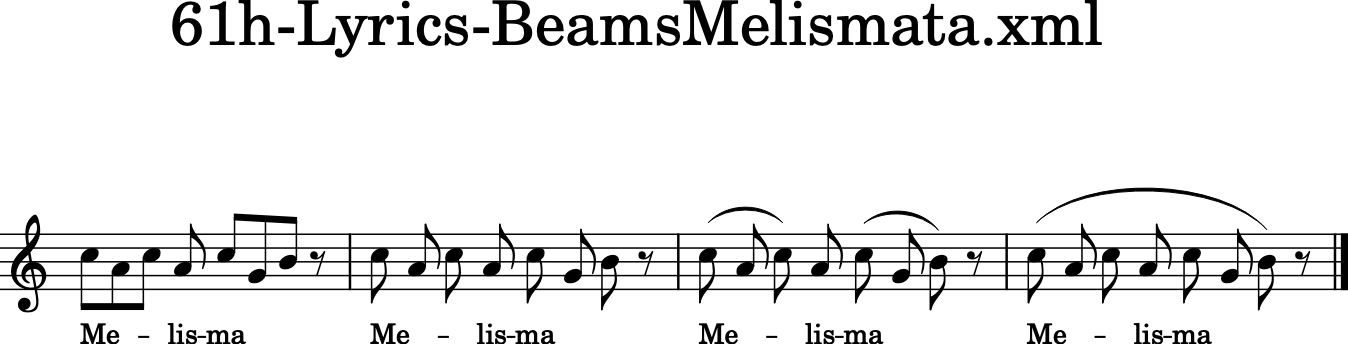

In [136]:
s('61h')

61i-Lyrics-Chords.xml

Each note of a chord can have some lyrics attached. In this case, each note of the chord has lyrics of the form "Lyrics [123]" attached, where each lyrics has a different number attribute to distinguish them. These syllables should be imported into three different stanzas and the timing should be correct.


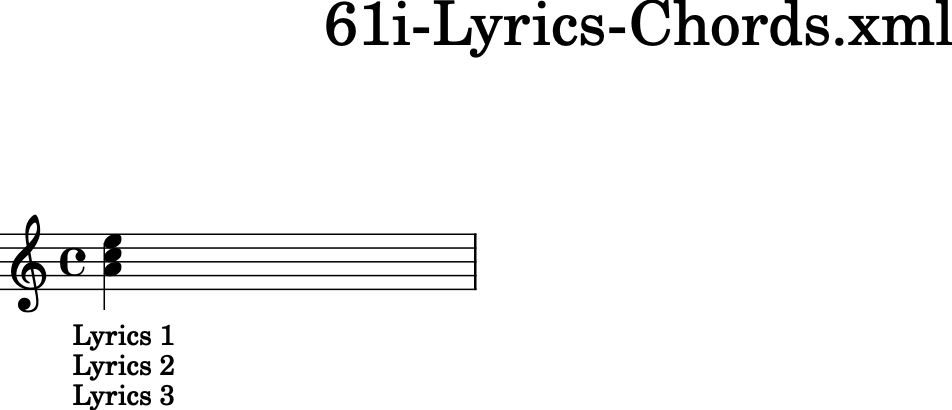

In [137]:
s('61i')

61j-Lyrics-Elisions.xml

Multiple lyrics syllables assigned to a single note are implemented either using a space in the lyrics or by using the <elision> lyrics element. This testcase checks both of them. First, a note with one syllable (a) is given, then a note with two syllables (b c) separated by a space and finally a note with two (de) and one with three syllables (fgh) implemented using <elision> is given.


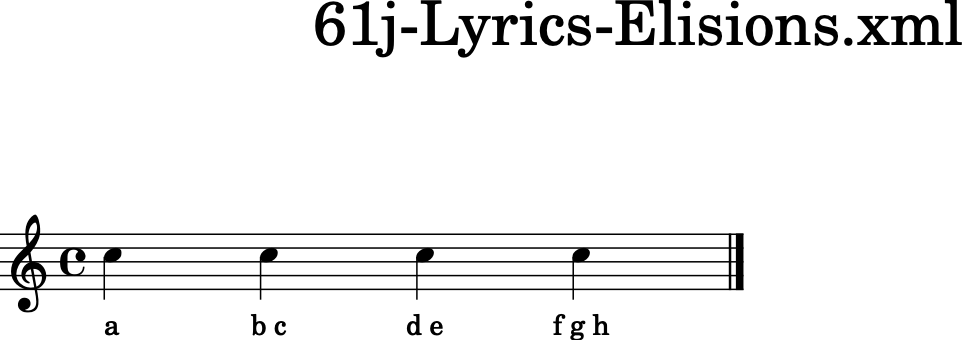

In [138]:
s('61j') # working since 6.7

In [139]:
for n in scores['61j'].recurse().notes:
    print(n.lyrics)

[<music21.note.Lyric number=1 text='a'>]
[<music21.note.Lyric number=1 text='b c'>]
[<music21.note.Lyric number=1 syllabic=composite text='d e'>]
[<music21.note.Lyric number=1 syllabic=composite text='f g h'>]


61k-Lyrics-SpannersExtenders.xml

Lyrics spanners: continued syllables and extenders, possibly spanning multiple notes. The intermediate notes do not have any <lyric> element. Text should read: "A long-er text" 


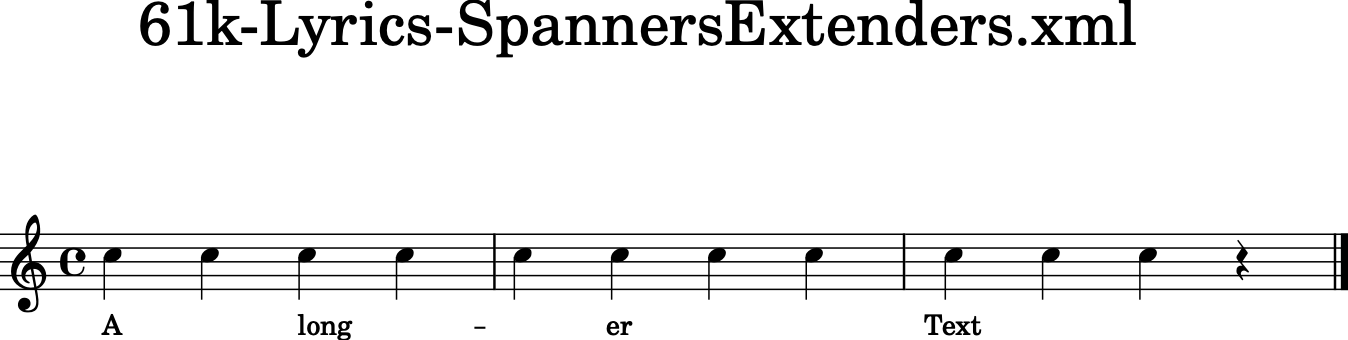

In [140]:
s('61k') # failing on extenders on b, and CC.

61l-Lyrics-Elisions-Syllables.xml

This is a similar test to 61j but the syllables in the lyrics have <syllabic> information in addition to <elision>. Note one is a standard lyric (begin). Note 2 has an elision this time, but same syllabic (middle) Note 3 has two syllables with different syllabic tags (middle, end) Note 4 has three syllables with begin, middle, end. 


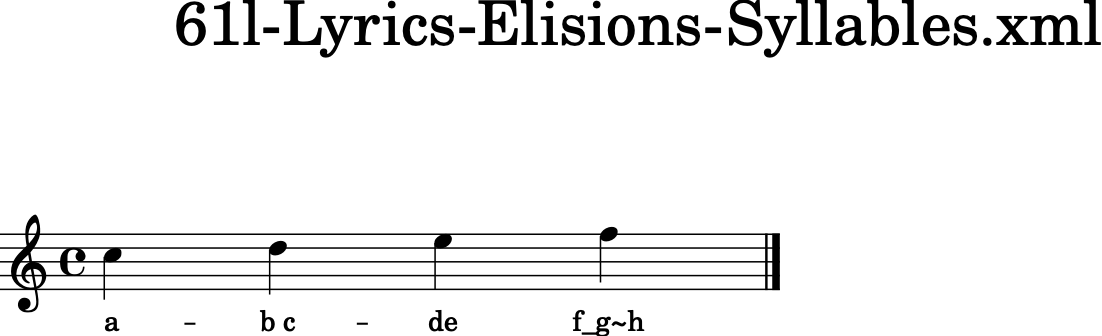

In [141]:
s('61l')  # working since 6.7

In [142]:
for n in scores['61l'].recurse().notes:
    print(n.lyrics)

[<music21.note.Lyric number=1 syllabic=begin text='a'>]
[<music21.note.Lyric number=1 syllabic=composite text='b c'>]
[<music21.note.Lyric number=1 syllabic=composite text='de'>]
[<music21.note.Lyric number=1 syllabic=composite text='f_g~h'>]


## 71 ... Guitar notation

71a-Chordnames.xml

A normal staff with several (complex) chord names displayed.


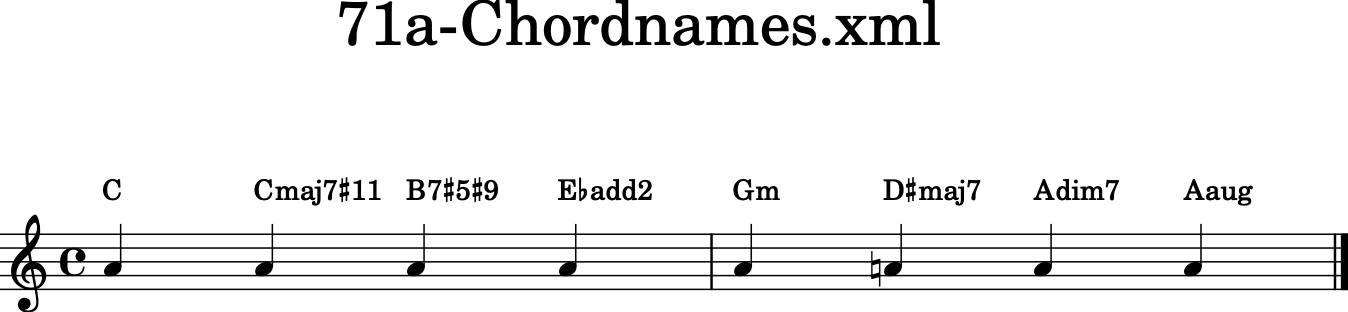

In [143]:
s('71a')

71c-ChordsFrets.xml

A staff with chord names and some fretboards shown. The fretboards can have an arbitrary number of frets/strings, can start at an arbitrary fret and can even contain fingering information.


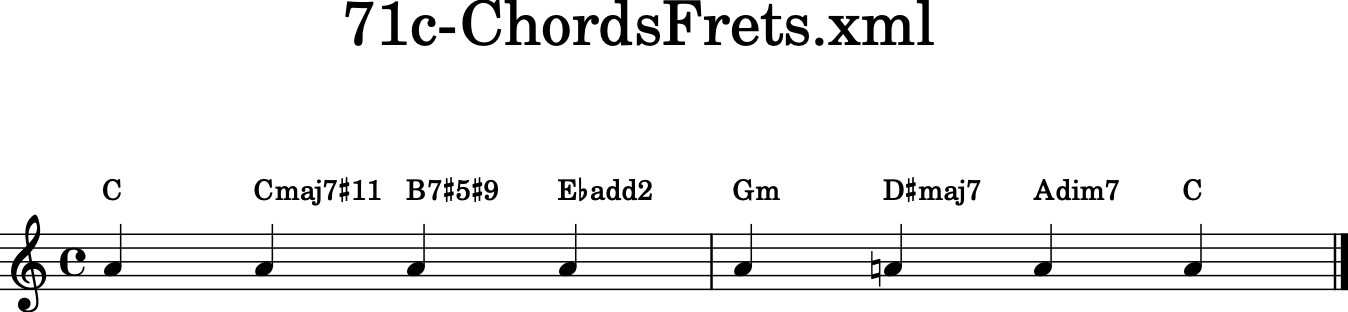

In [144]:
s('71c') # not yet supported on input; output is fine.

71d-ChordsFrets-Multistaff.xml

Chords and fretboards assigned to the voices in a multi-voice, multi-staff part. There should be fret diagrams above each of the two staves.


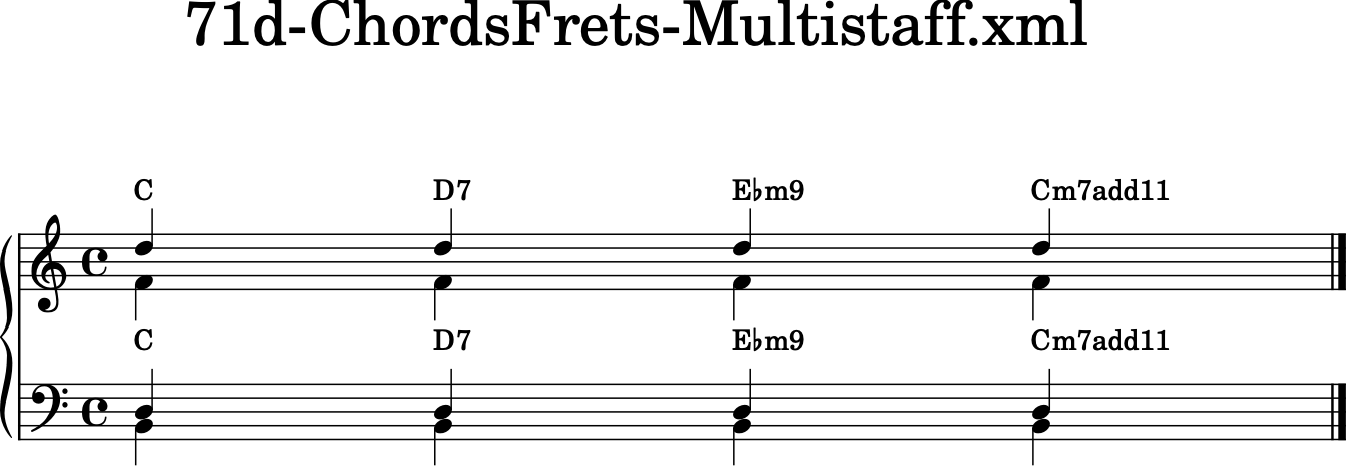

In [145]:
s('71d') # not yet supported

71e-TabStaves.xml

Some tablature staves, with explicit fingering information and different string tunings given in the MusicXML file.


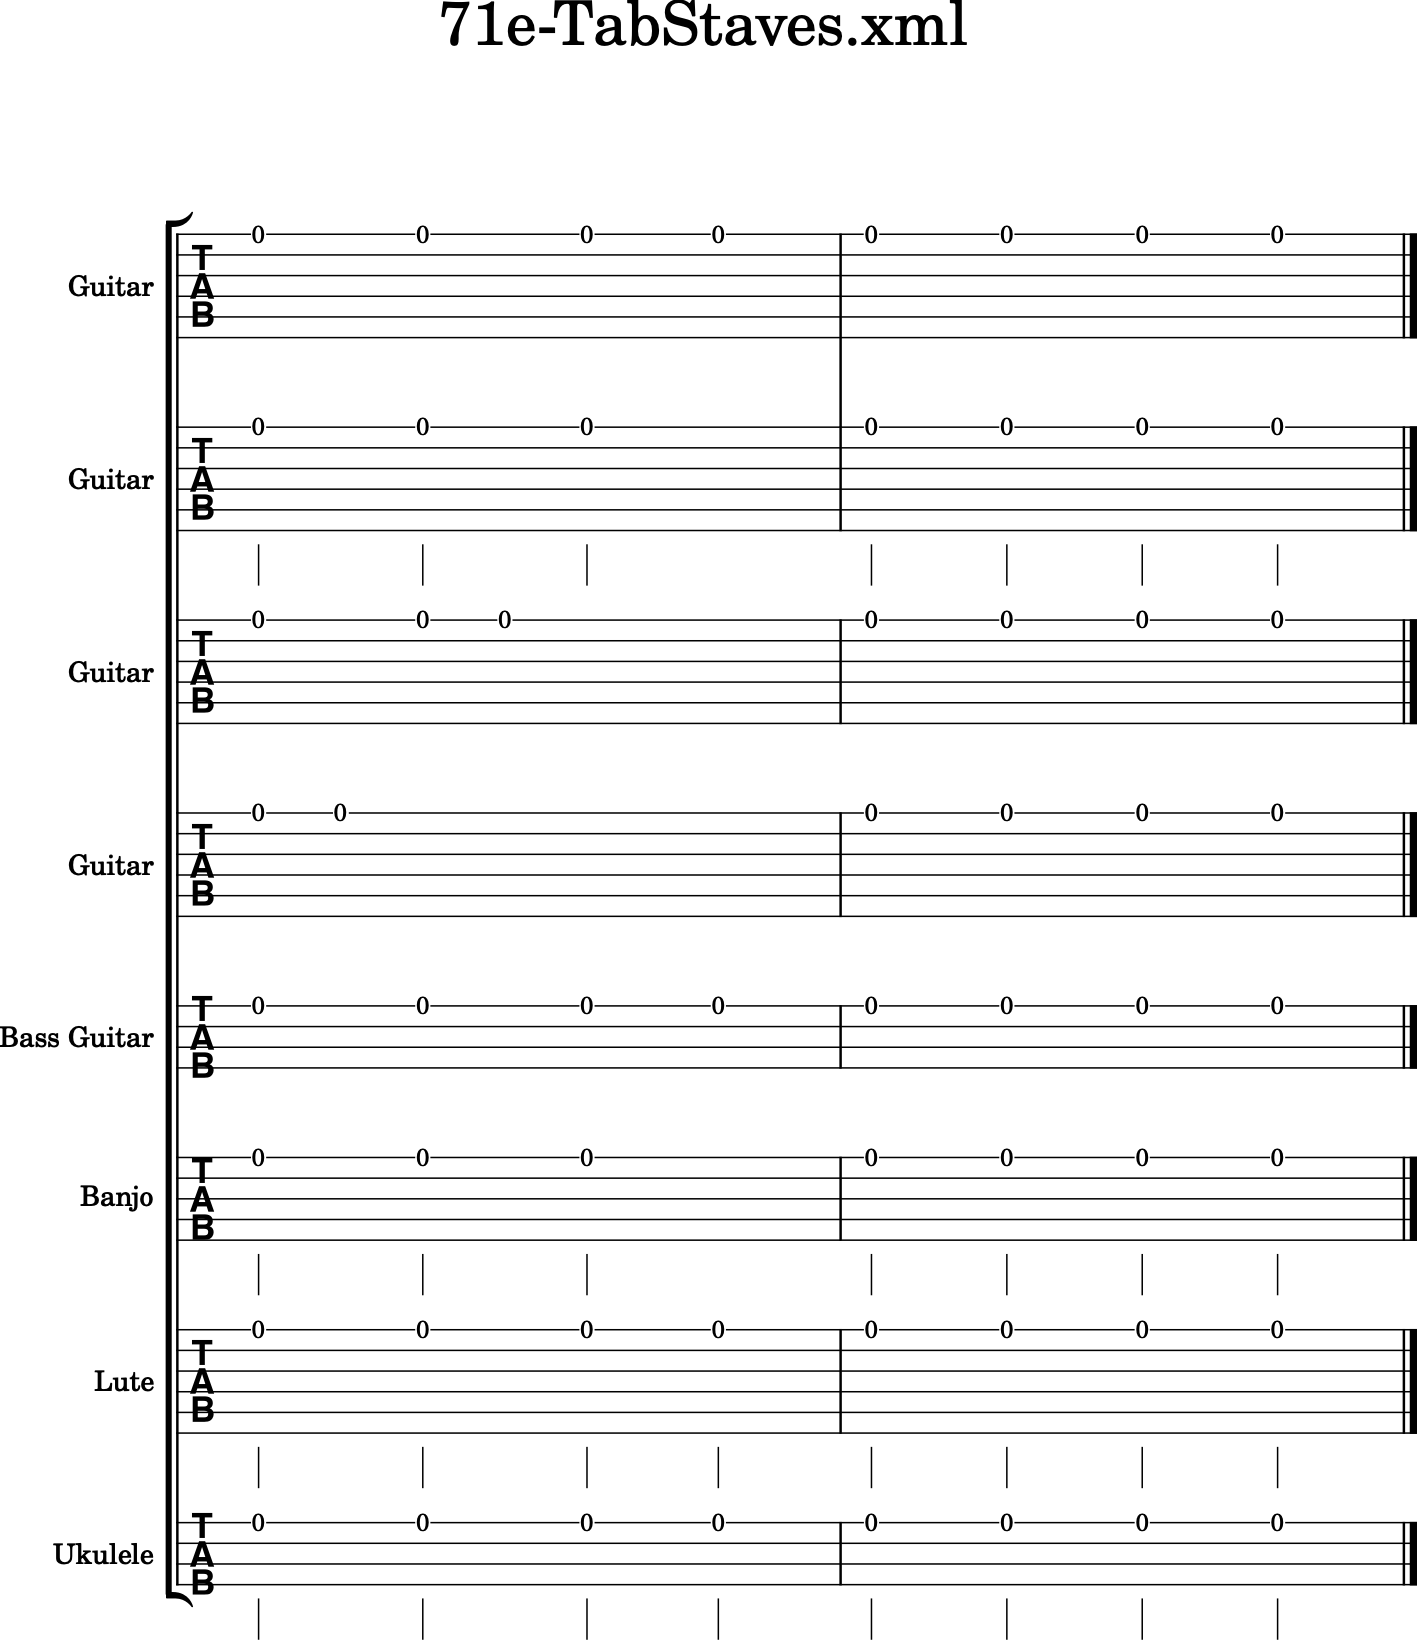

In [146]:
s('71e') # not yet supported

71f-AllChordTypes.xml

All chord types defined in MusicXML. The staff will only contain one c' note (NO chord) for all of them, but the chord names should be properly printed.


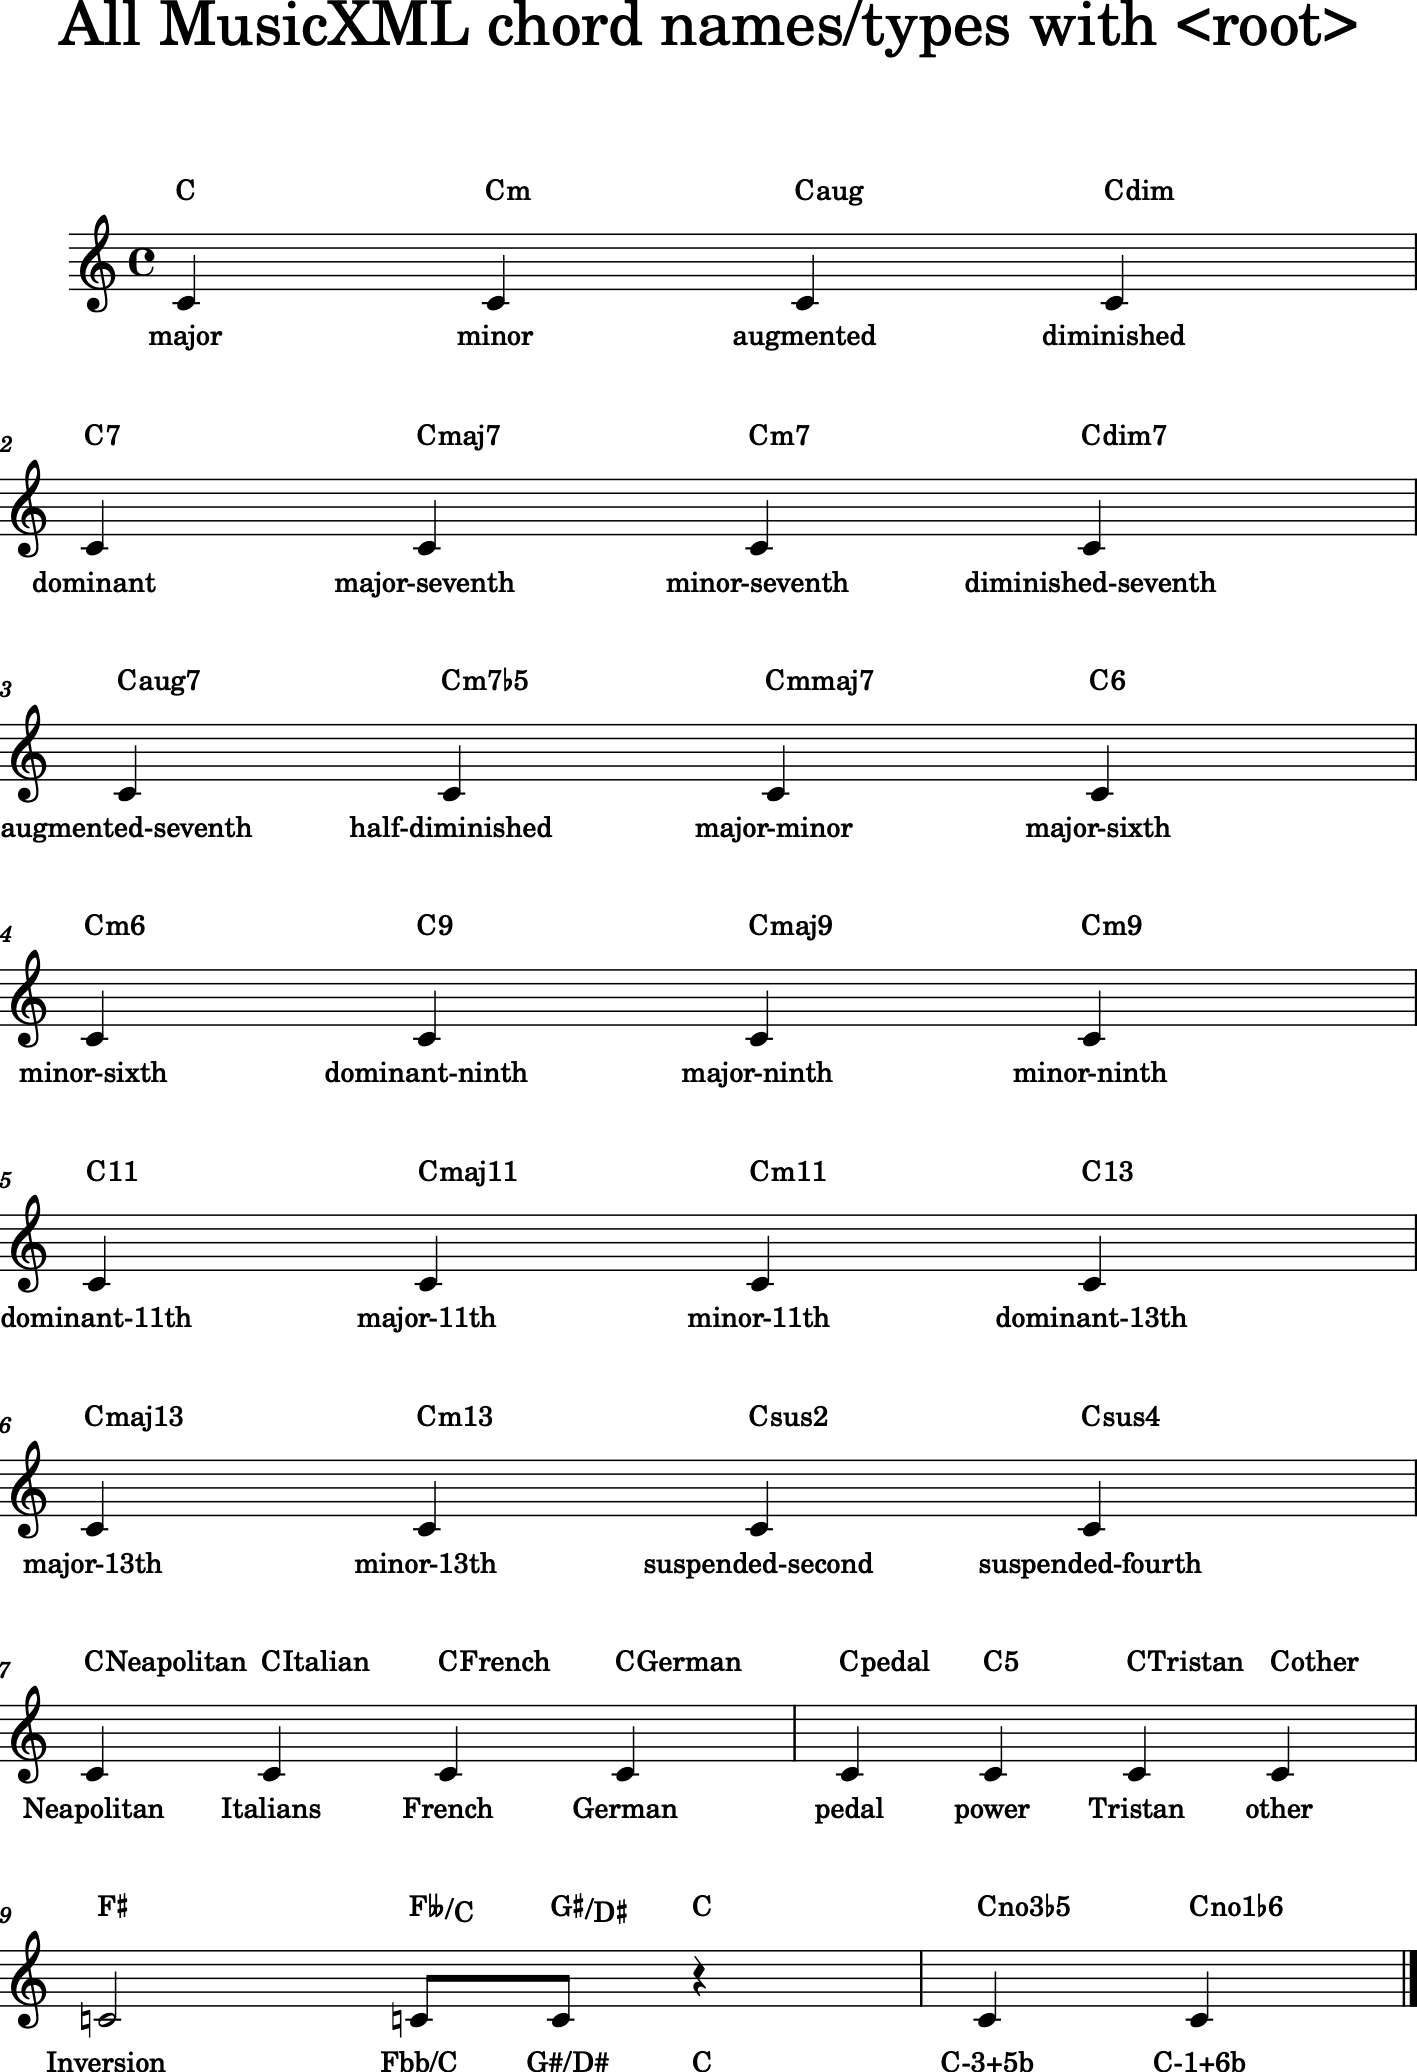

In [147]:
s('71f')

71g-MultipleChordnames.xml

There can be multiple subsequent harmony elements, indicating a harmony change during a note


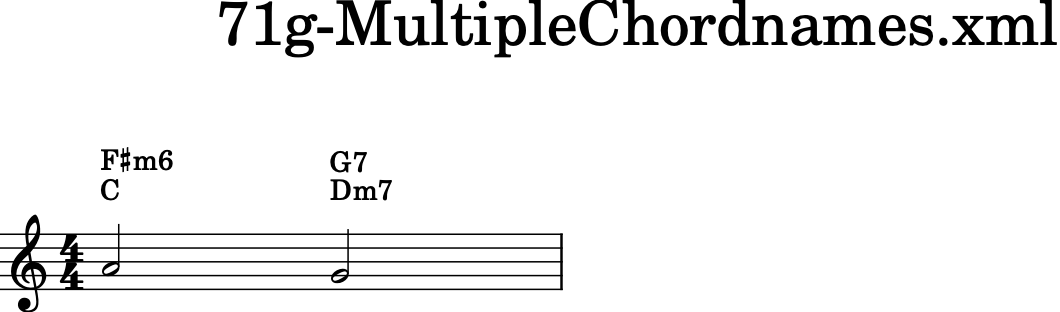

In [148]:
s('71g')

## 72 ... Transposing instruments

72a-TransposingInstruments.xml

Transposing instruments: Trumpet in Bb, Horn in Eb, Piano; All of them show the C major scale (the trumpet with 2 sharp, the horn with 3 sharp).


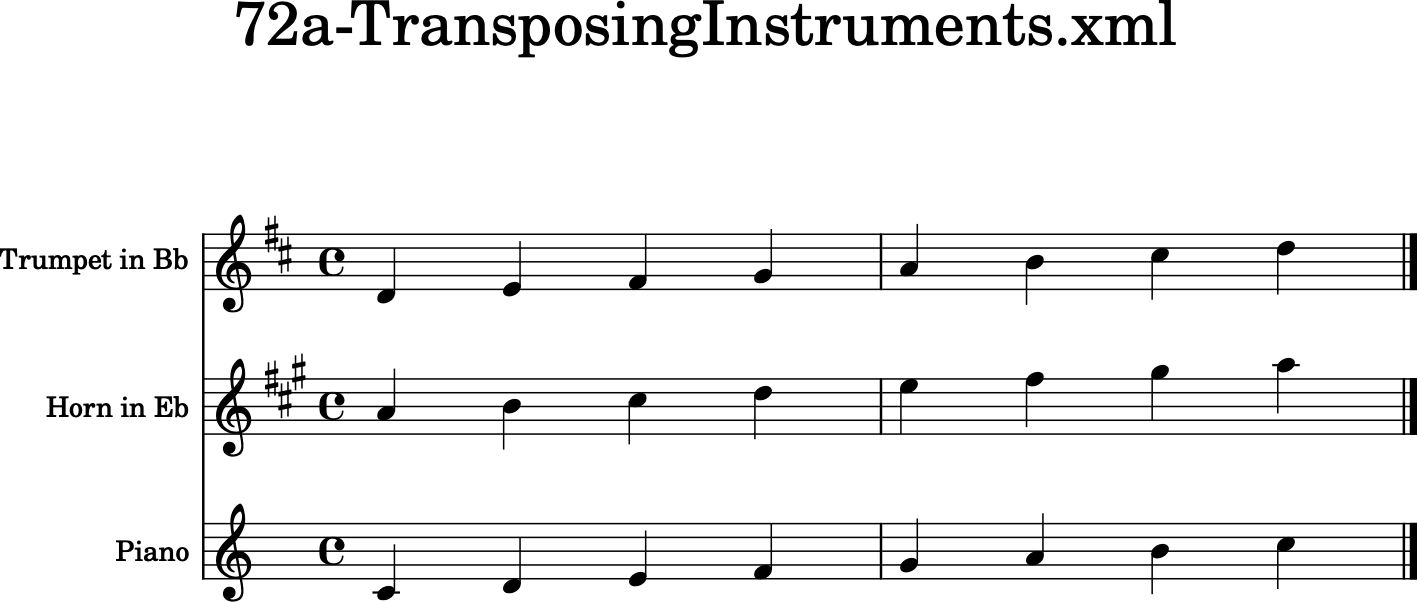

In [149]:
s('72a')

72b-TransposingInstruments-Full.xml

Various transposition. Each part plays a c'', just displayed in different display pitches. The second-to-last staff uses a transposition where the displayed c' is an actual f''' concert pitch. The final staff is an untransposed instrument.


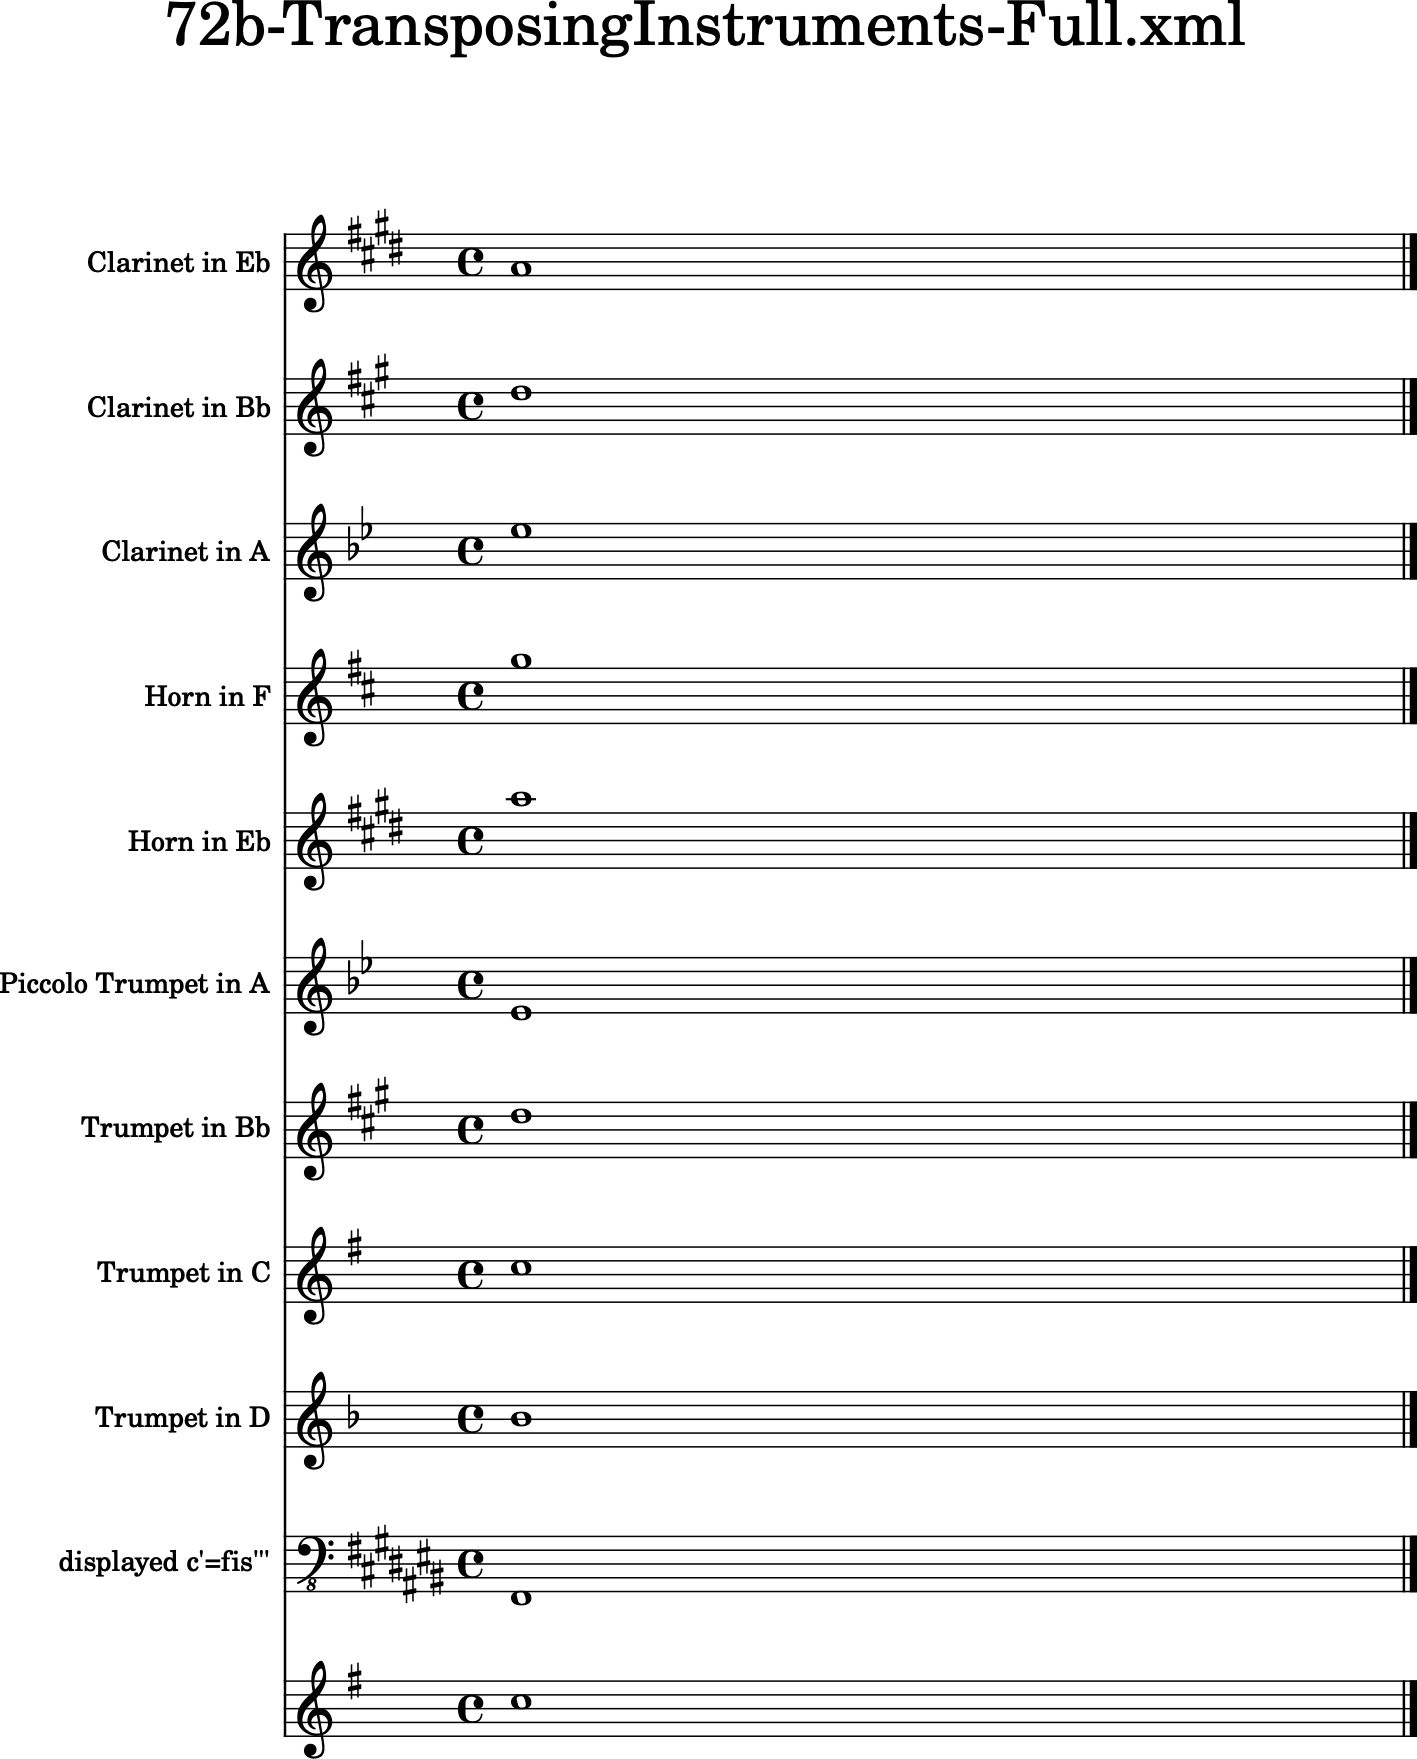

In [150]:
s('72b')

72c-TransposingInstruments-Change.xml

An instrument change from one transposition (Clarinet in Eb) to another transposing instrument (Clarinet in Bb). The displayed instrument name should also be updated. The whole piece is in Bb major (sounding), so first the key signature should be one sharp, after the change it should have no accidentals. 


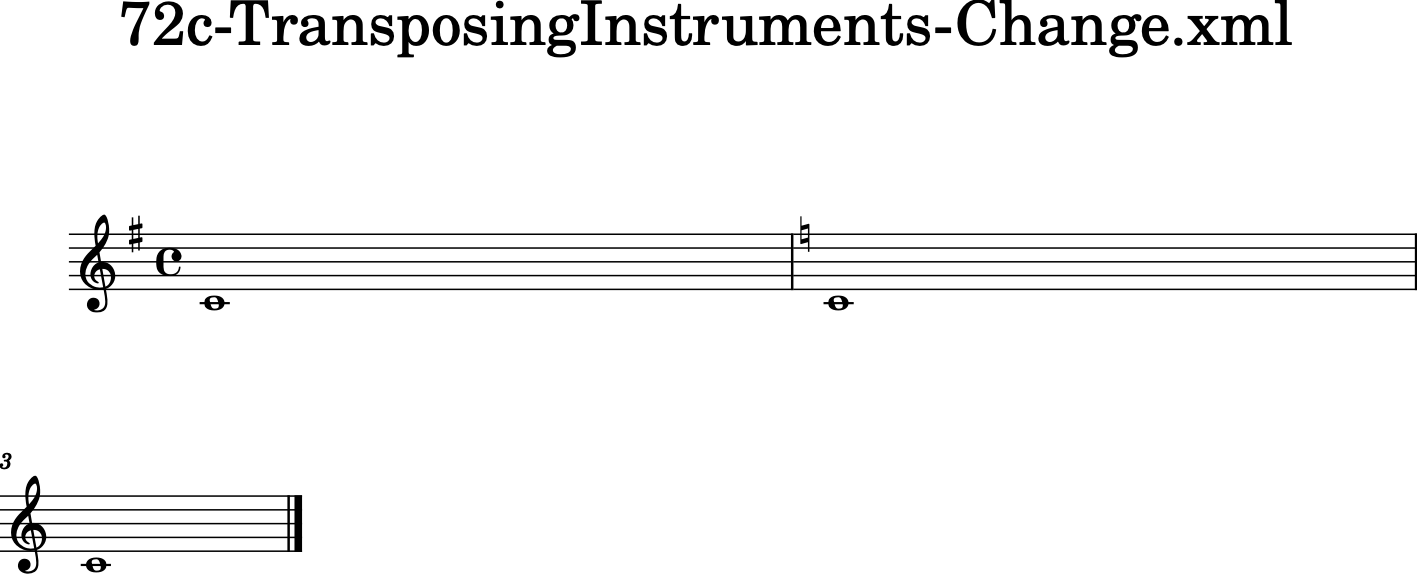

In [151]:
s('72c')

## 73 ... Percussion

73a-Percussion.xml

Three types of percussion staves: A five-line staff with bass clef for Timpani, a five-line staff with percussion clef, and a one-line percussion staff with only unpitched notes.


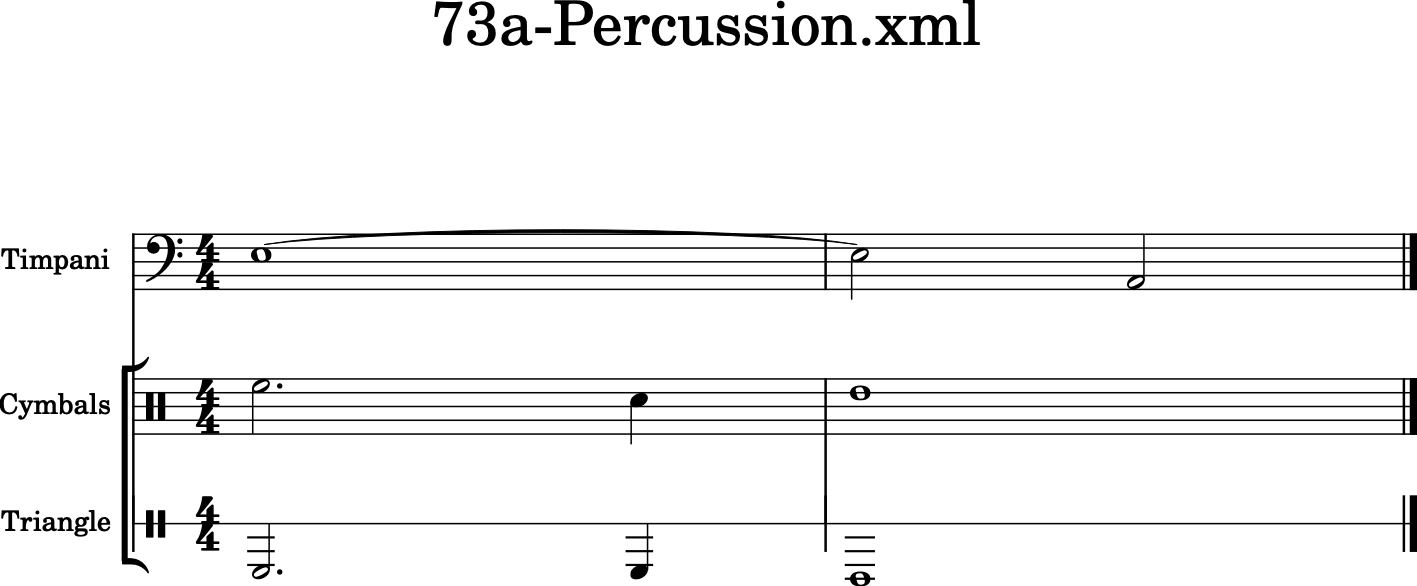

In [152]:
s('73a')

## 74 ... Figured bass

74a-FiguredBass.xml

Some figured bass containing alterated figures, bracketed figures and slashed figures. The last note contains an empty <figured-bass> element, which is invalid MusicXML, to check how well applications cope with malformed files. Note that this file does not contain any extenders!


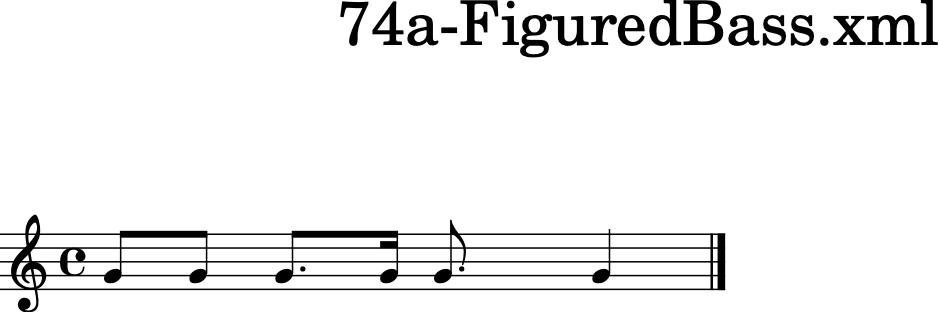

In [153]:
s('74a') # not yet supported -- completely in music21 though.
# fix to be well-formed musicxml and then put misformed in 99...

## 75 ... Other instrumental notation

75a-AccordionRegistrations.xml

All possible accordion registrations. Edited to remove invalid MusicXML, which has been moved to 99d. 


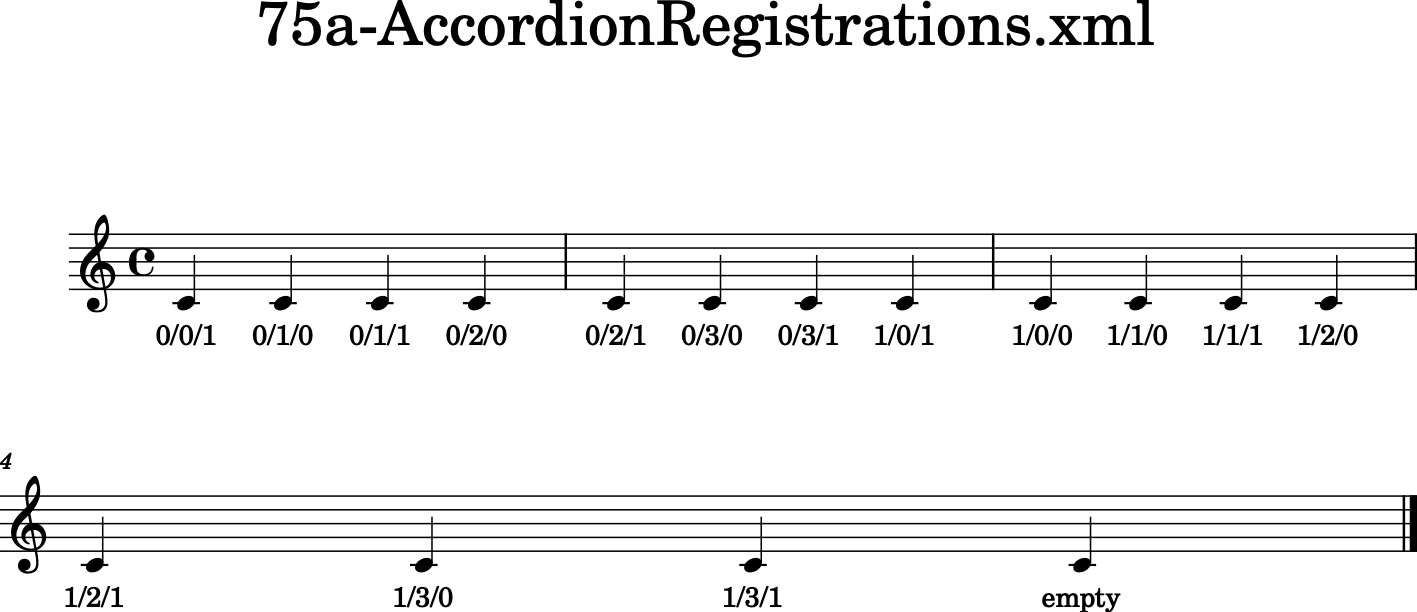

In [154]:
s('75a') # not supported by music21 or MuseScore

## 90 ... Compressed MusicXML files

90a-Compressed-MusicXML.mxl

A compressed MusicXML file, containing a simple MusicXML score and the corresponding .pdf output for reference.


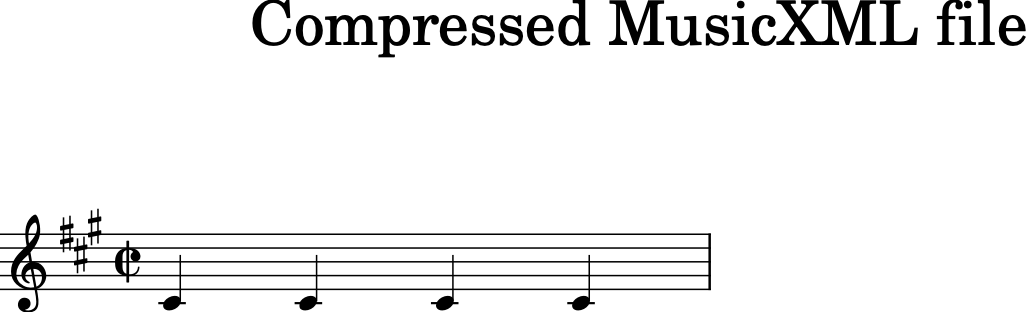

In [155]:
s('90a')

## 99 ... Compatibility with broken MusicXML

All of these are acceptable to fail on.

99a-Sibelius5-IgnoreBeaming.xml

Dolet 3 for Sibelius (5.1) did not print out any closing beam tags, only starting and continuing beam tags. For such files, one either needs to ignore all beaming information or close all beams 


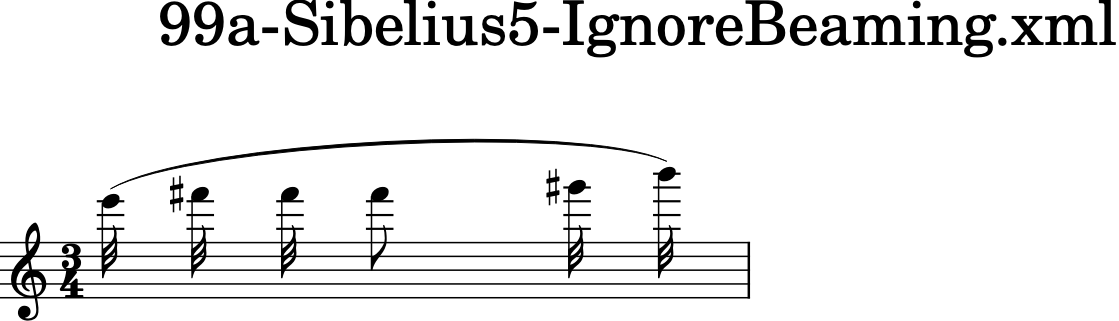

In [156]:
s('99a')

99b-Lyrics-BeamsMelismata-IgnoreBeams.xml

If we properly ignore all beaming information from the Dolet 3 for Sibelius export file, make sure that the lyrics syllables are still assigned to the correct notes.


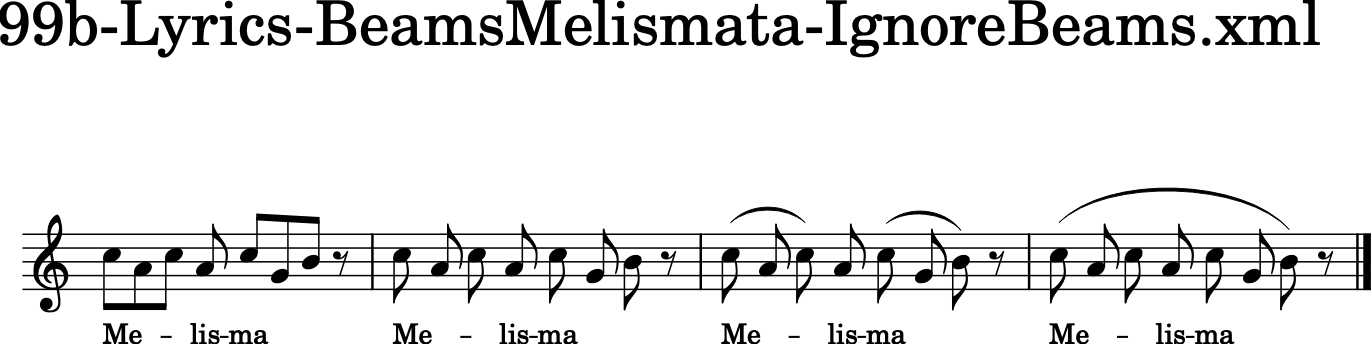

In [157]:
s('99b')

99c-Wavy-Lines-No-Numbers.xml

A wavy line starts on the first note, ends on the second, starts again on the second and ends on the third. No numbers given. This is very bad, but technically not incorrect MusicXML. 


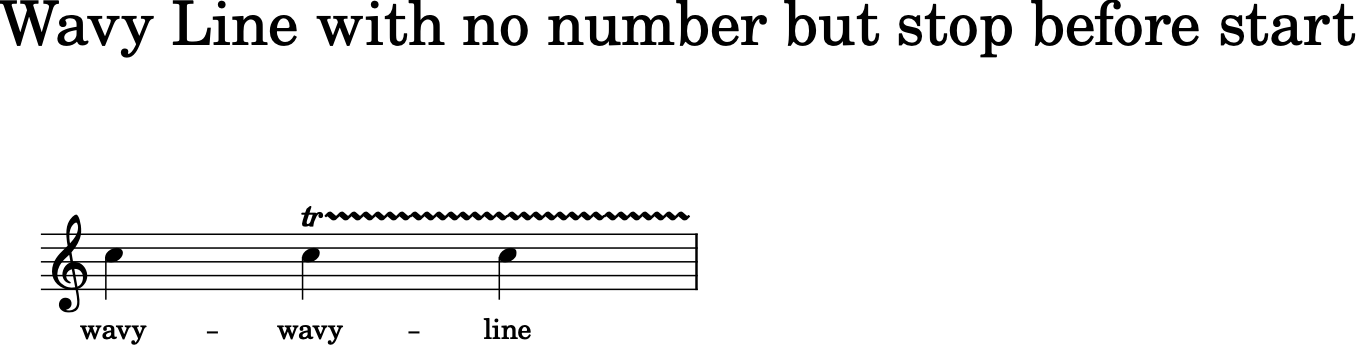

In [158]:
s('99c') # used to crash musescore!

99d-AccordionInvalid.xml

Invalid accordion registrations. Moved out of 75a.. No accordion-(high|middle|low) given, empty middle, middle with invalid value, middle with 0 


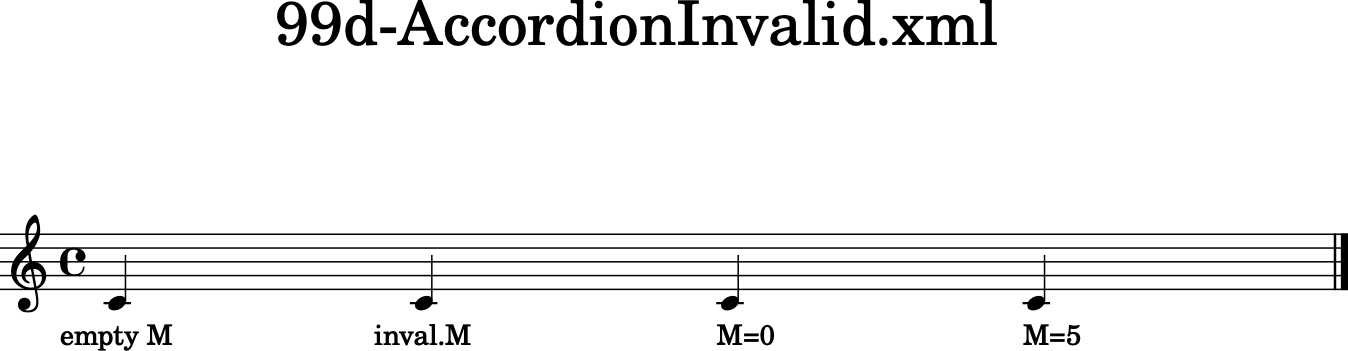

In [159]:
s('99d') # should simply not crash.

In [160]:
untested

[]